Code to replicate cross-border climate risk analysis, with EORA26 as MRIOT and INFORM Climate Change as climate risk index.

# MRIOT
----

EORA26

In [1]:
import pymrio

eora_storage = "MRIOT\EORA"

eora = pymrio.parse_eora26(year=2016, path=eora_storage)

mriot = eora
mriot.calc_all()

c:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1926: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  eora_data[key].drop(row_name, axis=1, inplace=True)
c:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1939: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  eora_data[key].drop(row_name, axis=0, inplace=True)
c:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1926: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  eora_data[key].drop(row_name, axis=1, inplace=True)
c:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1926: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  eora_data[key].drop(row_name, axis=1, inplace=True)


# Risk index
-----

## INFORM Climate Change

Here INFORM Climate Change is imported. Not all countries of EORA26 have a risk index (see 2.2 below). Two countries (USSR and Netherlands Antilles) are outdated.

EORA26 have 189 countries and 15 of them do not have a risk index in INFORM. Two countries (USSR and Netherlands Antilles) are outdated and not kept in the final dataframe.

In the end, there should be 189-2 = 187 countries in the final dataframe, of which 13 do not have a risk index.

In [2]:
import pandas as pd
import numpy as np

file_path = 'INFORM_Climate_Change/INFORM_Climate_Change_Index/InformCC_usable.xlsx'
Climate_Risk_INFORMCC = pd.read_excel(file_path)

# Namibia is interpreted as "NaN". This is correct below
Climate_Risk_INFORMCC['Country'].fillna("NA", inplace=True)

# Calculate the "Change in Risk' column
Climate_Risk_INFORMCC['Change in Risk'] = Climate_Risk_INFORMCC['INDEX 2050 Pessimistic']-Climate_Risk_INFORMCC['INFORM 2022']
      
## Distributing EORA's countries by risk level
#########

# Importing EORA's countries (3-letter code)

L= mriot.L
country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()
MRIOT_3_letters = list(country_list).copy()

# Conversion table (2-letter code / 3-letter)

csv_file = "Other_data/country_codes.csv"
iso_convert = pd.read_csv(csv_file, delimiter=',')  # Assuming tab-delimited data
iso_convert.loc[iso_convert['name'] == 'Namibia', 'alpha-2'] = 'NA' # Namibia line poses problems because it is read as 'nan'.
iso_convert.loc[iso_convert['name'] == 'South Sudan', 'alpha-3'] = 'SDS'
iso_convert.loc[iso_convert['name'] == 'Sudan', 'alpha-3'] = 'SUD'
columns_to_keep = ["name", "alpha-2", "alpha-3"]
iso_convert = iso_convert[columns_to_keep]

# Merging the DataFrames on the alpha-2 code and Country columns
local_climate_risk = pd.merge(Climate_Risk_INFORMCC, iso_convert[['name','alpha-2', 'alpha-3']], left_on='Country', right_on='alpha-2', how='left')
# Selecting relevant columns for the final DataFrame

df= local_climate_risk
l='INDEX 2050 Pessimistic'

VLR_list = df[(df[l] >= 0) & (df[l] <= 1.9)]["alpha-3"].tolist()
LR_list = df[(df[l] >= 2) & (df[l] <= 3.4)]["alpha-3"].tolist()
MR_list = df[(df[l] >= 3.5) & (df[l] <= 4.9)]["alpha-3"].tolist()
HR_list = df[(df[l] >= 5) & (df[l] <= 6.4)]["alpha-3"].tolist()
VHR_list = df[(df[l] >= 6.5) & (df[l] <= 10)]["alpha-3"].tolist()

VLR_list_MRIOT = list(filter(lambda x: x in VLR_list, MRIOT_3_letters))
LR_list_MRIOT = list(filter(lambda x: x in LR_list, MRIOT_3_letters))
MR_list_MRIOT = list(filter(lambda x: x in MR_list, MRIOT_3_letters))
HR_list_MRIOT = list(filter(lambda x: x in HR_list, MRIOT_3_letters))
VHR_list_MRIOT = list(filter(lambda x: x in VHR_list, MRIOT_3_letters))

# Defining a low and high risk country lists
high_risk_countries=MR_list_MRIOT+HR_list_MRIOT+VHR_list_MRIOT
low_risk_countries=LR_list_MRIOT+VLR_list_MRIOT
no_risk_countries = [
    "ABW",  # Aruba
    "AND",  # Andorra
    "TWN",  # Taiwan (Officially known as the Republic of China)
    "PYF",  # French Polynesia
    "GRL",  # Greenland
    "BMU",  # Bermuda
    "CYM",  # Cayman Islands
    "MCO",  # Monaco
    "VGB",  # Virgin Islands
    "MAC",  # Macau
    "SMR",  # San Marino
    "HKG",  # Hong Kong
    "NCL",  # New Caledonia
    "USR",  # USSR (note: outdated code, the USSR has been dissolved; this code is not in use)
    "ANT"   # Netherlands Antilles (also outdated, as it was dissolved in 2010)
]

local_climate_risk = local_climate_risk[['name', 'alpha-3', l, 'Change in Risk']].copy()
local_climate_risk.rename(columns={'alpha-3': 'Country Code', l: 'Local Climate Risk', 'name': 'Country'}, inplace=True)

new_data = {
    'Country': ['Aruba', 'Andorra', 'Antillas Netherlands', 'Bermuda', 'Cayman Islands', 'Greenland', 'China, Hong Kong SAR', 'China, Macao SAR', 'Monaco', 'New Caledonia', 'French Polynesia', 'San Marino', 'Taiwan', 'USSR', 'Virgin Islands (British)'],
    'Country Code': ['ABW', 'AND', 'ANT', 'BMU', 'CYM', 'GRL', 'HKG', 'MAC', 'MCO', 'NCL', 'PYF', 'SMR', 'TWN', 'USR', 'VGB'],
    'Local Climate Risk': [np.nan] * 15,  # Creating a list of NaN values
    'Change in Risk': [np.nan] * 15  # Creating a list of NaN values
}

# Creating a DataFrame from the new data
new_df = pd.DataFrame(new_data)

# Appending the new DataFrame to the existing one using concat
local_climate_risk = pd.concat([local_climate_risk, new_df], ignore_index=True)

## Comparing EORA26 and INFORM Climate Change

In the data, EORA has 189 countries. For a list, see : https://worldmrio.com/metadata.jsp.

In the data, INFORM Climate Change has 191 countries.

The countries in EORA that do not have a risk index in INFORM Climate Change are (see code below) : 
- ABW - Aruba
- AND - Andorra
- ANT - Antillas Netherlands.
- BMU - Bermuda
- CYM - Cayman Islands
- GRL - Greenland
- HKG - Hong Kong
- MAC - Macau
- MCO - Monaco
- NCL - New Caledonia
- PYF - French Polynesia
- SMR - San Marino
- TWN - Taiwan (Officially known as the Republic of China)
- USR - USSR ? 
- VGB - Virgin Islands

Two countries seem to be outdated : ANT is for the Netherlands Antilles (this entity was dissolved in 2010, and its territories were restructured) ; USR for USSR. 
They account for null or extremely small amounts of trade, and will be discarded in the final dataframe.

Among other countries, only Taiwan is non negligible from a trade point of view.

The final cross-border risk dataframe should include 189-2 = 187 countries. Of these, 13 countries will not have a risk index; however, their trade will be distributed among low-risk, high-risk, and no-risk countries.

In [3]:
L= mriot.L
country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()
MRIOT_3_letters = list(country_list).copy()


# Import INFORM (2 digits) and EORA (3 digits) country lists
#####

csv_file = "Other_data/country_codes.csv"
iso_convert = pd.read_csv(csv_file, delimiter=',')  # Assuming tab-delimited data
iso_convert.loc[iso_convert['name'] == 'Namibia', 'alpha-2'] = 'NA' # Namibia line poses problems because it is read as 'nan'.
iso_convert.loc[iso_convert['name'] == 'South Sudan', 'alpha-3'] = 'SDS'
iso_convert.loc[iso_convert['name'] == 'Sudan', 'alpha-3'] = 'SUD'
columns_to_keep = ["name", "alpha-2", "alpha-3"]
iso_convert = iso_convert[columns_to_keep]

# Merging the DataFrames on the alpha-2 code and Country columns
local_climate_risk = pd.merge(Climate_Risk_INFORMCC, iso_convert[['name','alpha-2', 'alpha-3']], left_on='Country', right_on='alpha-2', how='left')
local_climate_risk = local_climate_risk[['name', 'alpha-3', l, 'Change in Risk']].copy()
local_climate_risk.rename(columns={'alpha-3': 'Country Code', l: 'Local Climate Risk', 'name': 'Country'}, inplace=True)


inform_country_list=list(local_climate_risk['Country Code'])

eora_country_list = list(L.index.get_level_values(0).unique()) # 3 digits


# We want to know which countries of EORA do not have a risk index
eora_not_inform = list(set(eora_country_list) - set(inform_country_list))
eora_not_inform = sorted(eora_not_inform)

print("Countries in EORA with no risk index :", eora_not_inform)

Countries in EORA with no risk index : ['ABW', 'AND', 'ANT', 'BMU', 'CYM', 'GRL', 'HKG', 'MAC', 'MCO', 'NCL', 'PYF', 'SMR', 'TWN', 'USR', 'VGB']


## Risk maps
----

### 5 risk levels

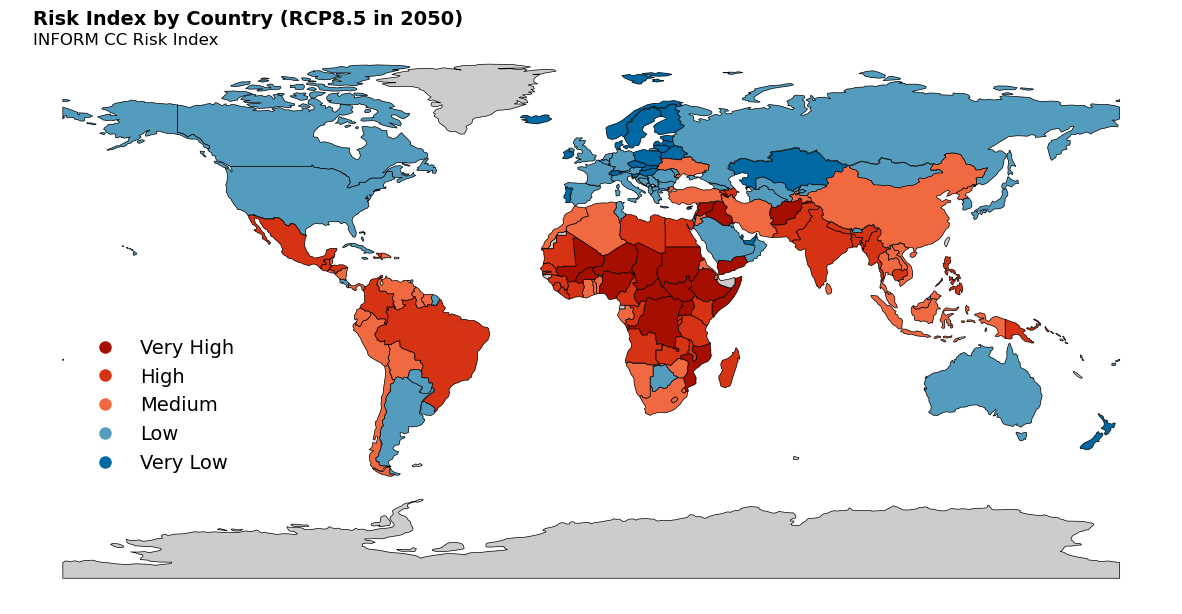

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
import random

#HR_list_MRIOT.append('SSD')
#HR_list_MRIOT.append('SDN')

# Load the GeoJSON file
world = gpd.read_file("Other_data/WorldMap/ne_110m_admin_0_countries.shp")

# France, Norway, South and North Sudan are not well coded in the original map
world.loc[(world['SOVEREIGNT'] == 'France')&(world['TYPE']=='Country'),'ISO_A3']='FRA' 
world.loc[(world['SOVEREIGNT'] == 'Norway'),'ISO_A3']='NOR'
world.loc[(world['SOVEREIGNT'] == 'South Sudan'),'ISO_A3']='SDS'
world.loc[(world['SOVEREIGNT'] == 'Sudan'),'ISO_A3']='SUD'

risk_levels = {
    'Very High': '#a60f00' ,   # Dark Red
    'High': '#d63314',     # Medium Red
    'Medium': '#f06941',   # Light Red
    'Low': '#549cbd',    # Green
    'Very Low': '#0068a3',   # Vibrant Green
}

iso_to_color = {}
for code in world['ISO_A3']:
    if code in VLR_list_MRIOT:
        iso_to_color[code] = risk_levels['Very Low']
    elif code in LR_list_MRIOT:
        iso_to_color[code] = risk_levels['Low']
    elif code in MR_list_MRIOT:
        iso_to_color[code] = risk_levels['Medium']
    elif code in HR_list_MRIOT:
        iso_to_color[code] = risk_levels['High']
    elif code in VHR_list_MRIOT:
        iso_to_color[code] = risk_levels['Very High']
    else:
        iso_to_color[code] = (0.8, 0.8, 0.8)  # Default gray color for countries not in the lists

# Create a plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map with colored countries
for code, color in iso_to_color.items():
    world[world['ISO_A3'] == code].plot(ax=ax, color=color, edgecolor='black', linewidth=0.5)

# Custom legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                  for label, color in risk_levels.items()]
ax.legend(handles=legend_patches, loc='upper left', frameon=False, bbox_to_anchor=(0.05, 0.5),fontsize=14)  # Adjust the bbox_to_anchor for desired position

# Set bold title in the left corner
plt.text(0.02, 1.05, "Risk Index by Country (RCP8.5 in 2050)", transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

# Add a subtitle
plt.text(0.02, 1.01, "INFORM CC Risk Index", transform=ax.transAxes, fontsize=12, va='top', ha='left')

# Disable the frame around the map
ax.set_frame_on(False)

# Remove latitude and longitude labels
ax.set_xticks([])
ax.set_yticks([])

# Show the map
plt.show()

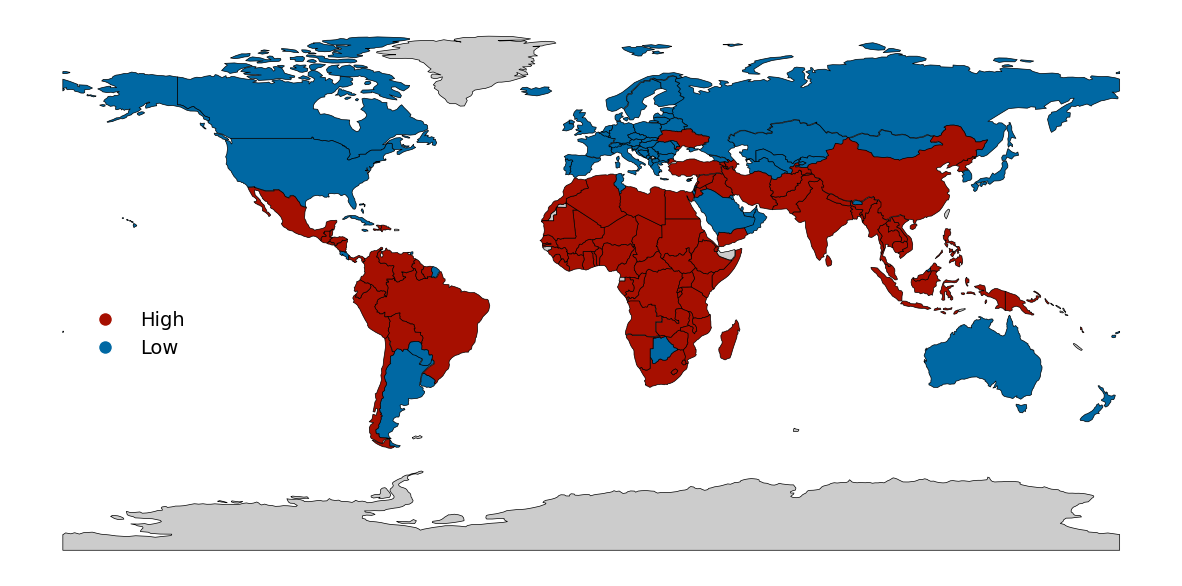

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import random

# Load the GeoJSON file
world = gpd.read_file("Other_data/WorldMap/ne_110m_admin_0_countries.shp")

# France, Norway, South and North Sudan are not well coded in the original map
world.loc[(world['SOVEREIGNT'] == 'France')&(world['TYPE']=='Country'),'ISO_A3']='FRA' 
world.loc[(world['SOVEREIGNT'] == 'Norway'),'ISO_A3']='NOR'
world.loc[(world['SOVEREIGNT'] == 'South Sudan'),'ISO_A3']='SDS'
world.loc[(world['SOVEREIGNT'] == 'Sudan'),'ISO_A3']='SUD'

risk_levels = {
    'High': '#a60f00' ,   # Dark Red
    'Low': '#0068a3',   # Vibrant Green
}

iso_to_color = {}
for code in world['ISO_A3']:
    if code in VLR_list_MRIOT:
        iso_to_color[code] = risk_levels['Low']
    elif code in LR_list_MRIOT:
        iso_to_color[code] = risk_levels['Low']
    elif code in MR_list_MRIOT:
        iso_to_color[code] = risk_levels['High']
    elif code in HR_list_MRIOT:
        iso_to_color[code] = risk_levels['High']
    elif code in VHR_list_MRIOT:
        iso_to_color[code] = risk_levels['High']
    else:
        iso_to_color[code] = (0.8, 0.8, 0.8)  # Default gray color for countries not in the lists

# Create a plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map with colored countries
for code, color in iso_to_color.items():
    world[world['ISO_A3'] == code].plot(ax=ax, color=color, edgecolor='black', linewidth=0.5)

# Custom legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                  for label, color in risk_levels.items()]
ax.legend(handles=legend_patches, loc='upper left', frameon=False, bbox_to_anchor=(0.05, 0.5),fontsize=14)  # Adjust the bbox_to_anchor for desired position


# Disable the frame around the map
ax.set_frame_on(False)

# Remove latitude and longitude labels
ax.set_xticks([])
ax.set_yticks([])

# Save the plot to a file
#plt.savefig('Figures/Supp Mat/A/Figure1b_t.png')

# Show the map
plt.show()

### Low/High risk

Low / High risk threshold is put at 3.5, that is between Low Risk and Medium Risk categories.

Generating low/high country lists with different thresholds 

In [41]:
import pandas as pd

def create_local_climate_risk(climate_risk, t):
    df=climate_risk.copy()
    
    df['Local Risk'] = pd.cut(df['Local Climate Risk'], bins=[0, 3.4+t, 10], labels=['Low Risk', 'High Risk'], right=True)

    modified_local_climate_risk=df
    return modified_local_climate_risk


# Call the function with simulated data and thresholds
modified_local_climate_risk = create_local_climate_risk(local_climate_risk, 0)

In [42]:
modified_local_climate_risk

,Country,Country Code,Local Climate Risk,Change in Risk,Local Risk
0,United Arab Emirates,ARE,1.8,0.2,Low Risk
1,Afghanistan,AFG,8.1,0.1,High Risk
2,Antigua and Barbuda,ATG,2.2,0.2,Low Risk
3,Albania,ALB,2.7,0.1,Low Risk
4,Armenia,ARM,5.4,0.1,High Risk
...,...,...,...,...,...
201,French Polynesia,PYF,NaN,NaN,NaN
202,San Marino,SMR,NaN,NaN,NaN
203,Taiwan,TWN,NaN,NaN,NaN
204,USSR,USR,NaN,NaN,NaN


Displaying maps for standard threshold (= 3.5)

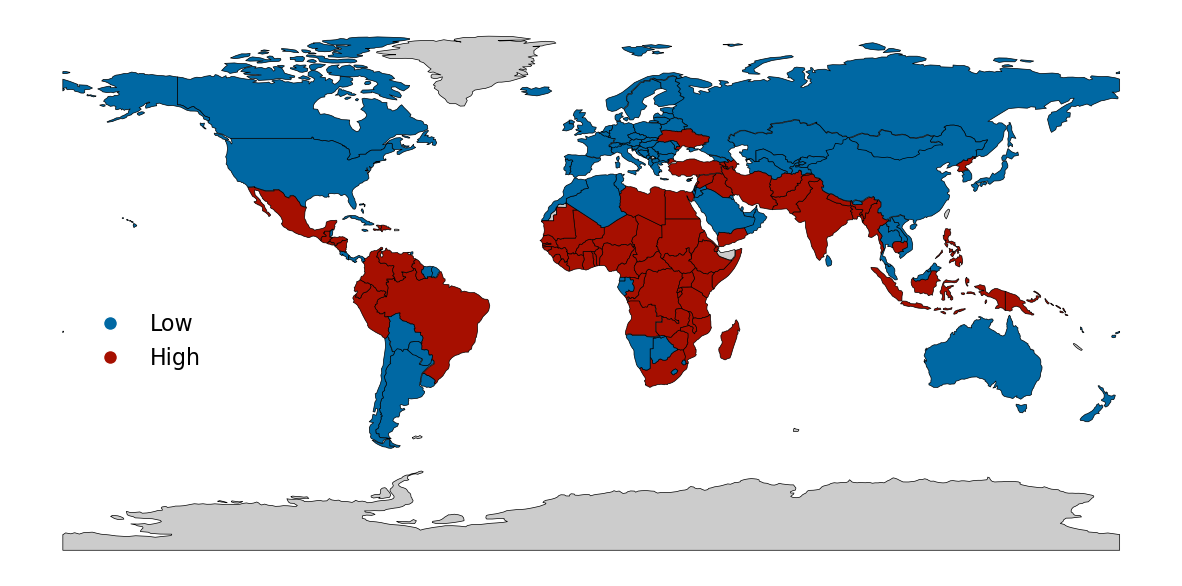

In [49]:
import geopandas as gpd
import matplotlib.pyplot as plt
import random

modified_local_climate_risk = create_local_climate_risk(local_climate_risk, 0.75)

df=modified_local_climate_risk

modified_low_risk_countries = list(df[df['Local Risk']=='Low Risk']['Country Code'])
modified_high_risk_countries = list(df[df['Local Risk']=='High Risk']['Country Code'])

# Load the GeoJSON file
world = gpd.read_file("Other_data/WorldMap/ne_110m_admin_0_countries.shp")
world.loc[(world['SOVEREIGNT'] == 'France')&(world['TYPE']=='Country'),'ISO_A3']='FRA' 
world.loc[(world['SOVEREIGNT'] == 'Norway'),'ISO_A3']='NOR'
world.loc[(world['SOVEREIGNT'] == 'South Sudan'),'ISO_A3']='SDS'
world.loc[(world['SOVEREIGNT'] == 'Sudan'),'ISO_A3']='SUD'


risk_levels = {
    'Low': '#0068a3' ,   # Dark Red
    'High': '#a60f00',   # Vibrant Green
}

iso_to_color = {}
for code in world['ISO_A3']:
    if code in modified_low_risk_countries:
        iso_to_color[code] = risk_levels['Low']
    elif code in modified_high_risk_countries:
        iso_to_color[code] = risk_levels['High']
    else:
        iso_to_color[code] = (0.8, 0.8, 0.8)  # Default gray color for countries not in the lists    
    
# Create a plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map with colored countries
for code, color in iso_to_color.items():
    world[world['ISO_A3'] == code].plot(ax=ax, color=color, edgecolor='black', linewidth=0.5)

# Custom legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                  for label, color in risk_levels.items()]
ax.legend(handles=legend_patches, loc='upper left', frameon=False, bbox_to_anchor=(0.05, 0.5),fontsize=16)  # Adjust the bbox_to_anchor for desired position

# Set bold title in the left corner
#plt.text(0.02, 1.05, "Risk Index by Country (RCP8.5 in 2050)", transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

# Add a subtitle
#plt.text(0.02, 1.01, "INFORM CC Risk Index", transform=ax.transAxes, fontsize=12, va='top', ha='left')

# Disable the frame around the map
ax.set_frame_on(False)

# Remove latitude and longitude labels
ax.set_xticks([])
ax.set_yticks([])

# Save the plot to a file
#plt.savefig(r'Figures\Supp Mat\E\Figure1a.png') #1a = 2.75 (-0.75)
plt.savefig(r'Figures\Supp Mat\E\Figure1b.png') #1b = 4.25 (+0.75)

# Show the map
plt.show()

Displaying maps for non standard thresholds (t)

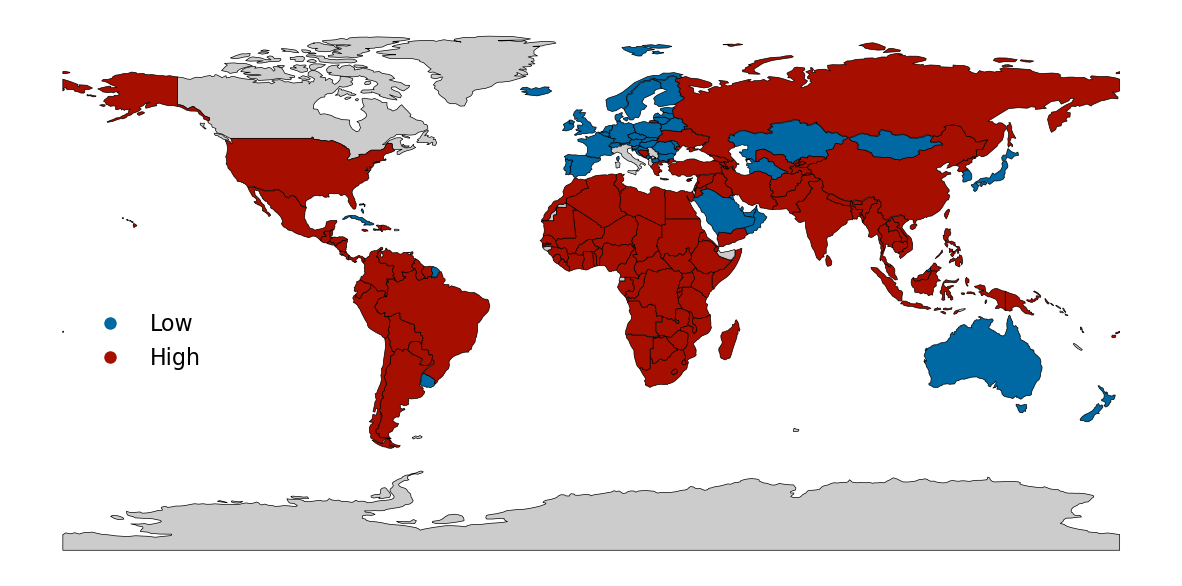

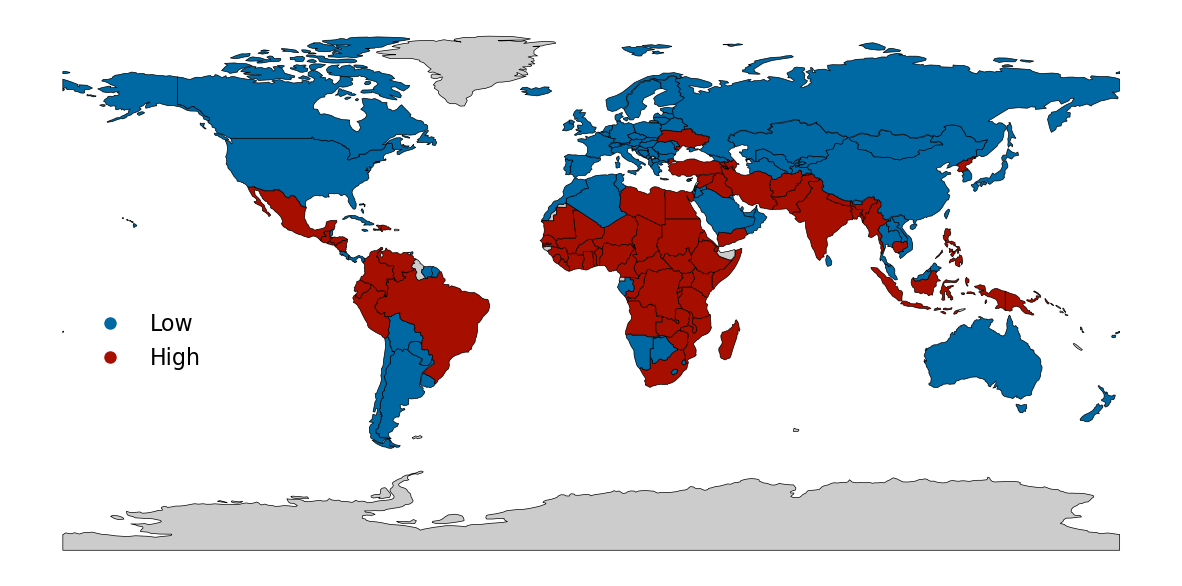

In [31]:
import geopandas as gpd
import matplotlib.pyplot as plt
import random

t=-0.75
risk_level_lists_MRIOT = create_risk_level_lists(Climate_Risk_INFORMCC, t)

# Load the GeoJSON file
world = gpd.read_file("Other_data/WorldMap/ne_110m_admin_0_countries.shp")
world.loc[(world['SOVEREIGNT'] == 'France')&(world['TYPE']=='Country'),'ISO_A3']='FRA'
world.loc[(world['SOVEREIGNT'] == 'Norway'),'ISO_A3']='NOR'

risk_levels = {
    'Low': '#0068a3' ,   # Dark Red
    'High': '#a60f00',   # Vibrant Green
}

iso_to_color = {}
for code in world['ISO_A3']:
    if code in risk_level_lists_MRIOT['VLR']:
        iso_to_color[code] = risk_levels['Low']
    elif code in risk_level_lists_MRIOT['LR']:
        iso_to_color[code] = risk_levels['Low']
    elif code in risk_level_lists_MRIOT['MR']:
        iso_to_color[code] = risk_levels['High']
    elif code in risk_level_lists_MRIOT['HR']:
        iso_to_color[code] = risk_levels['High']
    elif code in risk_level_lists_MRIOT['VHR']:
        iso_to_color[code] = risk_levels['High']
    else:
        iso_to_color[code] = (0.8, 0.8, 0.8)  # Default gray color for countries not in the lists

low_risk_countries = risk_level_lists_MRIOT['VLR']+risk_level_lists_MRIOT['LR']
high_risk_countries = risk_level_lists_MRIOT['MR']+risk_level_lists_MRIOT['HR']+risk_level_lists_MRIOT['VHR']

if 'SDS' in low_risk_countries:
    iso_to_color['SSD']= risk_levels['Low']
elif 'SDS' in high_risk_countries:
    iso_to_color['SSD']= risk_levels['High']
    
if 'SUD' in low_risk_countries:
    iso_to_color['SDN']= risk_levels['Low']
elif 'SUD' in high_risk_countries:
    iso_to_color['SDN']= risk_levels['High']    
    
    
# Create a plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map with colored countries
for code, color in iso_to_color.items():
    world[world['ISO_A3'] == code].plot(ax=ax, color=color, edgecolor='black', linewidth=0.5)

# Custom legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                  for label, color in risk_levels.items()]
ax.legend(handles=legend_patches, loc='upper left', frameon=False, bbox_to_anchor=(0.05, 0.5),fontsize=16)  # Adjust the bbox_to_anchor for desired position

# Set bold title in the left corner
#plt.text(0.02, 1.05, "Risk Index by Country (RCP8.5 in 2050)", transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

# Add a subtitle
#plt.text(0.02, 1.01, "INFORM CC Risk Index", transform=ax.transAxes, fontsize=12, va='top', ha='left')

# Disable the frame around the map
ax.set_frame_on(False)

# Remove latitude and longitude labels
ax.set_xticks([])
ax.set_yticks([])

# Save the plot to a file
#plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Figure4a.png')

t=+0.75
risk_level_lists_MRIOT = create_risk_level_lists(Climate_Risk_INFORMCC, t)

# Load the GeoJSON file
world = gpd.read_file("Other_data/WorldMap/ne_110m_admin_0_countries.shp")
world.loc[(world['SOVEREIGNT'] == 'France')&(world['TYPE']=='Country'),'ISO_A3']='FRA'
world.loc[(world['SOVEREIGNT'] == 'Norway'),'ISO_A3']='NOR'

risk_levels = {
    'Low': '#0068a3' ,   # Dark Red
    'High': '#a60f00',   # Vibrant Green
}

iso_to_color = {}
for code in world['ISO_A3']:
    if code in risk_level_lists_MRIOT['VLR']:
        iso_to_color[code] = risk_levels['Low']
    elif code in risk_level_lists_MRIOT['LR']:
        iso_to_color[code] = risk_levels['Low']
    elif code in risk_level_lists_MRIOT['MR']:
        iso_to_color[code] = risk_levels['High']
    elif code in risk_level_lists_MRIOT['HR']:
        iso_to_color[code] = risk_levels['High']
    elif code in risk_level_lists_MRIOT['VHR']:
        iso_to_color[code] = risk_levels['High']
    else:
        iso_to_color[code] = (0.8, 0.8, 0.8)  # Default gray color for countries not in the lists

low_risk_countries = risk_level_lists_MRIOT['VLR']+risk_level_lists_MRIOT['LR']
high_risk_countries = risk_level_lists_MRIOT['MR']+risk_level_lists_MRIOT['HR']+risk_level_lists_MRIOT['VHR']

if 'SDS' in low_risk_countries:
    iso_to_color['SSD']= risk_levels['Low']
elif 'SDS' in high_risk_countries:
    iso_to_color['SSD']= risk_levels['High']
    
if 'SUD' in low_risk_countries:
    iso_to_color['SDN']= risk_levels['Low']
elif 'SUD' in high_risk_countries:
    iso_to_color['SDN']= risk_levels['High']    
    
    
# Create a plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map with colored countries
for code, color in iso_to_color.items():
    world[world['ISO_A3'] == code].plot(ax=ax, color=color, edgecolor='black', linewidth=0.5)

# Custom legend
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                  for label, color in risk_levels.items()]
ax.legend(handles=legend_patches, loc='upper left', frameon=False, bbox_to_anchor=(0.05, 0.5),fontsize=16)  # Adjust the bbox_to_anchor for desired position

# Set bold title in the left corner
#plt.text(0.02, 1.05, "Risk Index by Country (RCP8.5 in 2050)", transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

# Add a subtitle
#plt.text(0.02, 1.01, "INFORM CC Risk Index", transform=ax.transAxes, fontsize=12, va='top', ha='left')

# Disable the frame around the map
ax.set_frame_on(False)

# Remove latitude and longitude labels
ax.set_xticks([])
ax.set_yticks([])


#plt.savefig(r'C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\Figure4b.png')

# Show the map
plt.show()

# Other data
---

## Developed, developing, least developed country lists

Data come from UNTCAD : https://unctadstat.unctad.org/EN/Classifications.html.

In addition,
- Monaco is considered developed,
- Virgin Islands (British) has been put in the same group as the United Kingdom (developed).

Names have been changed marginally to be coherent with country names used in other data.

In [33]:
import pickle

# Load the file
with open("Other_data/UN_developed_data.pkl", "rb") as file:
  lists_data = pickle.load(file)

# Retrieve the lists
least_developed_countries = lists_data["least_developed_countries"]
developed_countries = lists_data["developed_countries"]
developing_countries = lists_data["developing_countries"]

# Print the lists
print("Lists retrieved")

Lists retrieved


# Country-level analysis
----

## Imports interm. cons.
----

### Calculating exposure

In [ ]:
import pandas as pd

Y = mriot.Y
y = Y.sum(axis = 1)

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * country_list.size}
cForeign_Inputs_low = pd.DataFrame(values, index=country_list)

values = {'High Risk': [0] * country_list.size}
cForeign_Inputs_high = pd.DataFrame(values, index=country_list)

values = {'ROW': [0] * country_list.size}
cForeign_Inputs_row = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cForeign_Inputs = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cLocal_Inputs = pd.DataFrame(values, index=country_list)


for c in country_list:
    intrants_c = 0
    intrants_c_foreign = 0
    intrants_c_foreign_low = 0
    intrants_c_foreign_high = 0
    intrants_c_foreign_row = 0

    
    for s in sector_list:
        L_cs = L[c,s]
        y_cs = y[c,s]
        L_cs_foreign = L_cs[L_cs.index.get_level_values('region') != c]
        L_cs_foreign_low = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(low_risk_countries)]
        L_cs_foreign_high = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(high_risk_countries)]
        L_cs_foreign_row = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(no_risk_countries)]
       
        intrants_cs = (L_cs*y_cs).sum()
        intrants_cs_foreign = (L_cs_foreign*y_cs).sum()
        intrants_cs_foreign_low = (L_cs_foreign_low*y_cs).sum()
        intrants_cs_foreign_high = (L_cs_foreign_high*y_cs).sum()
        intrants_cs_foreign_row = (L_cs_foreign_row*y_cs).sum()

        intrants_c=intrants_c + intrants_cs
        intrants_c_foreign = intrants_c_foreign + intrants_cs_foreign   
        intrants_c_foreign_low = intrants_c_foreign_low + intrants_cs_foreign_low 
        intrants_c_foreign_high = intrants_c_foreign_high + intrants_cs_foreign_high  
        intrants_c_foreign_row = intrants_c_foreign_row + intrants_cs_foreign_row  

    cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
    cForeign_Inputs_low.loc[c] = intrants_c_foreign_low / intrants_c*100
    cForeign_Inputs_high.loc[c] = intrants_c_foreign_high / intrants_c *100
    cForeign_Inputs_row.loc[c] = intrants_c_foreign_row / intrants_c *100

    cLocal_Inputs.loc[c] = 100 - cForeign_Inputs.loc[c].iloc[0]
    
# List of DataFrames to concatenate
dataframes_to_concat = [cForeign_Inputs_low, cForeign_Inputs_high, cForeign_Inputs_row, cForeign_Inputs, cLocal_Inputs]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_inputs_leontief = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_inputs_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    elif region in no_risk_countries:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

result['Country Code']=result['region']

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'
    
result['Development'] = result['Country'].apply(categorize_development)
result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes + Taiwan

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

#result.loc[result['Country Code'] == 'TWN', 'Population'] = 23923276

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_country_imports_interm_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_32660\3087698081.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '21.546055181159858' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_32660\3087698081.py:57: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '13.49105682218839' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs_low.loc[c] = intrants_c_foreign_low / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_32660\3087698081.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '7.622719990983319' has dtype incompatible with int64, please explicitly cast to a compatible dt

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/resulting_dataframe_country_imports_interm_leontief_inform_eora.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_imports_interm_leontief, f)

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/resulting_dataframe_country_imports_interm_leontief_inform_eora.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_imports_interm_leontief = pickle.load(f)

### Results

Median High Risk Inputs 

In [ ]:
df=resulting_dataframe_country_imports_interm_leontief
median_high_risk_developed_inputs = df[df['Development'] == 'Developed']['High Risk Exposure (%)'].median()
median_high_risk_developed_inputs

4.201624585525825

Analyzing high exposure

In [ ]:
df = resulting_dataframe_country_imports_interm_leontief
median_foreign = df['Foreign (%)'].median()
median_share = df['Share of Risky Trade Partners (%)'].median()
df[(df['Foreign (%)'] > median_foreign) & 
   (df['Share of Risky Trade Partners (%)'] > median_share) & 
   (df['Local Risk'] == 'Low Risk')].sort_values(by='Population',ascending=False)

NameError: name 'resulting_dataframe_country_exports_leontief_CI' is not defined

#### Distribution Fig

##### Exposure

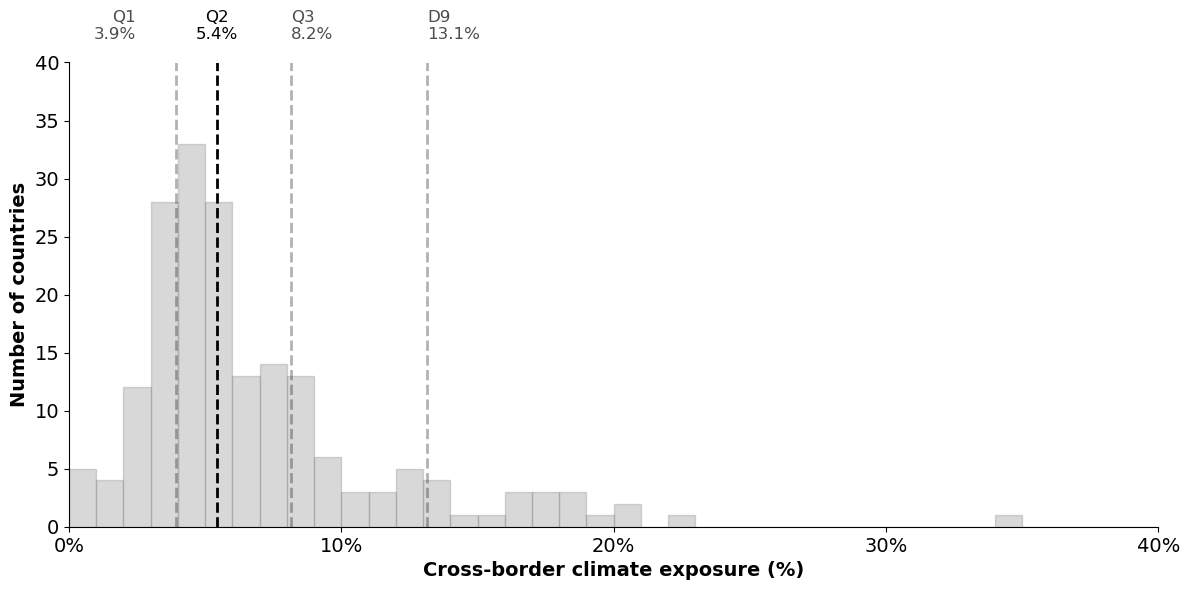

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
plt.rcdefaults()
# Assuming df is your DataFrame
df = resulting_dataframe_country_imports_interm_leontief

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

color_palette = sns.color_palette("Set1", 7)

# Define the number of bins and calculate the bin edges
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Count rows for the entire dataset
total_row_counts = count_rows_in_bins(df, bins, 'High Risk Exposure (%)')
data_to_plot = total_row_counts
color = 'grey'

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center', edgecolor='grey', alpha=0.3)

# Calculate and plot median and quartiles
flat_data = df['High Risk Exposure (%)']
median_value = np.median(flat_data)
first_quartile = np.percentile(flat_data, 25)
third_quartile = np.percentile(flat_data, 75)
ninth_decile = np.percentile(flat_data, 90)

plt.axvline(median_value, color='black', linestyle='dashed', linewidth=2)
plt.axvline(first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
plt.axvline(third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
plt.axvline(ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)

# Annotate the lines
plt.text(median_value, 42 , f'Q2\n{median_value:.1f}%', horizontalalignment='center', color='black',fontsize=12)
plt.text(first_quartile-1.5, 42, f'Q1\n{first_quartile:.1f}%', horizontalalignment='right', color='black', alpha=0.7,fontsize=12)
plt.text(third_quartile, 42, f'Q3\n{third_quartile:.1f}%', horizontalalignment='left', color='black', alpha=0.7,fontsize=12)
plt.text(ninth_decile, 42, f'D9\n{ninth_decile:.1f}%', horizontalalignment='left', color='black', alpha=0.7,fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Titles
plt.xlabel('Cross-border climate exposure (%)',fontsize=14,fontweight='bold')
plt.ylabel('Number of countries',fontsize=14,fontweight='bold')

plt.xlim([0, 40])
plt.ylim([0, 40])

plt.tight_layout()

#plt.savefig(r"Figures\Supp Mat\B\Fig1a.png")

plt.show()

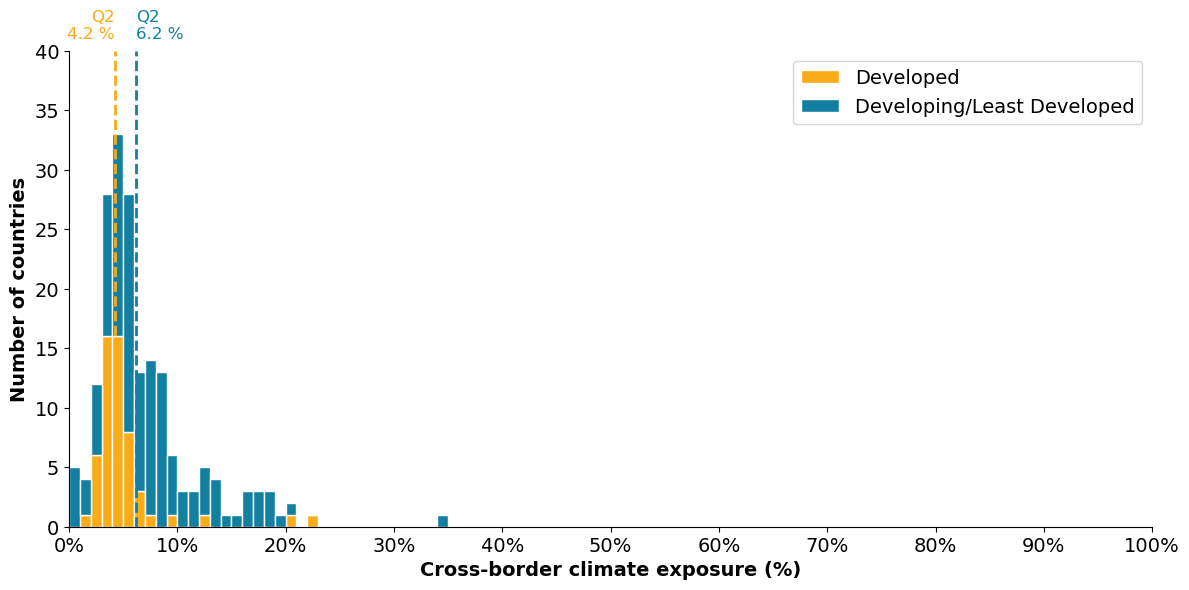

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_imports_interm_leontief

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

# Define the number of bins and calculate the bin edges
#bins = np.linspace(0, round(df['High Risk'].max(), 0) + 2, 30)
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Separate the data into two groups based on 'Development'
developed_df = df[df['Development'] == 'Developed']
not_developed_df = df[df['Development'] != 'Developed']
#developed_df = df[df['Local Risk'] == 'High Risk']
#not_developed_df = df[df['Local Risk'] != 'Low Risk']

developed_row_counts = count_rows_in_bins(developed_df, bins, 'High Risk Exposure (%)')
not_developed_row_counts = count_rows_in_bins(not_developed_df, bins, 'High Risk Exposure (%)')
data_to_plot = [developed_row_counts, not_developed_row_counts]

# Custom colors for the bars
color = ['#FAAB18', '#1380A1']  # Orange for Developed, Blue for Developing/Least Developed
label = ['Developed', 'Developing/Least Developed']
#label = ['High local risk', 'Low local risk']

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='white')
plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='white')
plt.legend()

# Calculate and plot median and quartiles for Developed countries
developed_flat_data = developed_df['High Risk Exposure (%)']
developed_median_value = np.median(developed_flat_data)
developed_first_quartile = np.percentile(developed_flat_data, 25)
developed_third_quartile = np.percentile(developed_flat_data, 75)

plt.axvline(developed_median_value, color=color[0], linestyle='dashed', linewidth=2)
#plt.axvline(developed_first_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(developed_third_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)

# Calculate and plot median and quartiles for Not Developed countries
not_developed_flat_data = not_developed_df['High Risk Exposure (%)']
not_developed_median_value = np.median(not_developed_flat_data)
not_developed_first_quartile = np.percentile(not_developed_flat_data, 25)
not_developed_third_quartile = np.percentile(not_developed_flat_data, 75)

plt.axvline(not_developed_median_value, color=color[1],  linestyle='dashed', linewidth=2)
#plt.axvline(not_developed_first_quartile, color=color[1], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(not_developed_third_quartile, color=color[1],linestyle='dashed', linewidth=2, alpha=0.3)

plt.text(not_developed_median_value, 41 , f'Q2\n{not_developed_median_value:.1f} %', horizontalalignment='left', color=color[1],fontsize=12)
plt.text(developed_median_value, 41, f'Q2\n{developed_median_value:.1f} %', horizontalalignment='right', color=color[0],fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)


# Titles
plt.xlabel('Cross-border climate exposure (%)',fontsize=14, fontweight='bold')
plt.ylabel('Number of countries', fontsize=14, fontweight='bold')

plt.xlim([0, 100])
plt.ylim([0, 40])

plt.legend(fontsize=14)

plt.tight_layout()
#plt.savefig(r"Figures\Supp Mat\B\Fig4a.png") # Intermediate Cons

#plt.savefig(r"Figures\Supp Mat\C\Fig4a.png") # Intermediate Cons
#plt.savefig(r"Figures\Supp Mat\C\Fig4b.png") # Final Cons
#plt.savefig(r"Figures\Supp Mat\C\Fig4c.png") # Exports interm
#plt.savefig(r"Figures\Supp Mat\C\Fig4d.png") # Exports fin


plt.show()

##### Share of Risky Partners 


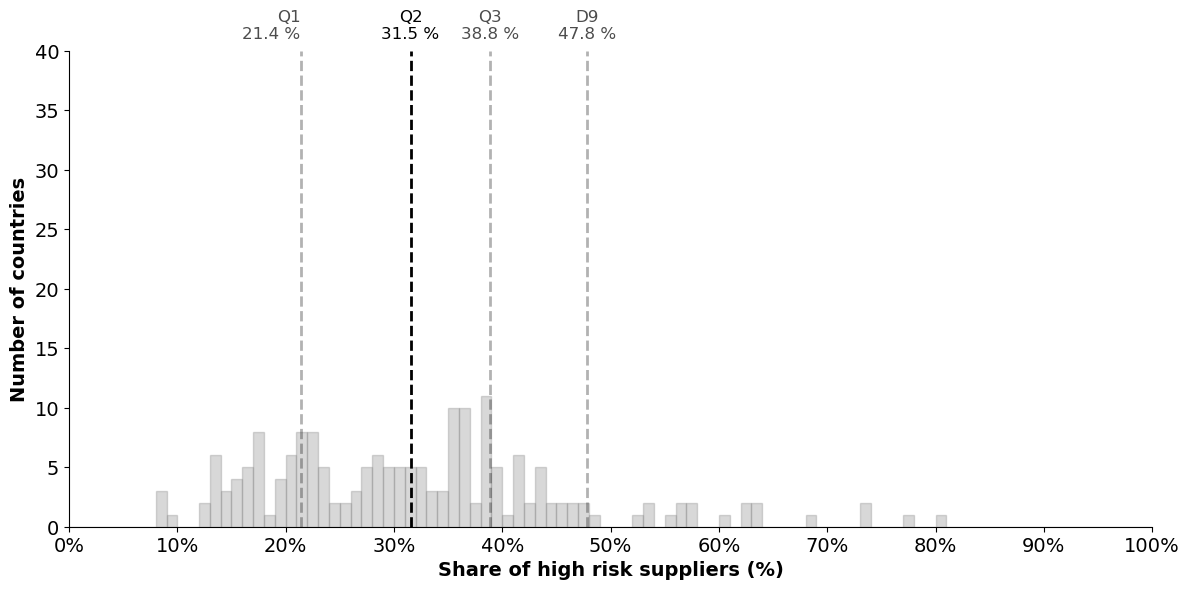

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_imports_interm_leontief

def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

color_palette = sns.color_palette("Set1", 7)

def plot_country_distribution(df, graph_type='total', x_max=None, y_max=None):
    """
    Plots the specified type of country distribution graph.

    :param df: DataFrame with the data.
    :param graph_type: Type of graph ('total' or 'risk_comparison').
    :param x_max: Maximum value for the x-axis.
    :param y_max: Maximum value for the y-axis.
    """
    # Define the number of bins and calculate the bin edges
    bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

    if graph_type == 'total':
        # Count rows for the entire dataset
        total_row_counts = count_rows_in_bins(df, bins, 'Share of Risky Trade Partners (%)')
        data_to_plot = total_row_counts
        color = 'grey'
        label = None
    elif graph_type == 'risk_comparison':
        # Separate the data into two groups based on 'Local Risk'
        low_risk_df = df[df['Local Risk'] == 'Low Risk Exposure (%)']
        high_risk_df = df[df['Local Risk'] == 'Share of Risky Trade Partners (%)']
        low_risk_row_counts = count_rows_in_bins(low_risk_df, bins, 'Share of Risky Trade Partners (%)')
        high_risk_row_counts = count_rows_in_bins(high_risk_df, bins, 'Share of Risky Trade Partners (%)')
        data_to_plot = [low_risk_row_counts, high_risk_row_counts]
        color = [color_palette[1], color_palette[0]]
        label = ['Low Local Risk', 'High Local Risk']

    # Width of the bars
    bar_width = (bins[1] - bins[0])
    bar_positions = bins[:-1] + bar_width / 2

    # Create a plot
    plt.figure(figsize=(12, 6))

    if graph_type == 'total':
        plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center', edgecolor='grey', alpha=0.3)
    elif graph_type == 'risk_comparison':
        plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='grey')
        plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='grey')
        plt.legend()

    # Calculate and plot median and quartiles if data_to_plot is not None
    flat_data = df['Share of Risky Trade Partners (%)']
    median_value = np.median(flat_data)
    first_quartile = np.percentile(flat_data, 25)
    third_quartile = np.percentile(flat_data, 75)
    ninth_decile = np.percentile(flat_data, 90)

    plt.axvline(median_value, color='black', linestyle='dashed', linewidth=2)
    plt.axvline(first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)

    # Annotate the lines
    plt.text(median_value, 41, f'Q2\n{median_value:.1f} %', horizontalalignment='center', color='black',fontsize=12)
    plt.text(first_quartile, 41, f'Q1\n{first_quartile:.1f} %', horizontalalignment='right', color='black', alpha=0.7,fontsize=12)
    plt.text(third_quartile, 41, f'Q3\n{third_quartile:.1f} %', horizontalalignment='center', color='black', alpha=0.7,fontsize=12)
    plt.text(ninth_decile, 41, f'D9\n{ninth_decile:.1f} %', horizontalalignment='center', color='black', alpha=0.7,fontsize=12)

    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # Titles
    plt.xlabel('Share of high risk suppliers (%)',fontsize=14,fontweight='bold')
    plt.ylabel('Number of countries',fontsize=14,fontweight='bold')

    if x_max is not None:
        ax.set_xlim([0, x_max])
    if y_max is not None:
        ax.set_ylim([0, y_max])

    plt.tight_layout()
    #plt.savefig(r"Figures\Supp Mat\B\Fig3a.png")

    plt.show()
        
# Usage examples
graph = "total" 
# graph='risk_comparison'
plot_country_distribution(df, graph_type=graph, x_max=100, y_max=40)

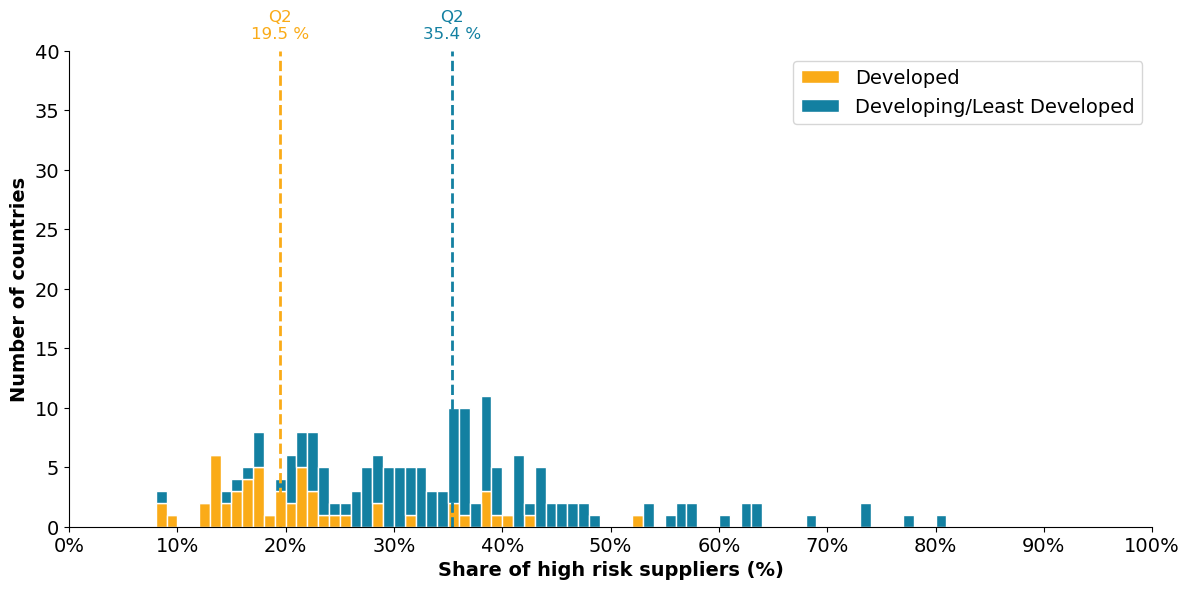

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_imports_interm_leontief

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

# Define the number of bins and calculate the bin edges
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Separate the data into two groups based on 'Development'
developed_df = df[df['Development'] == 'Developed']
not_developed_df = df[df['Development'] != 'Developed']
developed_row_counts = count_rows_in_bins(developed_df, bins, 'Share of Risky Trade Partners (%)')
not_developed_row_counts = count_rows_in_bins(not_developed_df, bins, 'Share of Risky Trade Partners (%)')
data_to_plot = [developed_row_counts, not_developed_row_counts]
# Custom colors for the bars
color = ['#FAAB18', '#1380A1']  # Orange for Developed, Blue for Developing/Least Developed
label = ['Developed', 'Developing/Least Developed']

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='white')
plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='white')
plt.legend()

# Calculate and plot median and quartiles for Developed countries
developed_flat_data = developed_df['Share of Risky Trade Partners (%)']
developed_median_value = np.median(developed_flat_data)
developed_first_quartile = np.percentile(developed_flat_data, 25)
developed_third_quartile = np.percentile(developed_flat_data, 75)

plt.axvline(developed_median_value, color=color[0], linestyle='dashed', linewidth=2)
#plt.axvline(developed_first_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(developed_third_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)

# Calculate and plot median and quartiles for Not Developed countries
not_developed_flat_data = not_developed_df['Share of Risky Trade Partners (%)']
not_developed_median_value = np.median(not_developed_flat_data)
not_developed_first_quartile = np.percentile(not_developed_flat_data, 25)
not_developed_third_quartile = np.percentile(not_developed_flat_data, 75)

plt.axvline(not_developed_median_value, color=color[1],  linestyle='dashed', linewidth=2)
#plt.axvline(not_developed_first_quartile, color=color[1], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(not_developed_third_quartile, color=color[1],linestyle='dashed', linewidth=2, alpha=0.3)
plt.text(not_developed_median_value, 41 , f'Q2\n{not_developed_median_value:.1f} %', horizontalalignment='center', color=color[1],fontsize=12)
plt.text(developed_median_value, 41, f'Q2\n{developed_median_value:.1f} %', horizontalalignment='center', color=color[0],fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Titles
plt.xlabel('Share of high risk suppliers (%)', fontsize=14, fontweight='bold')
plt.ylabel('Number of countries', fontsize=14, fontweight='bold')

plt.legend(fontsize=14)

plt.xlim([0, 100])
plt.ylim([0, 40])

plt.tight_layout()
#plt.savefig(r"Figures\Supp Mat\B\Fig4c.png")

plt.show()

##### Dependence to Foreign Countries

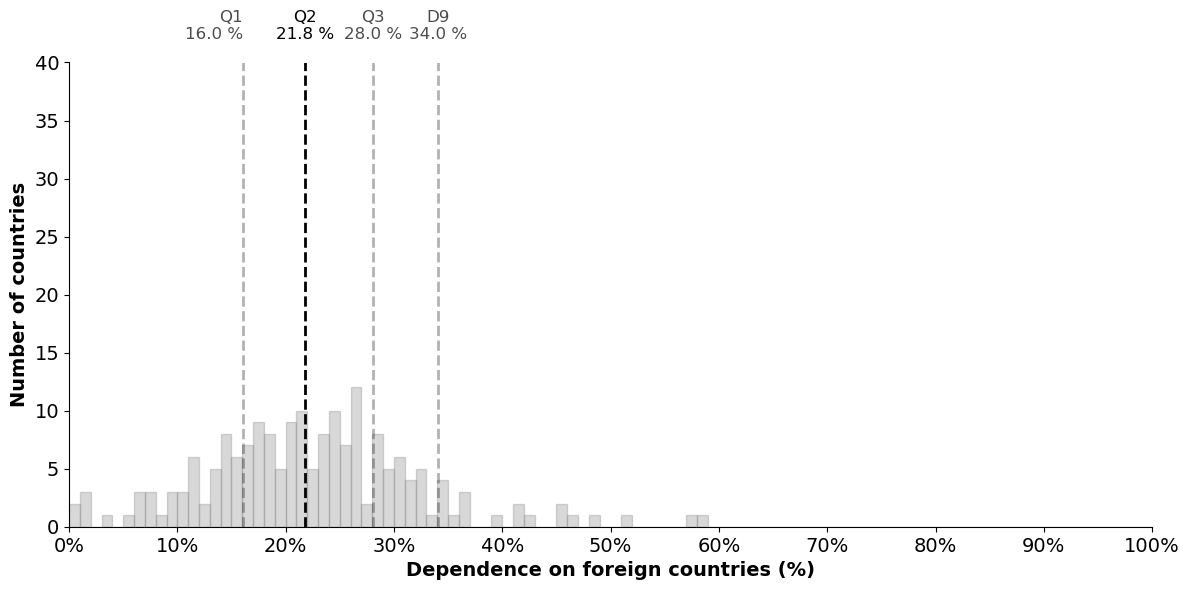

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_imports_interm_leontief

def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

color_palette = sns.color_palette("Set1", 7)

def plot_country_distribution(df, graph_type='total', x_max=None, y_max=None):
    """
    Plots the specified type of country distribution graph.

    :param df: DataFrame with the data.
    :param graph_type: Type of graph ('total' or 'risk_comparison').
    :param x_max: Maximum value for the x-axis.
    :param y_max: Maximum value for the y-axis.
    """
    # Define the number of bins and calculate the bin edges
    #bins = np.linspace(0, round(df['Foreign (%)'].max(), 0) + 2, 30)
    bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

    if graph_type == 'total':
        # Count rows for the entire dataset
        total_row_counts = count_rows_in_bins(df, bins, 'Foreign (%)')
        data_to_plot = total_row_counts
        color = 'grey'
        label = None
    elif graph_type == 'risk_comparison':
        # Separate the data into two groups based on 'Local Risk'
        low_risk_df = df[df['Local Risk'] == 'Low Risk Exposure (%)']
        high_risk_df = df[df['Local Risk'] == 'Foreign (%)']
        low_risk_row_counts = count_rows_in_bins(low_risk_df, bins, 'Foreign (%)')
        high_risk_row_counts = count_rows_in_bins(high_risk_df, bins, 'Foreign (%)')
        data_to_plot = [low_risk_row_counts, high_risk_row_counts]
        color = [color_palette[1], color_palette[0]]
        label = ['Low Local Risk', 'High Local Risk']

    # Width of the bars
    bar_width = (bins[1] - bins[0])
    bar_positions = bins[:-1] + bar_width / 2

    # Create a plot
    plt.figure(figsize=(12, 6))

    if graph_type == 'total':
        plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center', edgecolor='grey', alpha=0.3)
    elif graph_type == 'risk_comparison':
        plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='grey')
        plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='grey')
        plt.legend()

    # Calculate and plot median and quartiles if data_to_plot is not None
    flat_data = df['Foreign (%)']
    median_value = np.median(flat_data)
    first_quartile = np.percentile(flat_data, 25)
    third_quartile = np.percentile(flat_data, 75)
    ninth_decile = np.percentile(flat_data, 90)

    plt.axvline(median_value, color='black', linestyle='dashed', linewidth=2)
    plt.axvline(first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)

    # Annotate the lines
    plt.text(median_value, 42, f'Q2\n{median_value:.1f} %', horizontalalignment='center', color='black',fontsize=12)
    plt.text(first_quartile, 42, f'Q1\n{first_quartile:.1f} %', horizontalalignment='right', color='black', alpha=0.7,fontsize=12)
    plt.text(third_quartile, 42, f'Q3\n{third_quartile:.1f} %', horizontalalignment='center', color='black', alpha=0.7,fontsize=12)
    plt.text(ninth_decile, 42, f'D9\n{ninth_decile:.1f} %', horizontalalignment='center', color='black', alpha=0.7,fontsize=12)

    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels([f'{x}%' for x in custom_ticks])
    ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # Titles
    plt.xlabel('Dependence on foreign countries (%)',fontsize=14,fontweight='bold')
    plt.ylabel('Number of countries',fontsize=14,fontweight='bold')

    if x_max is not None:
        ax.set_xlim([0, x_max])
    if y_max is not None:
        ax.set_ylim([0, y_max])

    plt.tight_layout()
    #plt.savefig(r"Figures\Supp Mat\B\Fig2a.png")

    plt.show()
        
# Usage examples
graph = "total" 
# graph='risk_comparison'
plot_country_distribution(df, graph_type=graph, x_max=100, y_max=40)

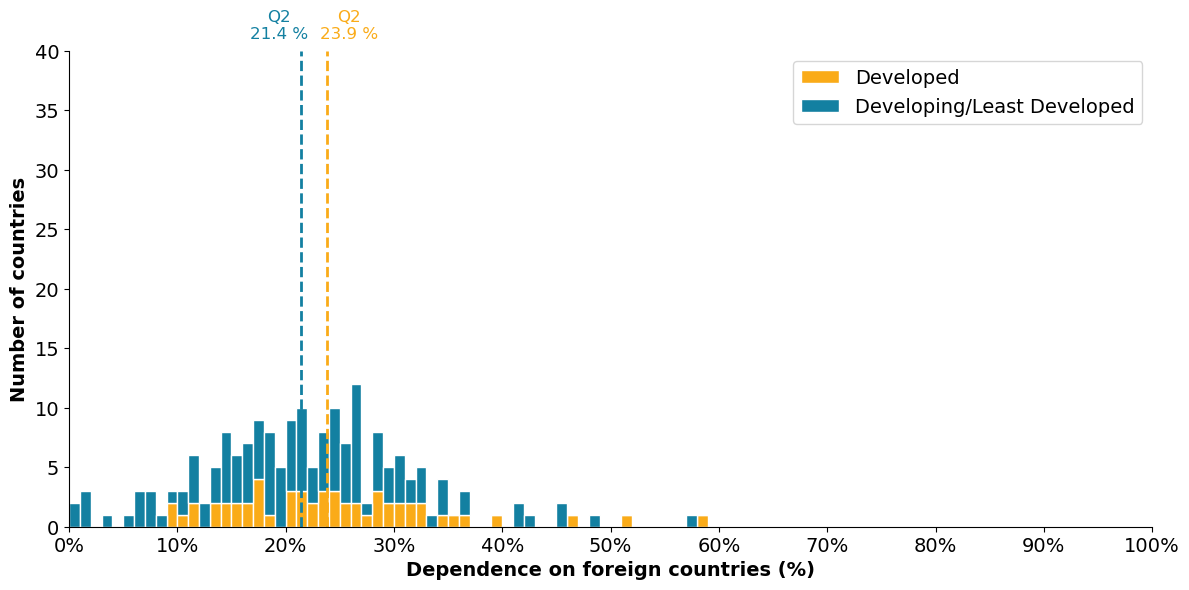

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_imports_interm_leontief

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

# Define the number of bins and calculate the bin edges
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Separate the data into two groups based on 'Development'
developed_df = df[df['Development'] == 'Developed']
not_developed_df = df[df['Development'] != 'Developed']
developed_row_counts = count_rows_in_bins(developed_df, bins, 'Foreign (%)')
not_developed_row_counts = count_rows_in_bins(not_developed_df, bins,  'Foreign (%)')
data_to_plot = [developed_row_counts, not_developed_row_counts]
# Custom colors for the bars
color = ['#FAAB18', '#1380A1']  # Orange for Developed, Blue for Developing/Least Developed
label = ['Developed', 'Developing/Least Developed']

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='white')
plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='white')
plt.legend()

# Calculate and plot median and quartiles for Developed countries
developed_flat_data = developed_df['Foreign (%)']
developed_median_value = np.median(developed_flat_data)
developed_first_quartile = np.percentile(developed_flat_data, 25)
developed_third_quartile = np.percentile(developed_flat_data, 75)

plt.axvline(developed_median_value, color=color[0], linestyle='dashed', linewidth=2)
#plt.axvline(developed_first_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(developed_third_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)

# Calculate and plot median and quartiles for Not Developed countries
not_developed_flat_data = not_developed_df['Foreign (%)']
not_developed_median_value = np.median(not_developed_flat_data)
not_developed_first_quartile = np.percentile(not_developed_flat_data, 25)
not_developed_third_quartile = np.percentile(not_developed_flat_data, 75)

plt.axvline(not_developed_median_value, color=color[1],  linestyle='dashed', linewidth=2)
#plt.axvline(not_developed_first_quartile, color=color[1], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(not_developed_third_quartile, color=color[1],linestyle='dashed', linewidth=2, alpha=0.3)
plt.text(not_developed_median_value-2, 41 , f'Q2\n{not_developed_median_value:.1f} %', horizontalalignment='center', color=color[1],fontsize=12)
plt.text(developed_median_value+2, 41, f'Q2\n{developed_median_value:.1f} %', horizontalalignment='center', color=color[0],fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Titles
plt.xlabel('Dependence on foreign countries (%)', fontsize=14, fontweight='bold')
plt.ylabel('Number of countries', fontsize=14, fontweight='bold')

plt.legend(fontsize=14)

plt.xlim([0, 100])
plt.ylim([0, 40])

plt.tight_layout()
#plt.savefig(r"Figures\Supp Mat\B\Fig4e.png")

plt.show()

##### Exposure = FD x SRP

(low/high risk // developing/developed)

In [ ]:
import numpy as np
# Assuming df is your DataFrame
df = resulting_dataframe_country_imports_interm_leontief
#df = resulting_dataframe_country_cons_leontief
#df = resulting_dataframe_country_exports_leontief_CI
#df = resulting_dataframe_country_exports_leontief_CF

l = 'High Risk Exposure (%)'
#l="Share of Risky Trade Partners (%)"
#l='Foreign (%)'
# Separate the data into two groups based on 'Development'
developed_df = df[df['Development'] == 'Developed']
not_dev_df = df[df['Development']!='Developed']
#risky_df=df[df['Local Risk'] == 'High Risk']
#not_risky_df=df[df['Local Risk'] == 'Low Risk']

print('Dev =',np.median(developed_df[l]),'Not dev:',np.median(not_dev_df[l]))
#print('Low Risk =',np.median(not_risky_df[l]),'High Risk =',np.median(risky_df[l]))


Dev = 24.452824671470097 Not dev: 16.63509815004401


In [ ]:
import pandas as pd
import numpy as np

# Load your data (assuming separate files or sources for each)
df_inputs = resulting_dataframe_country_imports_interm_leontief  # For 'Inputs'
df_cons = resulting_dataframe_country_imports_fin_leontief      # For 'Cons'
df_exports_ci = resulting_dataframe_country_exports_interm_leontief  # For 'Exports CI'
df_exports_cf = resulting_dataframe_country_exports_fin_leontief  # For 'Exports CF'

# Mapping categories to their respective DataFrames
dataframes = {
    'Imports Interm.': df_inputs,
    'Imports Fin.': df_cons,
    'Exports Interm.': df_exports_ci,
    'Exports Fin.': df_exports_cf
}

# Columns to calculate medians for
metrics = [
    "High Risk Exposure (%)",
    "Share of Risky Trade Partners (%)",
    "Foreign (%)"]

# Results DataFrame
results = pd.DataFrame(index=pd.MultiIndex.from_product([dataframes.keys(), ['Dev', 'Not Dev']]), columns=metrics)

# Loop over categories and metrics to compute medians for each group
for category, df in dataframes.items():
    developed_df = df[df['Development'] == 'Developed']
    not_developed_df = df[df['Development'] != 'Developed']

    for metric in metrics:
        # Compute medians and store in results DataFrame
        results.loc[(category, 'Dev'), metric] = np.median(developed_df[metric].dropna())
        results.loc[(category, 'Not Dev'), metric] = np.median(not_developed_df[metric].dropna())

# Save results to Excel
results.to_excel('Figures/Computed_Medians.xlsx')

In [ ]:
df = resulting_dataframe_country_imports_interm_leontief
median_high_risk = df[(df['Region'] != 'Europe & Central Asia') & (df['Development'] == 'Developed')]['Share of Risky Trade Partners (%)'].median()
median_high_risk

30.144808319652387

#### Correlation Fig

c:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\AppData\Local\Temp\ipykernel_32660\3421459849.py:38: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(x='Local Climate Risk',

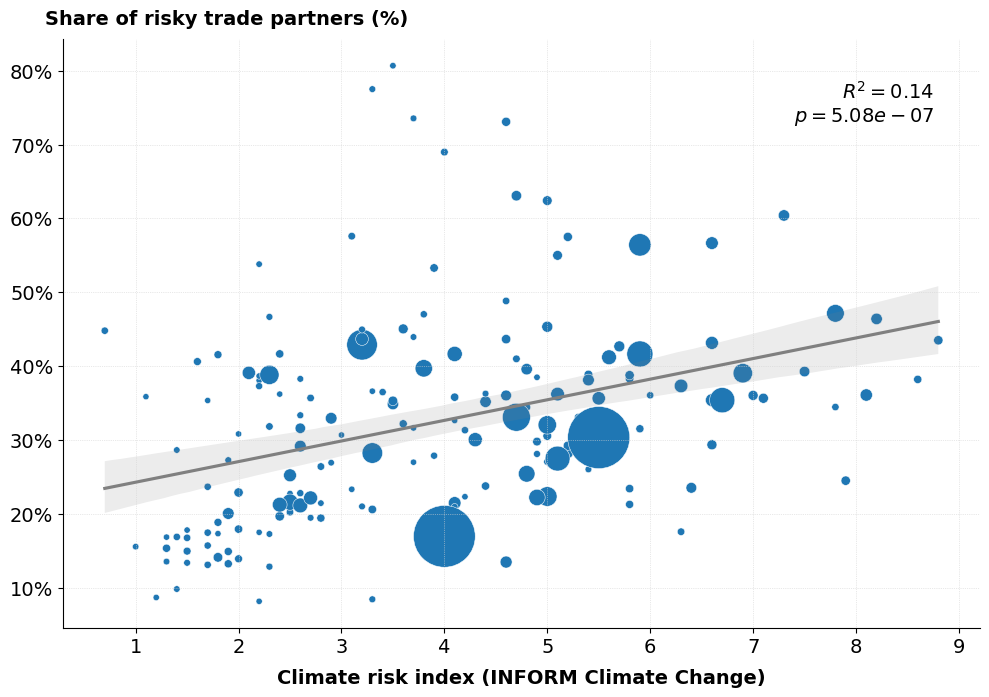

In [26]:
result = resulting_dataframe_country_imports_interm_leontief
result = result.dropna(subset=['Local Climate Risk'])

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
import matplotlib.ticker as mticker

# Define a custom color palette (You can choose your own colors)
custom_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

#color_choice='no_color'
color_choice='no_color'

if color_choice == 'no_correlation':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)
    
if color_choice == 'no_color':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(10, 7))
    scatter = sns.scatterplot(x='Local Climate Risk', y='Share of Risky Trade Partners (%)',
                              data=result, 
                              palette=custom_palette, 
                              size='Population', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)

if color_choice == 'Country':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              hue='Country', 
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    #plt.legend().set_visible(False)

if color_choice=='income':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Income group',  # Use 'Income group' for color coding
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_income_groups = len(result['Income group'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[:num_income_groups], labels=labels[:num_income_groups], loc='upper left', bbox_to_anchor=(1, 1))


if color_choice == 'developed/developping':
    # Create a scatter plot with the custom color palette
    custom_palette = {
    'Developed': '#167EB8',  # Blue
    'Developing': '#E09819',  # Orange
    'Least Developed': '#D96B16'  # Reddish-Orange
    }
    plt.figure(figsize=(10, 7))
    scatter = sns.scatterplot(x='Local Climate Risk', y='Share of Risky Trade Partners (%)',
                          hue='Development', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population', 
                          sizes=(20, 2000),
                          alpha=0.8)  # Adjust alpha for less transparency

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Development'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

if color_choice == 'region':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Region', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Region'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

    
# Suppress the top and right spines
#####
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# R-squared + regression
######
x = result['Local Climate Risk']
y = result['Share of Risky Trade Partners (%)']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
plt.text(0.95, 0.85, f'$R^2 = {r_squared:.2f}$\n$p = {p_value:.2e}$', transform=plt.gca().transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

# Regression
sns.regplot(x='Local Climate Risk', y='Share of Risky Trade Partners (%)', data=result, scatter=False, color='gray')  # scatter=False to avoid duplicate points


# Format (percentage, space, etc.)
######
fmt = lambda x, _: '{:.0f}%'.format(x)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
ax.set_xlabel('')  # Suppress the x-axis and y-axis titles
ax.set_ylabel('')
plt.subplots_adjust(right=0.75) # Adjust the subplot parameters to give some space for the legend
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

ax.tick_params(axis='x', labelsize=14)  # Adjust x-axis label sizes
ax.tick_params(axis='y', labelsize=14)  # Adjust y-axis label sizes

#Titles
#####
plt.text(0.5, -0.1, 'Climate risk index (INFORM Climate Change)', ha='center', va='bottom', transform=ax.transAxes, fontsize=14, fontweight='bold')
plt.text(-0.02, 1.05, 'Share of risky trade partners (%)', ha='left', va='top', transform=ax.transAxes, fontsize=14,fontweight='bold') 

plt.tight_layout()
#plt.savefig(r"Figures\Supp Mat\C\Fig3a.png")
#plt.savefig(r"Figures\Main text\Fig3c.png")

# Show the plot
#####
plt.show()

#### XY Fig

##### Plot

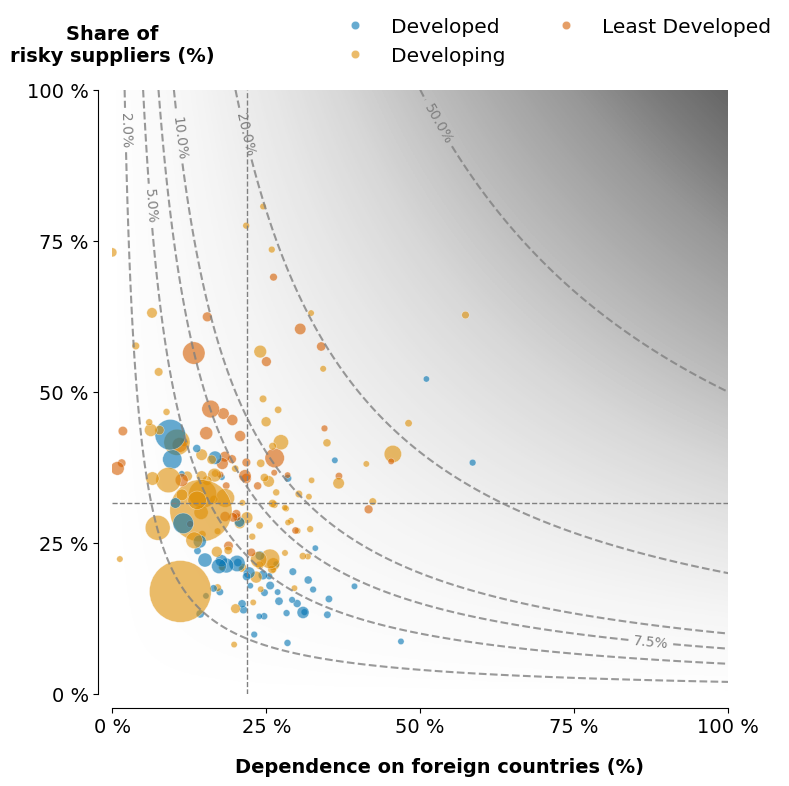

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter, MaxNLocator

result = resulting_dataframe_country_imports_interm_leontief
constants = [200, 500, 750, 1000, 2000,5000]

# Adjust the figure size as needed
plt.figure(figsize=(8, 8))


# Create a gradient background from bottom left (dark) to top right (light)
x = np.linspace(0, 10, 256)
y = np.linspace(0, 10, 256)

z = np.outer(y,x)

plt.imshow(z, aspect='auto', extent=[0, 100, 0, 100], origin='lower', cmap='Greys',alpha=0.6)

plt.ylim(0, 100)
plt.xlim(0, 100)

# Create a gradient background from bottom left (dark) to top right (light)
x = np.linspace(0, 100, 256)
y = np.linspace(0, 100, 256)
X, Y = np.meshgrid(x, y)
Z = X * Y  # Adjust this function as needed to match the background gradient

# Create contour plot
contour = plt.contour(X, Y, Z, constants, colors='grey', linestyles='dashed', alpha=0.8)

# Label each contour line with its respective value divided by 1000
fmt = lambda x: f"{x/100:.1f}%"
clabels = plt.clabel(contour, fmt=fmt, inline=True, fontsize=10, colors='black')

# Adjust label colors to make them darker than contour lines
for label in clabels:
    label.set_color('grey')

    
for const in constants:
    y_hyperbola = const / np.linspace(1, 99, 100)
    #plt.plot(np.linspace(1, 99, 100), y_hyperbola, linestyle='--', color='grey', alpha=0.3)
    # Adding text for the value of the constant
    #plt.text(104, const / 100, f'{const/10000:.0%}', verticalalignment='bottom', horizontalalignment='right', color='black')

custom_palette = ['blue', 'orange', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']
palette = sns.color_palette(palette="colorblind", as_cmap=True)
# Colorblind-friendly palette
risk_palette = {'Developed': palette[0],  # Sky Blue
                'Developing': palette[1],
               "Least Developed":palette[3]}  # Coral

color_choice = 'developed/developing'

if color_choice == 'developed/developing':
    scatter = sns.scatterplot(
        x='Foreign (%)', 
        y='Share of Risky Trade Partners (%)',
        hue='Development', 
        data=result, 
        palette=risk_palette, 
        size='Population', 
        sizes=(20, 2000),
        alpha=0.6
    )

    handles, labels = scatter.get_legend_handles_labels()
    num_developed_groups = len(result['Development'].unique())

    # Modified legend: No box and adjusted position
    plt.legend(
        handles=handles[1:num_developed_groups+1], 
        labels=labels[1:num_developed_groups+1], 
        loc='upper right',  # Change location as needed
        bbox_to_anchor=(1.1,1.15),
        frameon=False,      # Suppress the legend box
        fontsize=14.5,
        ncol=2
    )

    
# Add letters to each quadrant
#plt.text(5, 5, 'A', fontsize=20, fontweight='bold')
#plt.text(13, 95, 'B', fontsize=20, fontweight='bold')
#plt.text(95, 14, 'C', fontsize=20, fontweight='bold')
#plt.text(95, 95, 'D', fontsize=20, fontweight='bold')

median_x = result['Foreign (%)'].median()
median_y = result['Share of Risky Trade Partners (%)'].median()
plt.axvline(x=median_x, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=median_y, color='gray', linestyle='--', linewidth=1)

# Return the spines to original positions
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

scatter.set(xlabel=None, ylabel=None)
plt.text(20, -12, 'Dependence on foreign countries (%)', fontsize=14, va='center', ha='left', weight='bold')
plt.text(0, 104, 'Share of\nrisky suppliers (%)', fontsize=14, va='bottom', ha='center', weight='bold')

scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

def percentage_formatter(x, pos):
    return f'{int(x)} %'

x_formatter = FuncFormatter(percentage_formatter)
scatter.xaxis.set_major_formatter(x_formatter)
scatter.yaxis.set_major_formatter(x_formatter)

locator = MaxNLocator(nbins=4)  # Set the number of bins to control the tick frequency
scatter.xaxis.set_major_locator(locator)
scatter.yaxis.set_major_locator(locator)
# Setting the fontsize for tick labels on both axes
plt.xticks(fontsize=14)  # Adjust fontsize as needed
plt.yticks(fontsize=14)  # Adjust fontsize as needed

#plt.grid(False, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
#plt.text(-0.1, 1.17, "Absolute Risk = Foreign Dependent + Risky Suppliers", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(-0.1, 1.13, "Aggregated at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.tight_layout()
#plt.savefig(r"Figures\Supp Mat\C\Fig1a.png")
#plt.savefig(r"Figures\Main Text\Fig3a.png")

plt.show()

##### Exporting data

In [ ]:
df = resulting_dataframe_country_imports_interm_leontief

# Importing the pandas library
import pandas as pd

median_high_risk_relative = df['High Risk Exposure (%)'].median()
median_foreign = df['Foreign (%)'].median()

# Add columns to indicate if each row is over or under the median for the specified columns
df['Share of Risky Trade Partners (%) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk trade partners' if x > median_high_risk_relative else 'Low-risk trade partners')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

# Exporting to an Excel file
#df.to_excel(r"Figures\fig1a.xlsx", index=False) # Inputs 
#df.to_excel(r"Figures\fig1b.xlsx", index=False) # Cons 
#df.to_excel(r"Figures\fig1c.xlsx", index=False) # E CI
#df.to_excel(r"Figures\fig1d.xlsx", index=False) # E CF

In [20]:
df

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%),Share of Risky Trade Partners (%) Category,Foreign (%) Category
1,"Moldova, Republic of",MDA,2.6,Low Risk,Europe & Central Asia,Upper middle income,2464653.0,Developed,33.793746,20.966098,3.756249,58.516092,41.483908,38.287359,High-risk trade partners,Foreign-oriented
2,"China, Hong Kong SAR",HKG,NaN,Unknown,East Asia & Pacific,High income,7350409.0,Developing,20.666534,34.763729,1.924264,57.354527,42.645473,62.716153,High-risk trade partners,Foreign-oriented
3,San Marino,SMR,NaN,Unknown,Europe & Central Asia,High income,33642.0,Developed,20.931186,22.792322,7.282960,51.006468,48.993532,52.128302,High-risk trade partners,Foreign-oriented
4,Singapore,SGP,0.7,Low Risk,East Asia & Pacific,High income,5673743.0,Developing,25.384308,20.610571,2.116494,48.111373,51.888627,44.810578,High-risk trade partners,Foreign-oriented
5,Luxembourg,LUX,1.2,Low Risk,Europe & Central Asia,High income,657569.0,Developed,42.572136,4.054165,0.247742,46.874044,53.125956,8.695018,High-risk trade partners,Foreign-oriented
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,Somalia,SOM,8.8,High Risk,Sub-Saharan Africa,Low income,18143378.0,Least Developed,0.914313,0.704293,0.095697,1.714303,98.285697,43.512299,High-risk trade partners,Locally-oriented
184,South Sudan,SDS,8.6,High Risk,Sub-Saharan Africa,Low income,11088796.0,Least Developed,0.880780,0.544763,0.102124,1.527666,98.472334,38.214409,High-risk trade partners,Locally-oriented
185,Guyana,GUY,4.2,High Risk,Latin America & Caribbean,High income,813834.0,Developing,0.944515,0.271583,0.008921,1.225018,98.774982,22.332327,High-risk trade partners,Locally-oriented
186,Myanmar,MMR,6.3,High Risk,East Asia & Pacific,Lower middle income,54577997.0,Least Developed,0.495507,0.295194,0.034045,0.824747,99.175253,37.333238,High-risk trade partners,Locally-oriented


#### Quadrant Bars Fig

C:\Users\delah\AppData\Local\Temp\ipykernel_25912\3791164014.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['High Risk (relative) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
C:\Users\delah\AppData\Local\Temp\ipykernel_25912\3791164014.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else

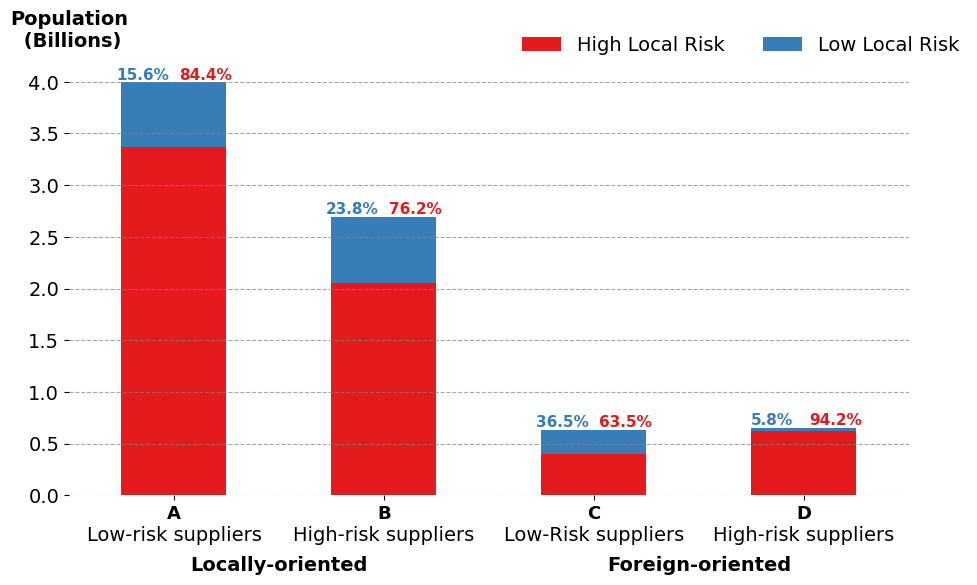

In [ ]:
import seaborn as sns
df = resulting_dataframe_country_imports_interm_leontief
df = df.dropna(subset=['Local Climate Risk'])

# Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
median_high_risk_relative = df['Share of Risky Trade Partners (%)'].median()
median_foreign = df['Foreign (%)'].median()

# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=11,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        
        
# Set labels and title
#plt.text(0, 1.2, "The Most Exposed Countries are all Risky Countries",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.13, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Suppress the scientific notation on the y-axis

# Customize the y-axis to show 'Billions' instead of scientific notation
def billions_formatter(x, pos):
    'The two args are the value and tick position'
    return '%1.1f' % (x * 1e-9)

ax.yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))

# Set labels, title, and other aesthetics
ax.set_xticklabels([index[1] for index in population_by_risk.index], rotation=0, fontsize=13)
plt.text(-0.5, 4.3e9, 'Population\n (Billions)', fontsize=14, va='bottom', ha='center', weight='bold')
ax.tick_params(axis='y', labelsize=14)  # Increase fontsize for y-axis tick labels

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['A', 'B', 'C', 'D']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=13,fontweight='bold')

second_level_labels = ['Low-risk suppliers', 'High-risk suppliers', 'Low-Risk suppliers', 'High-risk suppliers']

# Assuming there are four groups (you can adjust this according to your actual data)
four_positions = [i for i in range(len(population_by_risk.index))]

middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

# Add the third level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.14, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,fontweight='bold')
    
# Add the second level of labels
for pos, label in zip(four_positions, second_level_labels):
    ax.text(pos, -0.07, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,)


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.1),fontsize=14, ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")
plt.tight_layout()
# Show the plot
#plt.savefig(r"Figures\Main text\Fig3b.png")
#plt.savefig(r"Figures\Supp Mat\C\Fig2a.png")

plt.show()

In [47]:
import pandas as pd

# Assuming 'df' is your DataFrame prepared previously

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

# Group the sorted data by counting the number of countries in each group
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk']).size()

# Unstack the 'Local Risk' level to prepare for tabular presentation
countries_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
]

# Reorder the DataFrame according to the custom order
countries_by_risk = countries_by_risk.loc[custom_order]

# Add totals as a new column
countries_by_risk['Total'] = countries_by_risk.sum(axis=1)

# Display the table
print(countries_by_risk)

Local Risk                                          High Risk  Low Risk  Total
Foreign (%) Category High Risk (relative) Category                            
Locally-oriented     Low-risk suppliers                    18        20     38
                     High-risk suppliers                   35        14     49
Foreign-oriented     Low-risk suppliers                    14        35     49
                     High-risk suppliers                   26        12     38


In [ ]:
import pandas as pd

df=resulting_dataframe_country_imports_interm_leontief

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category'], ascending=[False, False])

# Group the sorted data by counting the number of countries in each group
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category', 'Local Risk']).size()

# Unstack the 'Local Risk' level to prepare for tabular presentation
countries_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk trade partners'),
    ('Locally-oriented', 'High-risk trade partners'),
    ('Foreign-oriented', 'Low-risk trade partners'),
    ('Foreign-oriented', 'High-risk trade partners'),
]

# Reorder the DataFrame according to the custom order
countries_by_risk = countries_by_risk.loc[custom_order]

# Convert absolute numbers to percentages within each group
countries_by_risk_percentage = countries_by_risk.div(countries_by_risk.sum(axis=1), axis=0) * 100

# Display the table with percentages
print(countries_by_risk_percentage)

KeyError: "[('Locally-oriented', 'Low-risk trade partners'), ('Foreign-oriented', 'Low-risk trade partners')] not in index"

In [49]:
a=df[(df['High Risk (relative) Category'] == 'High-risk suppliers') & (df['Foreign (%) Category'] == 'Foreign-oriented')]
a=a.sort_values('Population',ascending=False)
#a[a['Local Risk']=='Low Risk']

In [81]:
population_by_risk.to_excel(r"C:\Users\delah\OneDrive\Bureau\Figures\Main text\fig1b.xlsx", index=False)
population_by_risk

Local Risk                                             High Risk     Low Risk
Foreign (%) Category High Risk (relative) Category                           
Locally-oriented     Low-risk suppliers             3.381197e+09  621438809.0
                     High-risk suppliers            1.985680e+09  640302367.0
Foreign-oriented     Low-risk suppliers             4.014812e+08  236994578.0
                     High-risk suppliers            6.260549e+08   31356608.0

In [97]:
# Export the DataFrame to an Excel file
output_path = "C:/Users/delah/OneDrive/Bureau/Figures/Main text/fig1b.xlsx"
population_by_risk.to_excel(output_path)
population_by_risk

Local Risk                                             High Risk     Low Risk
Foreign (%) Category High Risk (relative) Category                           
Locally-oriented     Low-risk suppliers             3.381197e+09  621438809.0
                     High-risk suppliers            1.985680e+09  640302367.0
Foreign-oriented     Low-risk suppliers             4.014812e+08  236994578.0
                     High-risk suppliers            6.260549e+08   31356608.0

## Imports fin. cons.
----

### Calculating exposure

In [15]:
import pandas as pd

x = mriot.x
final_production_by_use = mriot.Y.copy()
y = final_production_by_use.sum(axis = 1)

L = mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()

multi_index = pd.MultiIndex.from_product([country_list, country_list, sector_list], names=['No risk country', 'Country', 'Sector'])

values = {'Low Risk': [0] * multi_index.size}
risk_cs_low = pd.DataFrame(values, index=multi_index)

values = {'High Risk': [0] * multi_index.size}
risk_cs_high = pd.DataFrame(values, index=multi_index)

values = {'ROW': [0] * multi_index.size}
risk_cs_row = pd.DataFrame(values, index=multi_index)

def indicator(element, lst):
    return 1 if element in lst else 0

for cc in country_list:   
    country_list_except = [x for x in country_list if x != cc]
    for c in country_list_except:
        for s in sector_list:
            low_risk_countries_except =  [x for x in low_risk_countries if x != cc] ## cc is not risky, but c is, if it is in high_risk_countries
            high_risk_countries_except =  [x for x in high_risk_countries if x != cc]
            no_risk_countries_except =  [x for x in no_risk_countries if x != cc]

            risk_cs_low.loc[cc,c,s] = y.loc[c,s]*indicator(c,low_risk_countries)+y.loc[c,s]*L[c,s].loc[low_risk_countries_except].sum()
            risk_cs_high.loc[cc,c,s] = y.loc[c,s]*indicator(c,high_risk_countries)+y.loc[c,s]*L[c,s].loc[high_risk_countries_except].sum()
            risk_cs_row.loc[cc,c,s] = y.loc[c,s]*indicator(c,no_risk_countries)+y.loc[c,s]*L[c,s].loc[no_risk_countries_except].sum()
            
            total = y.loc[c,s]+y.loc[c,s]*L[c,s].sum()
            
            risk_cs_low.loc[cc,c,s] = risk_cs_low.loc[cc,c,s]/total*100
            risk_cs_high.loc[cc,c,s] = risk_cs_high.loc[cc,c,s]/total*100
            risk_cs_row.loc[cc,c,s] = risk_cs_row.loc[cc,c,s]/total*100

    # List of DataFrames to concatenate
    risk_cs = [risk_cs_low, risk_cs_high,risk_cs_row]

    # Concatenate the DataFrames along columns (axis=1)
    risk_cs = pd.concat(risk_cs,axis=1)
    
# Replace all NaN values with zeros
risk_cs = risk_cs.fillna(0)

C:\Users\delah\AppData\Local\Temp\ipykernel_32660\4001598038.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1816687.9930424364' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  risk_cs_low.loc[cc,c,s] = y.loc[c,s]*indicator(c,low_risk_countries)+y.loc[c,s]*L[c,s].loc[low_risk_countries_except].sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_32660\4001598038.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '4415.629216357698' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  risk_cs_high.loc[cc,c,s] = y.loc[c,s]*indicator(c,high_risk_countries)+y.loc[c,s]*L[c,s].loc[high_risk_countries_except].sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_32660\4001598038.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a futur

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/risk_cs_imports_fin_leontief_inform_eora.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(risk_cs, f)

In [22]:
import pickle
import pandas as pd


# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/risk_cs_imports_fin_leontief_inform_eora.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    risk_cs = pickle.load(f)

In [ ]:
import pandas as pd

final_production_by_use = mriot.Y.copy()
y = final_production_by_use.sum(axis = 1) # final production of (c,s), whatever use

Y = final_production_by_use.T.groupby('region').sum().T

x = mriot.x # Gross output

L= mriot.L # Leontief matrix

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * country_list.size}
cConsoFin_low = pd.DataFrame(values, index=country_list)

values = {'High Risk': [0] * country_list.size}
cConsoFin_high = pd.DataFrame(values, index=country_list)

values = {'ROW': [0] * country_list.size}
cConsoFin_row = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cConsoFin_Foreign = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cConsoFin_Local = pd.DataFrame(values, index=country_list)

for cc in country_list:
    Y_cc = Y[cc]
    Y_cc_tot = Y_cc.sum()
    country_list_except = [x for x in country_list if x != cc]

    for c in country_list_except:
        for s in sector_list:
            cConsoFin_low.loc[cc] = cConsoFin_low.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['Low Risk']/100
            cConsoFin_high.loc[cc] = cConsoFin_high.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['High Risk']/100
            cConsoFin_row.loc[cc] = cConsoFin_row.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['ROW']/100

    cConsoFin_Foreign.loc[cc] = cConsoFin_low.loc[cc].iloc[0] + cConsoFin_high.loc[cc].iloc[0] + cConsoFin_row.loc[cc].iloc[0]
    cConsoFin_Local.loc[cc] = Y_cc_tot - cConsoFin_Foreign.loc[cc].iloc[0]

    #Ratios
    cConsoFin_low.loc[cc]=cConsoFin_low.loc[cc].iloc[0]/Y_cc_tot*100
    cConsoFin_high.loc[cc]=cConsoFin_high.loc[cc].iloc[0]/Y_cc_tot*100
    cConsoFin_row.loc[cc]=cConsoFin_row.loc[cc].iloc[0]/Y_cc_tot*100

    cConsoFin_Local.loc[cc]=cConsoFin_Local.loc[cc].iloc[0]/Y_cc_tot*100
    cConsoFin_Foreign.loc[cc]=cConsoFin_Foreign.loc[cc].iloc[0]/Y_cc_tot*100
    
# List of DataFrames to concatenate
dataframes_to_concat = [cConsoFin_low, cConsoFin_high,cConsoFin_row, cConsoFin_Foreign, cConsoFin_Local]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_cons_leontief = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_cons_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_country_imports_fin_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_864\860273869.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '76.04399171082369' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cConsoFin_low.loc[cc] = cConsoFin_low.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['Low Risk']/100
C:\Users\delah\AppData\Local\Temp\ipykernel_864\860273869.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.1848319980165863' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cConsoFin_high.loc[cc] = cConsoFin_high.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['High Risk']/100
C:\Users\delah\AppData\Local\Temp\ipykernel_864\860273869.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.01110024639427046' ha

In [ ]:
resulting_dataframe_country_imports_fin_leontief

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%)
1,Ethiopia,ETH,6.9,High Risk,Sub-Saharan Africa,Low income,126527060.0,Least Developed,54.486605,43.919776,0.816773,99.223154,0.776846,44.631025
2,Belarus,BLR,1.6,Low Risk,Europe & Central Asia,Upper middle income,9167767.0,Developed,66.622033,23.507186,1.698169,91.827387,8.172613,26.081648
3,"Moldova, Republic of",MDA,2.6,Low Risk,Europe & Central Asia,Upper middle income,2464653.0,Developed,36.859454,26.499148,4.707901,68.066504,31.933496,41.824073
4,Malta,MLT,1.5,Low Risk,Middle East & North Africa,High income,524909.0,Developed,46.128691,7.761723,0.718654,54.609067,45.390933,14.402789
5,"China, Hong Kong SAR",HKG,NaN,Unknown,East Asia & Pacific,High income,7350409.0,Developing,18.412410,25.859340,2.446729,46.718478,53.281522,58.410476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,Sudan,SUD,6.6,High Risk,Sub-Saharan Africa,Low income,48109006.0,Least Developed,0.961843,0.559375,0.077867,1.599085,98.400915,36.771511
184,South Sudan,SDS,8.6,High Risk,Sub-Saharan Africa,Low income,11088796.0,Least Developed,0.256568,0.198505,0.040301,0.495374,99.504626,43.620462
185,Myanmar,MMR,6.3,High Risk,East Asia & Pacific,Lower middle income,54577997.0,Least Developed,0.279442,0.169148,0.019231,0.467821,99.532179,37.706512
186,Somalia,SOM,8.8,High Risk,Sub-Saharan Africa,Low income,18143378.0,Least Developed,0.058098,0.077504,0.007612,0.143214,99.856786,57.155243


In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/resulting_dataframe_country_imports_fin_leontief_inform_eora.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_imports_fin_leontief, f)

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/resulting_dataframe_country_imports_fin_leontief_inform_eora.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_imports_fin_leontief = pickle.load(f)

### Results

In [ ]:
df=resulting_dataframe_country_imports_fin_leontief
median_high_risk_developed_consumption = df[df['Development'] == 'Developed']['High Risk Exposure (%)'].median()

median_high_risk_developed_consumption

2.448000685017863

#### Correlation Fig

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\AppData\Local\Temp\ipykernel_7900\2116331000.py:38: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(x='Local Climate Risk', 

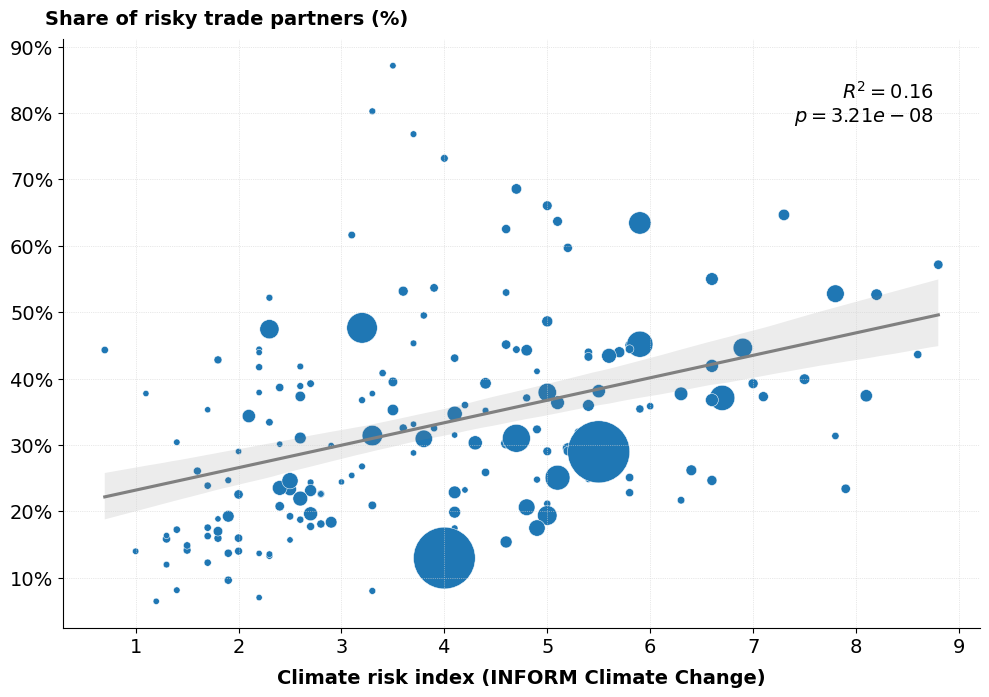

In [ ]:
result = resulting_dataframe_country_imports_fin_leontief
result = result.dropna(subset=['Local Climate Risk'])

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
import matplotlib.ticker as mticker

# Define a custom color palette (You can choose your own colors)
custom_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

color_choice='no_color'

if color_choice == 'no_correlation':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)
    
if color_choice == 'no_color':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(10, 7))
    scatter = sns.scatterplot(x='Local Climate Risk', y='Share of Risky Trade Partners (%)',
                              data=result, 
                              palette=custom_palette, 
                              size='Population', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)

if color_choice == 'Country':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              hue='Country', 
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    #plt.legend().set_visible(False)

if color_choice=='income':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Income group',  # Use 'Income group' for color coding
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_income_groups = len(result['Income group'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[:num_income_groups], labels=labels[:num_income_groups], loc='upper left', bbox_to_anchor=(1, 1))


if color_choice == 'developed/developping':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Developed?', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Developed?'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

if color_choice == 'region':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Region', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Region'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

    
# Suppress the top and right spines
#####
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# R-squared + regression
######
x = result['Local Climate Risk']
y = result['Share of Risky Trade Partners (%)']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
plt.text(0.95, 0.85, f'$R^2 = {r_squared:.2f}$\n$p = {p_value:.2e}$', transform=plt.gca().transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

# Regression
sns.regplot(x='Local Climate Risk', y='Share of Risky Trade Partners (%)', data=result, scatter=False, color='gray')  # scatter=False to avoid duplicate points


# Format (percentage, space, etc.)
######
fmt = lambda x, _: '{:.0f}%'.format(x)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
ax.set_xlabel('')  # Suppress the x-axis and y-axis titles
ax.set_ylabel('')
plt.subplots_adjust(right=0.75) # Adjust the subplot parameters to give some space for the legend
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

ax.tick_params(axis='x', labelsize=14)  # Adjust x-axis label sizes
ax.tick_params(axis='y', labelsize=14)  # Adjust y-axis label sizes

#Titles
#####
#plt.text(0, 1.17, "The Riskier a Country Is, the Riskier its Suppliers",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

#plt.text(0, 1.12, "Aggregated Inputs at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.text(0.5, -0.1, 'Climate risk index (INFORM Climate Change)', ha='center', va='bottom', transform=ax.transAxes, fontsize=14, fontweight='bold')
plt.text(-0.02, 1.05, 'Share of risky trade partners (%)', ha='left', va='top', transform=ax.transAxes, fontsize=14,fontweight='bold') 
#plt.text(0, 1.05, 'Climate-foreign dependence (%)', ha='left', va='top', transform=ax.transAxes, fontsize=12) 

plt.tight_layout()

#plt.savefig(r"Figures\Supp Mat\C\Fig3b.png")

# Show the plot
#####
plt.show()

#### XY Fig

##### Plot

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Ca

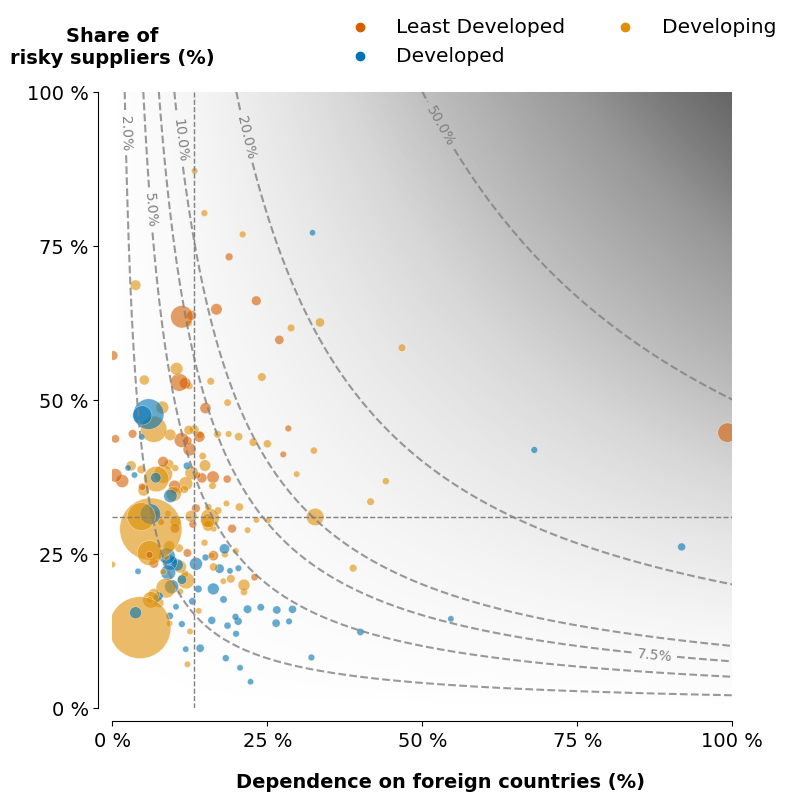

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter, MaxNLocator

result = resulting_dataframe_country_imports_fin_leontief
constants = [200, 500, 750, 1000, 2000,5000]

# Adjust the figure size as needed
plt.figure(figsize=(8, 8))


# Create a gradient background from bottom left (dark) to top right (light)
x = np.linspace(0, 10, 256)
y = np.linspace(0, 10, 256)

z = np.outer(y,x)

plt.imshow(z, aspect='auto', extent=[0, 100, 0, 100], origin='lower', cmap='Greys',alpha=0.6)

plt.ylim(0, 100)
plt.xlim(0, 100)

# Create a gradient background from bottom left (dark) to top right (light)
x = np.linspace(0, 100, 256)
y = np.linspace(0, 100, 256)
X, Y = np.meshgrid(x, y)
Z = X * Y  # Adjust this function as needed to match the background gradient

# Create contour plot
contour = plt.contour(X, Y, Z, constants, colors='grey', linestyles='dashed', alpha=0.8)

# Label each contour line with its respective value divided by 1000
fmt = lambda x: f"{x/100:.1f}%"
clabels = plt.clabel(contour, fmt=fmt, inline=True, fontsize=10, colors='black')

# Adjust label colors to make them darker than contour lines
for label in clabels:
    label.set_color('grey')

    
for const in constants:
    y_hyperbola = const / np.linspace(1, 99, 100)
    #plt.plot(np.linspace(1, 99, 100), y_hyperbola, linestyle='--', color='grey', alpha=0.3)
    # Adding text for the value of the constant
    #plt.text(104, const / 100, f'{const/10000:.0%}', verticalalignment='bottom', horizontalalignment='right', color='black')

custom_palette = ['blue', 'orange', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']
palette = sns.color_palette(palette="colorblind", as_cmap=True)
# Colorblind-friendly palette
risk_palette = {'Developed': palette[0],  # Sky Blue
                'Developing': palette[1],
               "Least Developed":palette[3]}  # Coral

color_choice = 'developed/developing'

if color_choice == 'developed/developing':
    scatter = sns.scatterplot(
        x='Foreign (%)', 
        y='Share of Risky Trade Partners (%)',
        hue='Development', 
        data=result, 
        palette=risk_palette, 
        size='Population', 
        sizes=(20, 2000),
        alpha=0.6
    )

    handles, labels = scatter.get_legend_handles_labels()
    num_developed_groups = len(result['Development'].unique())

    # Modified legend: No box and adjusted position
    plt.legend(
        handles=handles[1:num_developed_groups+1], 
        labels=labels[1:num_developed_groups+1], 
        loc='upper right',  # Change location as needed
        bbox_to_anchor=(1.1,1.15),
        frameon=False,      # Suppress the legend box
        fontsize=14.5,
        ncol=2
    )

    
# Add letters to each quadrant
#plt.text(5, 5, 'A', fontsize=20, fontweight='bold')
#plt.text(13, 95, 'B', fontsize=20, fontweight='bold')
#plt.text(95, 14, 'C', fontsize=20, fontweight='bold')
#plt.text(95, 95, 'D', fontsize=20, fontweight='bold')

median_x = result['Foreign (%)'].median()
median_y = result['Share of Risky Trade Partners (%)'].median()
plt.axvline(x=median_x, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=median_y, color='gray', linestyle='--', linewidth=1)

# Return the spines to original positions
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

scatter.set(xlabel=None, ylabel=None)
plt.text(20, -12, 'Dependence on foreign countries (%)', fontsize=14, va='center', ha='left', weight='bold')
plt.text(0, 104, 'Share of\nrisky suppliers (%)', fontsize=14, va='bottom', ha='center', weight='bold')

scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

def percentage_formatter(x, pos):
    return f'{int(x)} %'

x_formatter = FuncFormatter(percentage_formatter)
scatter.xaxis.set_major_formatter(x_formatter)
scatter.yaxis.set_major_formatter(x_formatter)

locator = MaxNLocator(nbins=4)  # Set the number of bins to control the tick frequency
scatter.xaxis.set_major_locator(locator)
scatter.yaxis.set_major_locator(locator)
# Setting the fontsize for tick labels on both axes
plt.xticks(fontsize=14)  # Adjust fontsize as needed
plt.yticks(fontsize=14)  # Adjust fontsize as needed

plt.show()

#### Quadrants Bars Fig


In [ ]:
resulting_dataframe_country_imports_fin_leontief

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%)
0,Ethiopia,ETH,6.9,High Risk,Sub-Saharan Africa,Low income,126527060.0,Least Developed,54.522209,44.635953,0,99.158161,0.841839,45.014905
1,Belarus,BLR,1.6,Low Risk,Europe & Central Asia,Upper middle income,9167767.0,Developed,66.693049,24.599701,0,91.292750,8.707250,26.945953
2,"Moldova, Republic of",MDA,2.6,Low Risk,Europe & Central Asia,Upper middle income,2464653.0,Developed,37.815365,28.421669,0,66.237034,33.762966,42.909031
3,Malta,MLT,1.5,Low Risk,Middle East & North Africa,High income,524909.0,Developed,46.136528,8.450967,0,54.587495,45.412505,15.481507
4,Hong Kong,HKG,4.0,High Risk,East Asia & Pacific,High income,7350409.0,Developing,18.414197,28.294009,0,46.708206,53.291794,60.576098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,Sudan,SUD,6.6,High Risk,Sub-Saharan Africa,Low income,48109006.0,Least Developed,0.967649,0.614733,0,1.582382,98.417618,38.848602
176,South Sudan,SDS,8.6,High Risk,Sub-Saharan Africa,Low income,11088796.0,Least Developed,0.266109,0.214720,0,0.480830,99.519170,44.656242
177,Myanmar,MMR,6.3,High Risk,East Asia & Pacific,Lower middle income,54577997.0,Least Developed,0.281291,0.179954,0,0.461245,99.538755,39.014866
178,Somalia,SOM,8.8,High Risk,Sub-Saharan Africa,Low income,18143378.0,Least Developed,0.060560,0.081483,0,0.142043,99.857957,57.364742


C:\Users\delah\AppData\Local\Temp\ipykernel_7900\3284672197.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['High Risk (relative) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
C:\Users\delah\AppData\Local\Temp\ipykernel_7900\3284672197.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'L

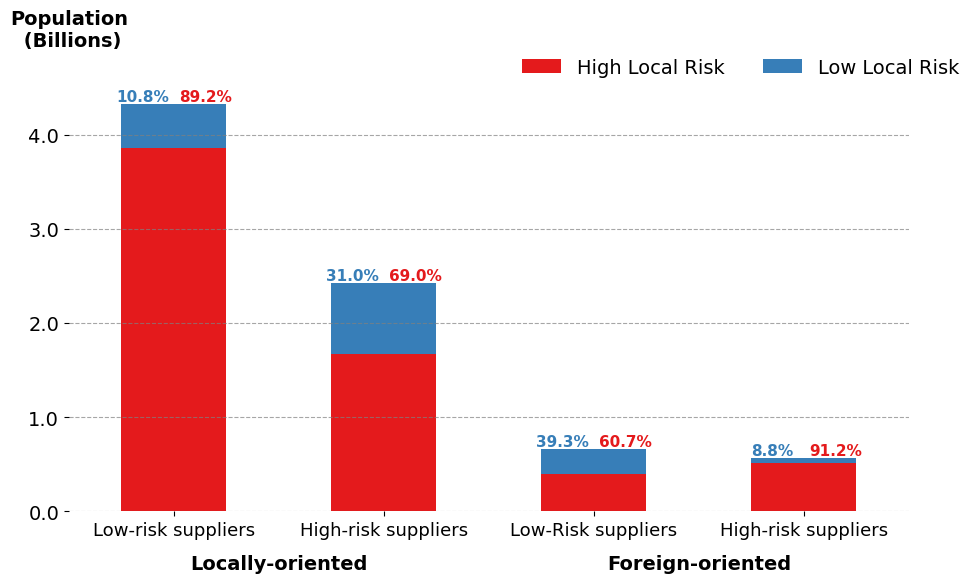

In [ ]:
df = resulting_dataframe_country_imports_fin_leontief
df = df.dropna(subset=['Local Climate Risk'])

# Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
median_high_risk_relative = df['Share of Risky Trade Partners (%)'].median()
median_foreign = df['Foreign (%)'].median()
plt.rcdefaults()
# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=11,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        
        
# Set labels and title
#plt.text(0, 1.2, "The Most Exposed Countries are all Risky Countries",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.13, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Suppress the scientific notation on the y-axis

# Customize the y-axis to show 'Billions' instead of scientific notation
def billions_formatter(x, pos):
    'The two args are the value and tick position'
    return '%1.1f' % (x * 1e-9)

ax.yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))

# Set labels, title, and other aesthetics
ax.set_xticklabels([index[1] for index in population_by_risk.index], rotation=0, fontsize=13)
plt.text(-0.5, 4.9e9, 'Population\n (Billions)', fontsize=14, va='bottom', ha='center', weight='bold')
ax.tick_params(axis='y', labelsize=14)  # Increase fontsize for y-axis tick labels

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['Low-risk suppliers', 'High-risk suppliers', 'Low-Risk suppliers', 'High-risk suppliers']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=13)

# Assuming there are four groups (you can adjust this according to your actual data)
middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

# Add the second level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.1, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,fontweight='bold')


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.1),fontsize=14, ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")
plt.tight_layout()
# Show the plot
#plt.savefig(r"Figures\Supp Mat\C\Fig2b.png")

plt.show()

In [67]:
population_by_risk

Local Risk                                             High Risk     Low Risk
Foreign (%) Category High Risk (relative) Category                           
Locally-oriented     Low-risk suppliers             3.590400e+09  612406012.0
                     High-risk suppliers            1.886574e+09  609276249.0
Foreign-oriented     Low-risk suppliers             2.068078e+08  258874822.0
                     High-risk suppliers            7.106308e+08   49535279.0

In [56]:
population_by_risk['Low Risk'].sum()

1530092362.0

## Exports interm. cons.
----

### Calculating exposure

In [ ]:
import pandas as pd

Y = mriot.Y.copy()
x = mriot.x
y = Y.sum(axis = 1)

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * country_list.size}
cExports_low = pd.DataFrame(values, index=country_list)

values = {'High Risk': [0] * country_list.size}
cExports_high = pd.DataFrame(values, index=country_list)

values = {'ROW': [0] * country_list.size}
cExports_row = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cExports = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cLocal_Use = pd.DataFrame(values, index=country_list)

for c in country_list:
    exports_c = 0
    exports_c_low = 0
    exports_c_high = 0
    exports_c_row = 0

    y_c = y[~y.index.get_level_values('region').isin([c])]
    y_c_low = y[~y.index.get_level_values('region').isin([c]) & y.index.get_level_values('region').isin(low_risk_countries)]
    y_c_high = y[~y.index.get_level_values('region').isin([c]) & y.index.get_level_values('region').isin(high_risk_countries)]
    y_c_row = y[~y.index.get_level_values('region').isin([c]) & y.index.get_level_values('region').isin(no_risk_countries)]

    x_c= x.loc[c].sum().iloc[0]

    for s in sector_list:
        L_cs = L.loc[c,s]
        
        L_cs = L_cs[L_cs.index.get_level_values('region') != c]
        L_cs_foreign_low = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(low_risk_countries)]
        L_cs_foreign_high = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(high_risk_countries)]
        L_cs_foreign_row = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(no_risk_countries)]

        exports_cs = (L_cs*y_c).sum()
        exports_cs_low = (L_cs_foreign_low*y_c_low).sum()
        exports_cs_high = (L_cs_foreign_high*y_c_high).sum()
        exports_cs_row = (L_cs_foreign_row*y_c_row).sum()

        exports_c = exports_c + exports_cs
        exports_c_low = exports_c_low + exports_cs_low
        exports_c_high = exports_c_high + exports_cs_high
        exports_c_row = exports_c_row + exports_cs_row


    cExports.loc[c] = exports_c / x_c*100
    cExports_low.loc[c] = exports_c_low / x_c*100
    cExports_high.loc[c] = exports_c_high / x_c *100
    cExports_row.loc[c] = exports_c_row / x_c *100

    
    cLocal_Use.loc[c] = 100 - cExports.loc[c].iloc[0]
    
# List of DataFrames to concatenate
dataframes_to_concat = [cExports_low, cExports_high,cExports_row, cExports, cLocal_Use]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_exports_leontief_CI = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_exports_leontief_CI.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_country_exports_interm_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_5908\1560160571.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '2.4430912088531453' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports.loc[c] = exports_c / x_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_5908\1560160571.py:61: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.6576253190041477' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_low.loc[c] = exports_c_low / x_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_5908\1560160571.py:62: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1.7717539013576953' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_high.loc[c] = exports_c_h

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/resulting_dataframe_country_exports_interm_leontief_inform_eora.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_exports_interm_leontief, f)

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/resulting_dataframe_country_exports_interm_leontief_inform_eora.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_exports_interm_leontief = pickle.load(f)

### Results

In [ ]:
df=resulting_dataframe_country_exports_interm_leontief
median_high_risk_developed_exports_inputs = df[df['Development'] == 'Developed']['High Risk Exposure (%)'].median()

median_high_risk_developed_exports_inputs

5.520262158697867

#### Correlation Fig

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\AppData\Local\Temp\ipykernel_7900\4040051774.py:38: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(x='Local Climate Risk', 

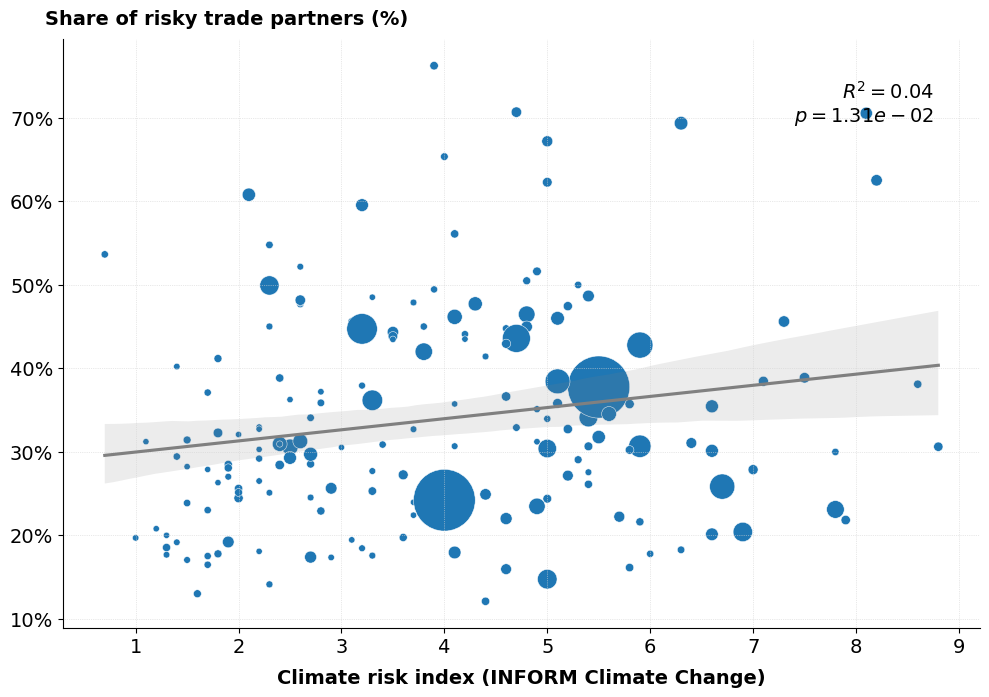

In [ ]:
result = resulting_dataframe_country_exports_interm_leontief
result = result.dropna(subset=['Local Climate Risk'])

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
import matplotlib.ticker as mticker

# Define a custom color palette (You can choose your own colors)
custom_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

color_choice='no_color'

if color_choice == 'no_correlation':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)
    
if color_choice == 'no_color':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(10, 7))
    scatter = sns.scatterplot(x='Local Climate Risk', y='Share of Risky Trade Partners (%)',
                              data=result, 
                              palette=custom_palette, 
                              size='Population', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)

if color_choice == 'Country':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              hue='Country', 
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    #plt.legend().set_visible(False)

if color_choice=='income':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Income group',  # Use 'Income group' for color coding
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_income_groups = len(result['Income group'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[:num_income_groups], labels=labels[:num_income_groups], loc='upper left', bbox_to_anchor=(1, 1))


if color_choice == 'developed/developping':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Developed?', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Developed?'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

if color_choice == 'region':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Region', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Region'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

    
# Suppress the top and right spines
#####
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# R-squared + regression
######
x = result['Local Climate Risk']
y = result['Share of Risky Trade Partners (%)']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
plt.text(0.95, 0.85, f'$R^2 = {r_squared:.2f}$\n$p = {p_value:.2e}$', transform=plt.gca().transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

# Regression
sns.regplot(x='Local Climate Risk', y='Share of Risky Trade Partners (%)', data=result, scatter=False, color='gray')  # scatter=False to avoid duplicate points


# Format (percentage, space, etc.)
######
fmt = lambda x, _: '{:.0f}%'.format(x)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
ax.set_xlabel('')  # Suppress the x-axis and y-axis titles
ax.set_ylabel('')
plt.subplots_adjust(right=0.75) # Adjust the subplot parameters to give some space for the legend
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

ax.tick_params(axis='x', labelsize=14)  # Adjust x-axis label sizes
ax.tick_params(axis='y', labelsize=14)  # Adjust y-axis label sizes

#Titles
#####
#plt.text(0, 1.17, "The Riskier a Country Is, the Riskier its Suppliers",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

#plt.text(0, 1.12, "Aggregated Inputs at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.text(0.5, -0.1, 'Climate risk index (INFORM Climate Change)', ha='center', va='bottom', transform=ax.transAxes, fontsize=14, fontweight='bold')
plt.text(-0.02, 1.05, 'Share of risky trade partners (%)', ha='left', va='top', transform=ax.transAxes, fontsize=14,fontweight='bold') 
#plt.text(0, 1.05, 'Climate-foreign dependence (%)', ha='left', va='top', transform=ax.transAxes, fontsize=12) 

plt.tight_layout()
#plt.savefig(r"Figures\Supp Mat\C\Fig3c.png") # CI
#plt.savefig(r"Figures\Supp Mat\C\Fig3d.png")  # CF

# Show the plot
#####
plt.show()

In [249]:
# Setting options to display the entire series
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.10f}'.format)
high_risk_countries=MR_list_MRIOT+HR_list_MRIOT+VHR_list_MRIOT
#Exports
a=mriot.Z.loc['COD'].sum().groupby('region').sum().sort_values(ascending=False)
#mriot.Z['COG'].T.sum().groupby('region').sum().sort_values(ascending=False)
#a=mriot.Z['COD'].T.sum().groupby('region').sum().sort_values(ascending=False)
# Convert the Series to a DataFrame and reset the index
a = a.reset_index()
a=a[a['region']!='COD']
# Rename the columns appropriately
a.columns = ['region', 'value']

risk=a[a['region'].isin(high_risk_countries)]['value'].sum()
summ = a['value'].sum()
risk/summ*100


8.866259806962299

#### XY Fig

##### Plot

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Ca

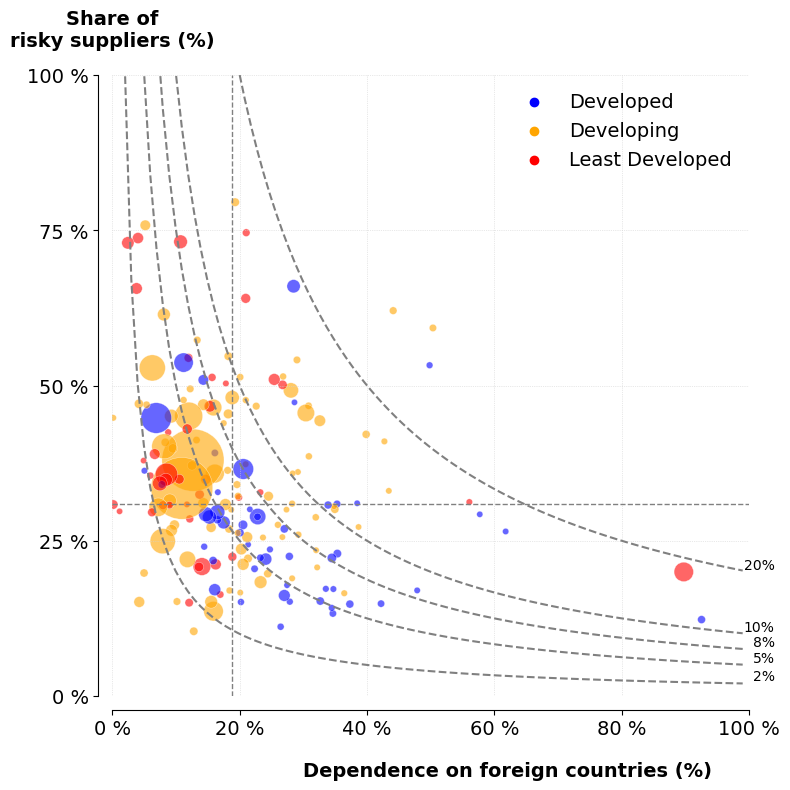

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

result = resulting_dataframe_country_exports_interm_leontief

# Adjust the figure size as needed
plt.figure(figsize=(8, 8))

plt.ylim(0, 100)
plt.xlim(0, 100)

constants = [200, 500, 750, 1000, 2000]
for const in constants:
    y_hyperbola = const / np.linspace(1, 99, 100)
    plt.plot(np.linspace(1, 99, 100), y_hyperbola, linestyle='--', color='grey', alpha=1)
    # Adding text for the value of the constant
    plt.text(104, const / 100, f'{const/10000:.0%}', verticalalignment='bottom', horizontalalignment='right', color='black')

custom_palette = ['blue', 'red', 'orange']
risk_palette = sns.color_palette("coolwarm", as_cmap=True)

color_choice = 'developed/developing'

if color_choice == 'developed/developing':
    scatter = sns.scatterplot(
        x='Foreign (%)', 
        y='High Risk (relative)',
        hue='Development', 
        data=result, 
        palette=custom_palette, 
        size='Population (2023)', 
        sizes=(20, 2000),
        alpha=0.6
    )

    num_developed_groups = len(result['Development'].unique())
    
    handles, labels = scatter.get_legend_handles_labels()
    # Example indices - replace them with actual indices from your list
    developed_index = labels.index('Developed')
    developing_index = labels.index('Developing')
    least_developed_index = labels.index('Least Developed')
    ordered_handles = [handles[developed_index], handles[developing_index], handles[least_developed_index]]
    ordered_labels = ['Developed', 'Developing', 'Least Developed']

    # Modified legend: No box and adjusted position
    plt.legend(
        handles=ordered_handles,
        labels=ordered_labels,
        loc='upper right',  # Adjust location as needed
        frameon=False,      # This removes the box around the legend
        fontsize=14
    )    


median_x = result['Foreign (%)'].median()
median_y = result['High Risk (relative)'].median()
plt.axvline(x=median_x, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=median_y, color='gray', linestyle='--', linewidth=1)

# Return the spines to original positions
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

scatter.set(xlabel=None, ylabel=None)
plt.text(30, -12, 'Dependence on foreign countries (%)', fontsize=14, va='center', ha='left', weight='bold')
plt.text(0, 104, 'Share of\nrisky suppliers (%)', fontsize=14, va='bottom', ha='center', weight='bold')

scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

def percentage_formatter(x, pos):
    return f'{int(x)} %'

x_formatter = FuncFormatter(percentage_formatter)
scatter.xaxis.set_major_formatter(x_formatter)
scatter.yaxis.set_major_formatter(x_formatter)

# Setting the fontsize for tick labels on both axes
plt.xticks(fontsize=14)  # Adjust fontsize as needed
plt.yticks(fontsize=14)  # Adjust fontsize as needed

plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
#plt.text(-0.1, 1.17, "Absolute Risk = Foreign Dependent + Risky Suppliers", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(-0.1, 1.13, "Aggregated at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.tight_layout()
#plt.savefig(r"C:\Users\delah\OneDrive\Bureau\Figures\Supp Mat\C\Fig1c.png")

plt.show()

#### Quadrants Bars Fig


C:\Users\delah\AppData\Local\Temp\ipykernel_7900\2110607695.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['High Risk (relative) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
C:\Users\delah\AppData\Local\Temp\ipykernel_7900\2110607695.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'L

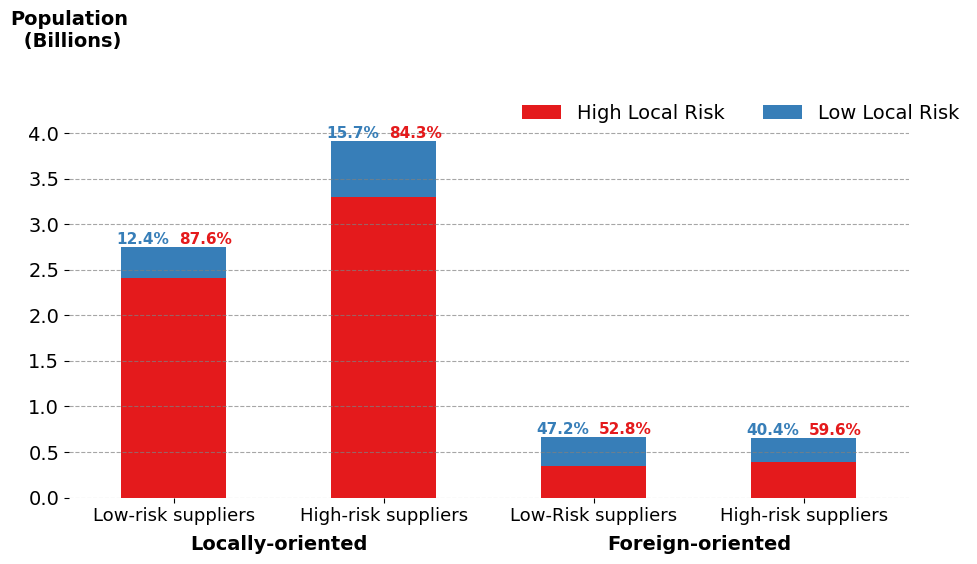

In [ ]:
df = resulting_dataframe_country_exports_interm_leontief
df = df.dropna(subset=['Local Climate Risk'])

# Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
median_high_risk_relative = df['Share of Risky Trade Partners (%)'].median()
median_foreign = df['Foreign (%)'].median()
plt.rcdefaults()
# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=11,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        
        
# Set labels and title
#plt.text(0, 1.2, "The Most Exposed Countries are all Risky Countries",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.13, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Suppress the scientific notation on the y-axis

# Customize the y-axis to show 'Billions' instead of scientific notation
def billions_formatter(x, pos):
    'The two args are the value and tick position'
    return '%1.1f' % (x * 1e-9)

ax.yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))

# Set labels, title, and other aesthetics
ax.set_xticklabels([index[1] for index in population_by_risk.index], rotation=0, fontsize=13)
plt.text(-0.5, 4.9e9, 'Population\n (Billions)', fontsize=14, va='bottom', ha='center', weight='bold')
ax.tick_params(axis='y', labelsize=14)  # Increase fontsize for y-axis tick labels

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['Low-risk suppliers', 'High-risk suppliers', 'Low-Risk suppliers', 'High-risk suppliers']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=13)

# Assuming there are four groups (you can adjust this according to your actual data)
middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

# Add the second level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.1, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,fontweight='bold')


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.1),fontsize=14, ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")
plt.tight_layout()

# Show the plot
#plt.savefig(r"Figures\Supp Mat\C\Fig2c.png")

plt.show()

In [70]:
population_by_risk

Local Risk                                             High Risk     Low Risk
Foreign (%) Category High Risk (relative) Category                           
Locally-oriented     Low-risk suppliers             7.032334e+08  370731286.0
                     High-risk suppliers            4.807941e+09  715725028.0
Foreign-oriented     Low-risk suppliers             4.380970e+08  317327426.0
                     High-risk suppliers            4.451417e+08  126308622.0

In [53]:
population_by_risk['Low Risk'].sum()

1530092362.0

## Exports fin. cons.
-----

#### Calculating exposure

In [19]:
import pandas as pd

final_production = mriot.Y.copy()

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()

multi_index = pd.MultiIndex.from_product([country_list, country_list, sector_list], names=['No risk country', 'Country', 'Sector'])

Y = mriot.Y.copy()
# Group by the first level ('region') and sum values along columns for each 'region'
final_production_by_destination = Y.groupby(level='region', axis=1).sum()

values = {'Low Risk': [0] * multi_index.size}
risk_cs_low = pd.DataFrame(values, index=multi_index)

values = {'High Risk': [0] * multi_index.size}
risk_cs_high = pd.DataFrame(values, index=multi_index)

values = {'ROW': [0] * multi_index.size}
risk_cs_row = pd.DataFrame(values, index=multi_index)

for cc in country_list:   
    country_list_except = [x for x in country_list if x != cc]
    for c in country_list_except:
        for s in sector_list:
            final_production_cs=final_production_by_destination.loc[c,s]
            final_production_cs_tot = final_production_cs.sum()
            if final_production_cs_tot>0:
                risk_cs_low.loc[cc,c,s] = final_production_cs[~final_production_cs.index.isin([cc])&final_production_cs.index.isin(low_risk_countries)].sum() / final_production_cs_tot*100
                risk_cs_high.loc[cc,c,s] = final_production_cs[~final_production_cs.index.isin([cc])&final_production_cs.index.isin(high_risk_countries)].sum() / final_production_cs_tot*100
                risk_cs_row.loc[cc,c,s] = final_production_cs[~final_production_cs.index.isin([cc])&final_production_cs.index.isin(no_risk_countries)].sum() / final_production_cs_tot*100

    # List of DataFrames to concatenate
    risk_cs = [risk_cs_low, risk_cs_high,risk_cs_row]

    # Concatenate the DataFrames along columns (axis=1)
    risk_cs = pd.concat(risk_cs,axis=1)

C:\Users\delah\AppData\Local\Temp\ipykernel_19852\140244954.py:14: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  final_production_by_destination = Y.groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_19852\140244954.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '98.37646295775615' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  risk_cs_low.loc[cc,c,s] = final_production_cs[~final_production_cs.index.isin([cc])&final_production_cs.index.isin(low_risk_countries)].sum() / final_production_cs_tot*100
C:\Users\delah\AppData\Local\Temp\ipykernel_19852\140244954.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1.5435596591422964' has dtype incompatible with int64, please explicitly cast to a compatible dtype

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/risk_cs_exports_fin_leontief_inform_eora.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(risk_cs, f)

In [ ]:
import pickle
import pandas as pd


# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/risk_cs_exports_fin_leontief_inform_eora.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    risk_cs_ = pickle.load(f)

In [ ]:
import pandas as pd

final_production_by_use = mriot.Y.copy()
y = final_production_by_use.sum(axis = 1) # final production of (c,s), whatever use

x = mriot.x # Gross output

L= mriot.L # Leontief matrix

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * country_list.size}
cExports_low = pd.DataFrame(values, index=country_list)

values = {'High Risk': [0] * country_list.size}
cExports_high = pd.DataFrame(values, index=country_list)

values = {'ROW': [0] * country_list.size}
cExports_row = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cExports = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cLocal_Use = pd.DataFrame(values, index=country_list)


for c in country_list:
    exports_c = 0
    exports_c_low = 0
    exports_c_high = 0
    exports_c_row = 0

    final_production = y
    final_production_and_risk_c_low = y*risk_cs.loc[c]['Low Risk']/100
    final_production_and_risk_c_high = y*risk_cs.loc[c]['High Risk']/100
    final_production_and_risk_c_row = y*risk_cs.loc[c]['ROW']/100

    for s in sector_list:
        L_cs = L.loc[c,s]
        
        exports_cs= (L_cs*final_production).sum()
        exports_cs_low = (L_cs*final_production_and_risk_c_low).sum()
        exports_cs_high = (L_cs*final_production_and_risk_c_high).sum()
        exports_cs_row = (L_cs*final_production_and_risk_c_row).sum()

        exports_c = exports_c + exports_cs
        exports_c_low = exports_c_low + exports_cs_low  
        exports_c_high = exports_c_high + exports_cs_high  
        exports_c_row = exports_c_row + exports_cs_row 


    x_c = x.loc[c].sum().iloc[0]

    cExports_low.loc[c] = exports_c_low / x_c*100
    cExports_high.loc[c] = exports_c_high / x_c *100
    cExports_row.loc[c] = exports_c_row / x_c *100
    
    cExports.loc[c] = cExports_low.loc[c].iloc[0]+cExports_high.loc[c].iloc[0]+cExports_row.loc[c].iloc[0]

    cLocal_Use.loc[c] = 100 - cExports_low.loc[c].iloc[0]- cExports_high.loc[c].iloc[0]- cExports_row.loc[c].iloc[0]
    
# List of DataFrames to concatenate
dataframes_to_concat = [cExports_low, cExports_high,cExports_row,cExports, cLocal_Use]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_exports_leontief_CF = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_exports_leontief_CF.sort_values('Foreign (%)', ascending=False).reset_index()


# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100

result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_country_exports_fin_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_19852\4140843009.py:57: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.7163580654207217' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_low.loc[c] = exports_c_low / x_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_19852\4140843009.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1.7167671149871844' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_high.loc[c] = exports_c_high / x_c *100
C:\Users\delah\AppData\Local\Temp\ipykernel_19852\4140843009.py:59: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.012068822778726998' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_row.loc[c

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/resulting_dataframe_country_exports_fin_leontief_inform_eora.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_exports_fin_leontief, f)

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/resulting_dataframe_country_exports_fin_leontief_inform_eora.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_exports_fin_leontief = pickle.load(f)

### Results

#### Correlation Fig

In [ ]:
result = resulting_dataframe_country_exports_fin_leontief
result = result.dropna(subset=['Local Climate Risk'])


import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
import matplotlib.ticker as mticker

# Define a custom color palette (You can choose your own colors)
custom_palette = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

color_choice='no_color'

if color_choice == 'no_correlation':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)
    
if color_choice == 'no_color':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(10, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    plt.legend().set_visible(False)

if color_choice == 'Country':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                              hue='Country', 
                              data=result, 
                              palette=custom_palette, 
                              size='Population (2023)', 
                              sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Identify number of unique regions to include in the legend
    num_regions = len(result['Country'].unique())

    # Create new legend with only the first `num_regions` handles
    plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
    #plt.legend().set_visible(False)

if color_choice=='income':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Income group',  # Use 'Income group' for color coding
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_income_groups = len(result['Income group'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[:num_income_groups], labels=labels[:num_income_groups], loc='upper left', bbox_to_anchor=(1, 1))


if color_choice == 'developed/developping':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Developed?', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Developed?'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

if color_choice == 'region':
    # Create a scatter plot with the custom color palette
    plt.figure(figsize=(15, 7))
    scatter = sns.scatterplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)',
                          hue='Region', 
                          data=result, 
                          palette=custom_palette, 
                          size='Population (2023)', 
                          sizes=(20, 2000))

    # Extract handles and labels
    handles, labels = scatter.get_legend_handles_labels()
    
    # Identify number of unique income groups to include in the legend
    num_developed_groups = len(result['Region'].unique())

    # Create new legend with only the first `num_income_groups` handles
    plt.legend(handles=handles[1:num_developed_groups+1], labels=labels[1:num_developed_groups+1], loc='upper left', bbox_to_anchor=(1, 1),fontsize=14)

    
# Suppress the top and right spines
#####
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# R-squared + regression
######
x = result['Index 2050 (RCP8.5)']
y = result['High Risk (relative)']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
plt.text(0.95, 0.85, f'$R^2 = {r_squared:.2f}$\n$p = {p_value:.2e}$', transform=plt.gca().transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

# Regression
sns.regplot(x='Index 2050 (RCP8.5)', y='High Risk (relative)', data=result, scatter=False, color='gray')  # scatter=False to avoid duplicate points


# Format (percentage, space, etc.)
######
fmt = lambda x, _: '{:.0f}%'.format(x)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
ax.set_xlabel('')  # Suppress the x-axis and y-axis titles
ax.set_ylabel('')
plt.subplots_adjust(right=0.75) # Adjust the subplot parameters to give some space for the legend
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

ax.tick_params(axis='x', labelsize=14)  # Adjust x-axis label sizes
ax.tick_params(axis='y', labelsize=14)  # Adjust y-axis label sizes

#Titles
#####
#plt.text(0, 1.17, "The Riskier a Country Is, the Riskier its Suppliers",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

#plt.text(0, 1.12, "Aggregated Inputs at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.text(0.5, -0.1, 'Climate risk index (INFORM Climate Change)', ha='center', va='bottom', transform=ax.transAxes, fontsize=14, fontweight='bold')
plt.text(-0.02, 1.05, 'Share of risky suppliers (%)', ha='left', va='top', transform=ax.transAxes, fontsize=14,fontweight='bold') 
#plt.text(0, 1.05, 'Climate-foreign dependence (%)', ha='left', va='top', transform=ax.transAxes, fontsize=12) 

plt.tight_layout()
#plt.savefig(r"Figures\Supp Mat\C\Fig3d.png")

# Show the plot
#####
plt.show()

ValueError: Could not interpret value `Index 2050 (RCP8.5)` for parameter `x`

<Figure size 1000x700 with 0 Axes>

#### XY Fig

##### Plot

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Ca

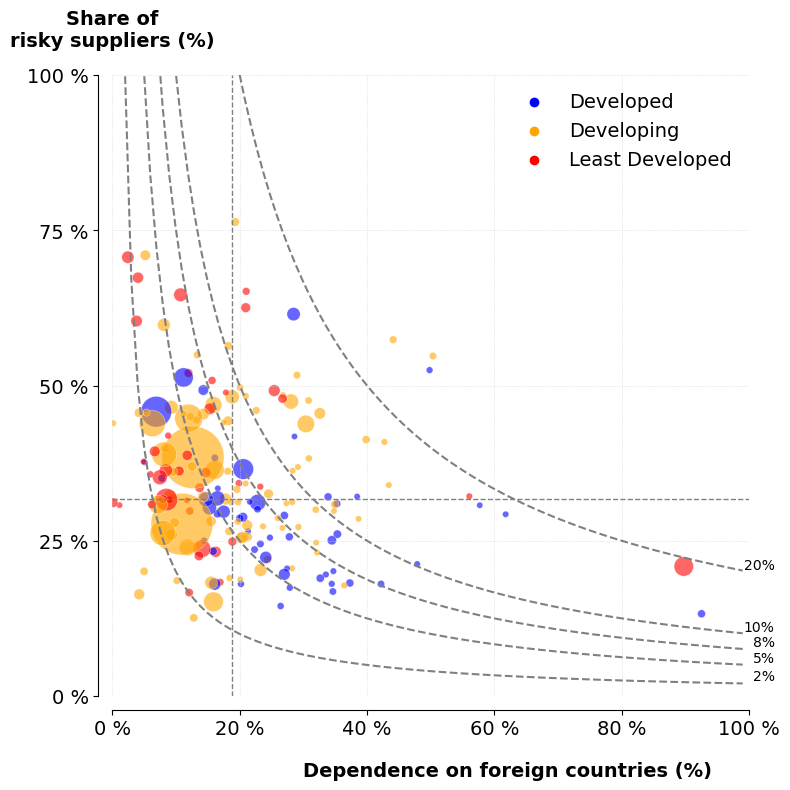

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

result = resulting_dataframe_country_exports_fin_leontief

# Adjust the figure size as needed
plt.figure(figsize=(8, 8))

plt.ylim(0, 100)
plt.xlim(0, 100)

constants = [200, 500, 750, 1000, 2000]
for const in constants:
    y_hyperbola = const / np.linspace(1, 99, 100)
    plt.plot(np.linspace(1, 99, 100), y_hyperbola, linestyle='--', color='grey', alpha=1)
    # Adding text for the value of the constant
    plt.text(104, const / 100, f'{const/10000:.0%}', verticalalignment='bottom', horizontalalignment='right', color='black')

custom_palette = ['blue', 'red', 'orange']
risk_palette = sns.color_palette("coolwarm", as_cmap=True)

color_choice = 'developed/developing'

if color_choice == 'developed/developing':
    scatter = sns.scatterplot(
        x='Foreign (%)', 
        y='High Risk (relative)',
        hue='Development', 
        data=result, 
        palette=custom_palette, 
        size='Population (2023)', 
        sizes=(20, 2000),
        alpha=0.6
    )

    num_developed_groups = len(result['Development'].unique())
    
    handles, labels = scatter.get_legend_handles_labels()
    # Example indices - replace them with actual indices from your list
    developed_index = labels.index('Developed')
    developing_index = labels.index('Developing')
    least_developed_index = labels.index('Least Developed')
    ordered_handles = [handles[developed_index], handles[developing_index], handles[least_developed_index]]
    ordered_labels = ['Developed', 'Developing', 'Least Developed']

    # Modified legend: No box and adjusted position
    plt.legend(
        handles=ordered_handles,
        labels=ordered_labels,
        loc='upper right',  # Adjust location as needed
        frameon=False,      # This removes the box around the legend
        fontsize=14
    )    


median_x = result['Foreign (%)'].median()
median_y = result['High Risk (relative)'].median()
plt.axvline(x=median_x, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=median_y, color='gray', linestyle='--', linewidth=1)

# Return the spines to original positions
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

scatter.set(xlabel=None, ylabel=None)
plt.text(30, -12, 'Dependence on foreign countries (%)', fontsize=14, va='center', ha='left', weight='bold')
plt.text(0, 104, 'Share of\nrisky suppliers (%)', fontsize=14, va='bottom', ha='center', weight='bold')

scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

def percentage_formatter(x, pos):
    return f'{int(x)} %'

x_formatter = FuncFormatter(percentage_formatter)
scatter.xaxis.set_major_formatter(x_formatter)
scatter.yaxis.set_major_formatter(x_formatter)

# Setting the fontsize for tick labels on both axes
plt.xticks(fontsize=14)  # Adjust fontsize as needed
plt.yticks(fontsize=14)  # Adjust fontsize as needed

plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
#plt.text(-0.1, 1.17, "Absolute Risk = Foreign Dependent + Risky Suppliers", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(-0.1, 1.13, "Aggregated at the Country Level - Total Exposure (EORA)", transform=ax.transAxes, fontsize=14, va='top', ha='left')
plt.tight_layout()
#plt.savefig(r"Figures\Supp Mat\C\Fig1c.png")

plt.show()

#### Quadrants Bars Fig


C:\Users\delah\AppData\Local\Temp\ipykernel_7900\3191917876.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['High Risk (relative) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
C:\Users\delah\AppData\Local\Temp\ipykernel_7900\3191917876.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'L

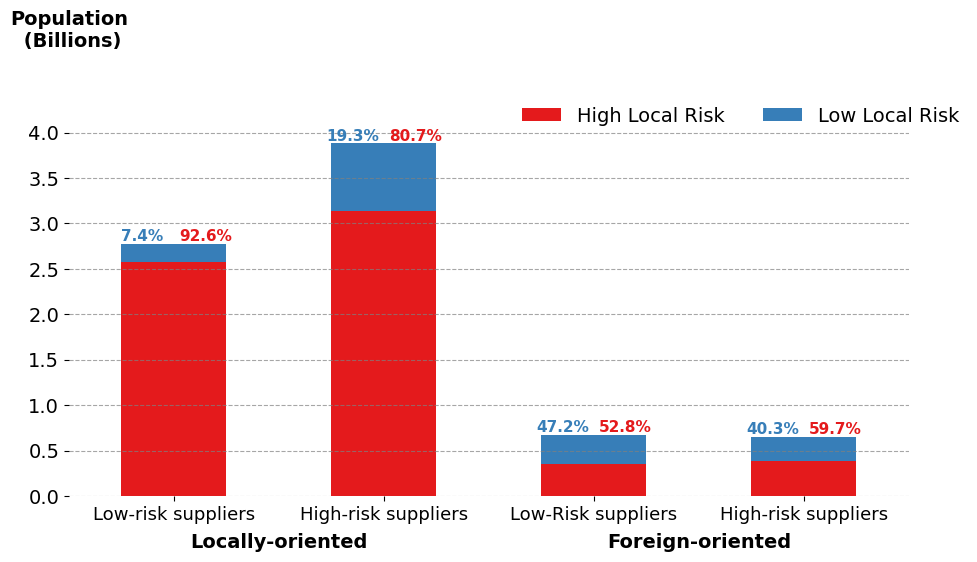

In [ ]:
df = resulting_dataframe_country_exports_fin_leontief
df = df.dropna(subset=['Local Climate Risk'])

# Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
median_high_risk_relative = df['Share of Risky Trade Partners (%)'].median()
median_foreign = df['Foreign (%)'].median()
plt.rcdefaults()
# Add columns to indicate if each row is over or under the median for the specified columns
df['High Risk (relative) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=11,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        
        
# Set labels and title
#plt.text(0, 1.2, "The Most Exposed Countries are all Risky Countries",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.13, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Suppress the scientific notation on the y-axis

# Customize the y-axis to show 'Billions' instead of scientific notation
def billions_formatter(x, pos):
    'The two args are the value and tick position'
    return '%1.1f' % (x * 1e-9)

ax.yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))

# Set labels, title, and other aesthetics
ax.set_xticklabels([index[1] for index in population_by_risk.index], rotation=0, fontsize=13)
plt.text(-0.5, 4.9e9, 'Population\n (Billions)', fontsize=14, va='bottom', ha='center', weight='bold')
ax.tick_params(axis='y', labelsize=14)  # Increase fontsize for y-axis tick labels

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['Low-risk suppliers', 'High-risk suppliers', 'Low-Risk suppliers', 'High-risk suppliers']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=13)

# Assuming there are four groups (you can adjust this according to your actual data)
middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

# Add the second level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.1, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,fontweight='bold')


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.1),fontsize=14, ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")
plt.tight_layout()

# Show the plot
#plt.savefig(r"Figures\Supp Mat\C\Fig2d.png")

plt.show()

## Plot all figures

Imports all dataframes

In [24]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/resulting_dataframe_country_imports_interm_leontief_inform_eora.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_imports_interm_leontief = pickle.load(f)

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/resulting_dataframe_country_imports_fin_leontief_inform_eora.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_imports_fin_leontief = pickle.load(f)

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/resulting_dataframe_country_exports_interm_leontief_inform_eora.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_exports_interm_leontief = pickle.load(f)

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/resulting_dataframe_country_exports_fin_leontief_inform_eora.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_exports_fin_leontief = pickle.load(f)

### Distributions

### Correlation Fig

In [29]:
dataframes = {
  'a': resulting_dataframe_country_imports_interm_leontief,
  'b': resulting_dataframe_country_imports_fin_leontief,
  'c': resulting_dataframe_country_exports_interm_leontief,
  'd': resulting_dataframe_country_exports_fin_leontief
}

for suffix, df in dataframes.items():
  result = df.dropna(subset=['Local Climate Risk'])

  plt.figure(figsize=(10, 7))
  scatter = sns.scatterplot(x='Local Climate Risk', y='Share of Risky Trade Partners (%)',
                              data=result, 
                              palette=custom_palette, 
                              size='Population', 
                              sizes=(20, 2000))

  # Extract handles and labels
  handles, labels = scatter.get_legend_handles_labels()

  # Identify number of unique regions to include in the legend
  num_regions = len(result['Country'].unique())

  # Create new legend with only the first `num_regions` handles
  plt.legend(handles=handles[:num_regions], labels=labels[:num_regions], loc='upper left', bbox_to_anchor=(1, 1))
  plt.legend().set_visible(False)

  # Suppress the top and right spines
  #####
  ax = plt.gca()  # Get the current Axes instance
  ax.spines['right'].set_visible(False)
  ax.spines['top'].set_visible(False)

  # R-squared + regression
  ######
  x = result['Local Climate Risk']
  y = result['Share of Risky Trade Partners (%)']
  slope, intercept, r_value, p_value, std_err = linregress(x, y)
  r_squared = r_value**2
  plt.text(0.95, 0.85, f'$R^2 = {r_squared:.2f}$\n$p = {p_value:.2e}$', transform=plt.gca().transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='right')

  # Regression
  sns.regplot(x='Local Climate Risk', y='Share of Risky Trade Partners (%)', data=result, scatter=False, color='gray')  # scatter=False to avoid duplicate points


  # Format (percentage, space, etc.)
  ######
  fmt = lambda x, _: '{:.0f}%'.format(x)
  plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
  ax.set_xlabel('')  # Suppress the x-axis and y-axis titles
  ax.set_ylabel('')
  plt.subplots_adjust(right=0.75) # Adjust the subplot parameters to give some space for the legend
  plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

  ax.tick_params(axis='x', labelsize=14)  # Adjust x-axis label sizes
  ax.tick_params(axis='y', labelsize=14)  # Adjust y-axis label sizes

  #Titles
  #####
  plt.text(0.5, -0.1, 'Climate risk index (INFORM Climate Change)', ha='center', va='bottom', transform=ax.transAxes, fontsize=14, fontweight='bold')
  plt.text(-0.02, 1.05, 'Share of risky trade partners (%)', ha='left', va='top', transform=ax.transAxes, fontsize=14,fontweight='bold') 

  plt.tight_layout()
  plt.savefig(f"Figures/Test/Fig1{suffix}.png")
  plt.close()


c:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\AppData\Local\Temp\ipykernel_32660\981356070.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(x='Local Climate Risk', 

### XY Fig

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter, MaxNLocator

dataframes = {
  'a': resulting_dataframe_country_imports_interm_leontief,
  'b': resulting_dataframe_country_imports_fin_leontief,
  'c': resulting_dataframe_country_exports_interm_leontief,
  'd': resulting_dataframe_country_exports_fin_leontief
}

for suffix, df in dataframes.items():
  result = df.dropna(subset=['Local Climate Risk'])
  constants = [200, 500, 750, 1000, 2000,5000]

  # Adjust the figure size as needed
  plt.figure(figsize=(8, 8))


  # Create a gradient background from bottom left (dark) to top right (light)
  x = np.linspace(0, 10, 256)
  y = np.linspace(0, 10, 256)

  z = np.outer(y,x)

  plt.imshow(z, aspect='auto', extent=[0, 100, 0, 100], origin='lower', cmap='Greys',alpha=0.6)

  plt.ylim(0, 100)
  plt.xlim(0, 100)

  # Create a gradient background from bottom left (dark) to top right (light)
  x = np.linspace(0, 100, 256)
  y = np.linspace(0, 100, 256)
  X, Y = np.meshgrid(x, y)
  Z = X * Y  # Adjust this function as needed to match the background gradient

  # Create contour plot
  contour = plt.contour(X, Y, Z, constants, colors='grey', linestyles='dashed', alpha=0.8)

  # Label each contour line with its respective value divided by 1000
  fmt = lambda x: f"{x/100:.1f}%"
  clabels = plt.clabel(contour, fmt=fmt, inline=True, fontsize=10, colors='black')

  # Adjust label colors to make them darker than contour lines
  for label in clabels:
      label.set_color('grey')

      
  for const in constants:
      y_hyperbola = const / np.linspace(1, 99, 100)

  custom_palette = ['blue', 'orange', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']
  palette = sns.color_palette(palette="colorblind", as_cmap=True)
  # Colorblind-friendly palette
  risk_palette = {'Developed': palette[0],  # Sky Blue
                  'Developing': palette[1],
                "Least Developed":palette[3]}  # Coral

  color_choice = 'developed/developing'

  if color_choice == 'developed/developing':
      scatter = sns.scatterplot(
          x='Foreign (%)', 
          y='Share of Risky Trade Partners (%)',
          hue='Development', 
          data=result, 
          palette=risk_palette, 
          size='Population', 
          sizes=(20, 2000),
          alpha=0.6
      )

      handles, labels = scatter.get_legend_handles_labels()
      num_developed_groups = len(result['Development'].unique())

      # Modified legend: No box and adjusted position
      plt.legend(
          handles=handles[1:num_developed_groups+1], 
          labels=labels[1:num_developed_groups+1], 
          loc='upper right',  # Change location as needed
          bbox_to_anchor=(1.1,1.15),
          frameon=False,      # Suppress the legend box
          fontsize=14.5,
          ncol=2
      )

  median_x = result['Foreign (%)'].median()
  median_y = result['Share of Risky Trade Partners (%)'].median()
  plt.axvline(x=median_x, color='gray', linestyle='--', linewidth=1)
  plt.axhline(y=median_y, color='gray', linestyle='--', linewidth=1)

  # Return the spines to original positions
  ax = plt.gca()
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  ax.spines['left'].set_position(('outward', 10))
  ax.spines['bottom'].set_position(('outward', 10))

  scatter.set(xlabel=None, ylabel=None)
  plt.text(20, -12, 'Dependence on foreign countries (%)', fontsize=14, va='center', ha='left', weight='bold')
  plt.text(0, 104, 'Share of\nrisky suppliers (%)', fontsize=14, va='bottom', ha='center', weight='bold')

  scatter.yaxis.set_major_locator(plt.MaxNLocator(4))

  def percentage_formatter(x, pos):
      return f'{int(x)} %'

  x_formatter = FuncFormatter(percentage_formatter)
  scatter.xaxis.set_major_formatter(x_formatter)
  scatter.yaxis.set_major_formatter(x_formatter)

  locator = MaxNLocator(nbins=4)  # Set the number of bins to control the tick frequency
  scatter.xaxis.set_major_locator(locator)
  scatter.yaxis.set_major_locator(locator)
  
  # Setting the fontsize for tick labels on both axes
  plt.xticks(fontsize=14)  # Adjust fontsize as needed
  plt.yticks(fontsize=14)  # Adjust fontsize as needed

  plt.tight_layout()

  plt.savefig(f"Figures/Test/Fig2{suffix}.png")
  plt.close()


c:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Ca

### Quadrant Bars Fig

In [31]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

dataframes = {
  'a': resulting_dataframe_country_imports_interm_leontief,
  'b': resulting_dataframe_country_imports_fin_leontief,
  'c': resulting_dataframe_country_exports_interm_leontief,
  'd': resulting_dataframe_country_exports_fin_leontief
}

for suffix, df in dataframes.items():

    df = df.dropna(subset=['Local Climate Risk'])

    # Calculate the median values for 'High Risk (relative)' and 'Foreign (%)'
    median_high_risk_relative = df['Share of Risky Trade Partners (%)'].median()
    median_foreign = df['Foreign (%)'].median()

    # Add columns to indicate if each row is over or under the median for the specified columns
    df['High Risk (relative) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
    df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')


    # Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'High Risk (relative) Category'
    df_sorted = df.sort_values(by=['Foreign (%) Category', 'High Risk (relative) Category'], ascending=[False, False])

    # Group the sorted data
    grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'High Risk (relative) Category', 'Local Risk'])['Population'].sum()

    # Unstack the 'Local Risk' level to prepare for a stacked bar chart
    population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

    # Define the custom order
    custom_order = [
        ('Locally-oriented', 'Low-risk suppliers'),
        ('Locally-oriented', 'High-risk suppliers'),
        ('Foreign-oriented', 'Low-risk suppliers'),
        ('Foreign-oriented', 'High-risk suppliers'),
        ]

    # Reorder the DataFrame according to the custom order
    population_by_risk = population_by_risk.loc[custom_order]

    # Define a color code for each 'Local Risk'
    colorpalette = sns.color_palette("Set1", 7)
    colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
        
    # Create a stacked bar plot with custom colors
    fig, ax = plt.subplots(figsize=(10, 6))
    population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


    # Iterate through the bars (x positions) to calculate and annotate percentages
    for i, (index, row) in enumerate(population_by_risk.iterrows()):
        total = row.sum()
        # Starting y position for the text - top of each bar
        y_offset = total

        # Horizontal offset to separate the text annotations
        horizontal_offset = -0.15

        for color in colors:
            # Calculate percentage
            percentage = (row[color] / total) * 100 if total != 0 else 0
            # X position of the bar with an offset, Y position for the text is at the top of the bar
            x = i + horizontal_offset
            # Add text annotation
            ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=11,fontweight='bold')
            # Update horizontal offset for next text
            horizontal_offset += 0.3
            
            
    # Suppress the scientific notation on the y-axis

    # Customize the y-axis to show 'Billions' instead of scientific notation
    def billions_formatter(x, pos):
        'The two args are the value and tick position'
        return '%1.1f' % (x * 1e-9)

    ax.yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))

    # Set labels, title, and other aesthetics
    ax.set_xticklabels([index[1] for index in population_by_risk.index], rotation=0, fontsize=13)
    plt.text(-0.5, 4.3e9, 'Population\n (Billions)', fontsize=14, va='bottom', ha='center', weight='bold')
    ax.tick_params(axis='y', labelsize=14)  # Increase fontsize for y-axis tick labels

    ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

    # Suppress the frame by setting the visibility of the spines to False
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    first_level_labels = ['A', 'B', 'C', 'D']
    ax.set_xticklabels(first_level_labels, rotation=0, fontsize=13,fontweight='bold')

    second_level_labels = ['Low-risk suppliers', 'High-risk suppliers', 'Low-Risk suppliers', 'High-risk suppliers']

    # Assuming there are four groups (you can adjust this according to your actual data)
    four_positions = [i for i in range(len(population_by_risk.index))]

    middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
    group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

    # Add the third level of labels
    for pos, label in zip(middle_positions, group_labels):
        ax.text(pos, -0.14, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,fontweight='bold')
        
    # Add the second level of labels
    for pos, label in zip(four_positions, second_level_labels):
        ax.text(pos, -0.07, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=14,)


    # Get handles and labels from the existing legend
    handles, labels = ax.get_legend_handles_labels()

    # Replace legend labels
    new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

    # Create new legend with updated labels
    legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.1),fontsize=14, ncol=2, frameon=False)

    ax.set_xlabel("")
    plt.tight_layout()
    plt.savefig(f"Figures/Test/Fig3{suffix}.png")
    plt.close()


C:\Users\delah\AppData\Local\Temp\ipykernel_32660\3224969632.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['High Risk (relative) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_relative else 'Low-risk suppliers')
C:\Users\delah\AppData\Local\Temp\ipykernel_32660\3224969632.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else

# Sector-level analysis
-----

## Imports interm. cons.
----

### Calculating exposure

By product

Backward exposure of the whole economy of c on good s as intermediary consumption

In [ ]:
import pandas as pd    

Y = mriot.Y.copy()
x = mriot.x
y = Y.sum(axis = 1)

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()

index_cs = mriot.x.index

values = {'Low Risk': [0] * index_cs.size}
Foreign_Inputs_low = pd.DataFrame(values, index=index_cs)

values = {'High Risk': [0] * index_cs.size}
Foreign_Inputs_high = pd.DataFrame(values, index=index_cs)

values = {'ROW': [0] * index_cs.size}
Foreign_Inputs_ROW = pd.DataFrame(values, index=index_cs)

values = {'Local (%)': [0] * index_cs.size}
Local_Inputs = pd.DataFrame(values, index=index_cs)

values = {'Foreign (%)': [0] * index_cs.size}
Foreign_Inputs = pd.DataFrame(values, index=index_cs)


for s in sector_list:    
    for c in country_list:
        L_c = L[c]
        y_c = y[c]
        
        inputs_cs = L_c.groupby('sector').sum().loc[s].dot(y_c)  # products s used as inputs for all sectors of c's economy
        
        if (inputs_cs != 0) & (y_c[s]>0) :
            Foreign_Inputs.loc[c,s]= L_c.loc[~L_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
            Local_Inputs.loc[c,s] = L_c.loc[L_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
            Foreign_Inputs_low.loc[c,s] =  L_c.loc[~L_c.index.get_level_values('region').isin([c]) & L_c.index.get_level_values('region').isin(low_risk_countries)].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
            Foreign_Inputs_high.loc[c,s] = L_c.loc[~L_c.index.get_level_values('region').isin([c]) & L_c.index.get_level_values('region').isin(high_risk_countries)].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
            Foreign_Inputs_ROW.loc[c,s] = L_c.loc[~L_c.index.get_level_values('region').isin([c]) & L_c.index.get_level_values('region').isin(no_risk_countries)].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100

# List of DataFrames to concatenate
dataframes_to_concat = [Foreign_Inputs_low, Foreign_Inputs_high, Foreign_Inputs_ROW,Foreign_Inputs, Local_Inputs]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_sectors_inputs_leontief = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_sectors_inputs_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development','sector', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_sectors_imports_interm_product_leontief=result

C:\Users\delah\AppData\Local\Temp\ipykernel_32660\802112358.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '8.340121101129828' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Foreign_Inputs.loc[c,s]= L_c.loc[~L_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
C:\Users\delah\AppData\Local\Temp\ipykernel_32660\802112358.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '91.65987889887018' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Local_Inputs.loc[c,s] = L_c.loc[L_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
C:\Users\delah\AppData\Local\Temp\ipykernel_32660\802112358.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will r

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Sector/resulting_dataframe_sectors_imports_interm_product_leontief_inform_eora.pkl'

# Save the dictionary to a file
with open(file_path_pickle, 'wb') as f:
#    pickle.dump(resulting_dataframe_sectors_imports_interm_product_leontief, f)

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Sector/resulting_dataframe_sectors_imports_interm_product_leontief_inform_eora.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_sectors_imports_interm_product_leontief = pickle.load(f)

### Plot

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


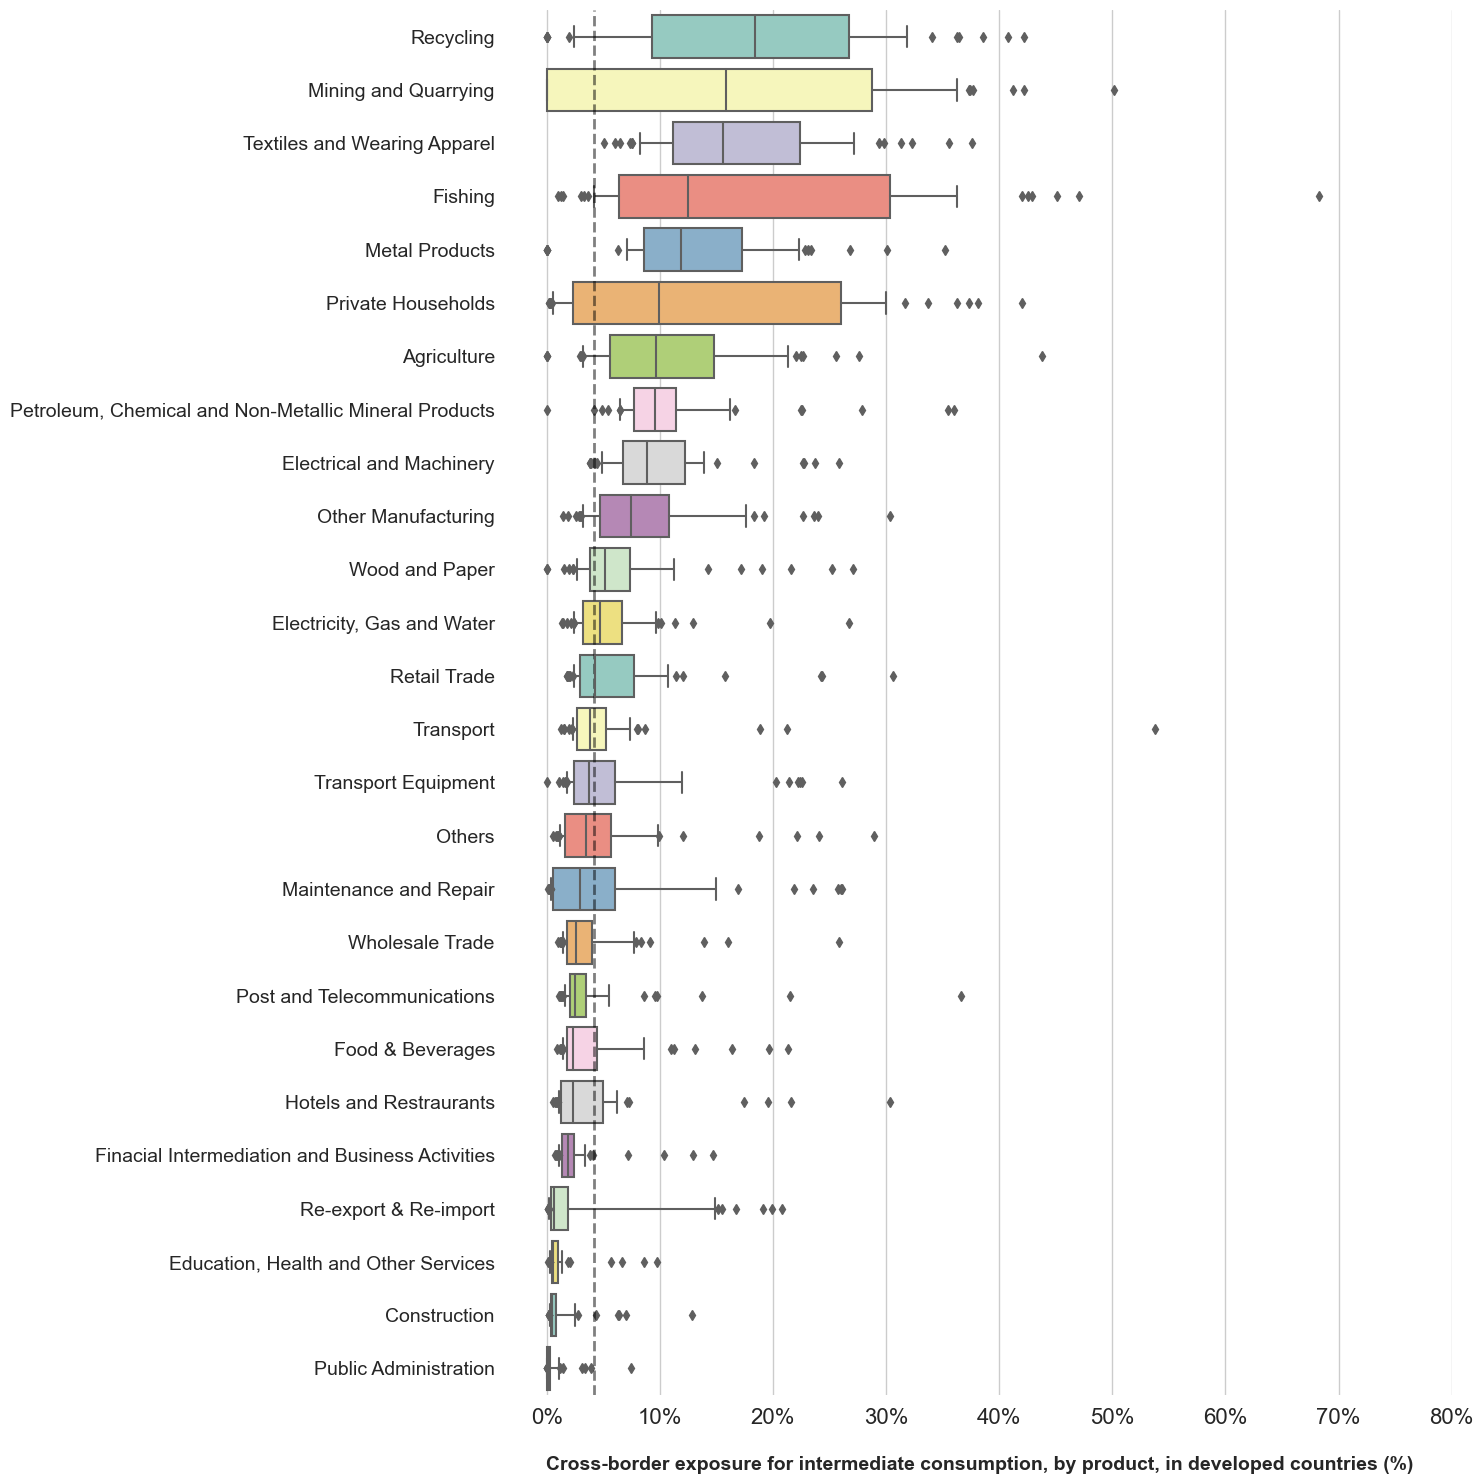

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming your dataframe is loaded as df
df = resulting_dataframe_sectors_imports_interm_product_leontief

# Split the data
df_developed = df[df['Development'] == 'Developed']

# Calculate the IQR and determine outliers manually
Q1 = df_developed['High Risk Exposure (%)'].quantile(0.25)
Q3 = df_developed['High Risk Exposure (%)'].quantile(0.75)
IQR = Q3 - Q1
#outliers = df_developed[(df_developed['High Risk Exposure (%)'] < (Q1 - 1.5 * IQR)) | (df_developed['High Risk Exposure (%)'] > (Q3 + 1.5 * IQR))]

#print("Number of outliers:", len(outliers))
#print("Outlier values:", outliers['High Risk Exposure (%)'].tolist())

# Calculate the median 'High Risk' for each sector in developed countries
sector_medians_developed = df_developed.groupby('sector')['High Risk Exposure (%)'].median()
sector_medians_developed = sector_medians_developed.sort_values(ascending=False)

# Set the threshold for median
threshold = 0  # Adjust this threshold as needed

# Filter sectors based on the threshold
selected_sectors = sector_medians_developed[sector_medians_developed > threshold].index
# Sort the sectors by these medians in descending order
sorted_sectors = sector_medians_developed.sort_values(ascending=False).index

# Set the style for the plots
sns.set(style="whitegrid")

# Create a figure and axes
fig, ax = plt.subplots(figsize=(15, 15))

# Create the boxplot with horizontal orientation for selected sectors
sns.boxplot(y='sector', x='High Risk Exposure (%)', data=df_developed[df_developed['sector'].isin(selected_sectors)], ax=ax,
            order=selected_sectors, orient='h', palette="Set3",whis=[10, 90])


# Annotations and aesthetics
ax.axvline(x=median_high_risk_developed_inputs, color='black', linestyle='--', linewidth=2, alpha=0.5)

# Suppress the y-axis label
ax.set_ylabel('')

# Suppress the frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Customize x-axis
x_ticks = np.linspace(0, 80, 9)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f'{x:.0f}%' for x in x_ticks], fontsize=16)

# Customize y-axis
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)

# Set x-axis label
ax.set_xlabel('Cross-border exposure for intermediate consumption, by product, in developed countries (%)', fontsize=14, fontweight='bold', labelpad=20)

plt.tight_layout()
#plt.savefig(r"Figures\Supp Mat\D\Fig2b.png")
#plt.savefig(r"Figures\Supp Mat\D\Fig4b.png")

plt.show()

### At least one product in every country

In [61]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/resulting_dataframe_sectors_inputs_leontief_eora_inform.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_sectors_inputs_leontief = pickle.load(f)

df=resulting_dataframe_sectors_inputs_leontief

In [66]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/resulting_dataframe_sectors_exports_CI_leontief_eora_inform.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_sectors_exports_leontief_CI = pickle.load(f)
    
df =resulting_dataframe_sectors_exports_leontief_CI

In [67]:
import pandas as pd

# Assuming your data is in a pandas DataFrame called df

# Convert "High Risk Exposure (%)" to numeric, if not already
df['High Risk Exposure (%)'] = pd.to_numeric(df['High Risk Exposure (%)'], errors='coerce')

# Group by 'Country' and get the row with the maximum "High Risk Exposure (%)" for each country
max_high_risk_exposure = df.loc[df.groupby('Country')['High Risk Exposure (%)'].idxmax()]
df2=max_high_risk_exposure.sort_values(by='High Risk Exposure (%)',ascending=False)
#df2=df2[['Country','Country Code','High Risk Exposure (%)']]
df2

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,sector,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%)
145,Lao People's Democratic Republic,LAO,4.0,High Risk,East Asia & Pacific,Lower middle income,7633779.0,Least Developed,Wood and Paper,11.052272,76.356552,0.503653,87.912477,12.087523,87.355657
72,Zambia,ZMB,5.0,High Risk,Sub-Saharan Africa,Lower middle income,20569737.0,Least Developed,Mining and Quarrying,14.404358,75.769917,0.835640,91.009915,8.990085,84.026089
36,Myanmar,MMR,6.3,High Risk,East Asia & Pacific,Lower middle income,54577997.0,Least Developed,Mining and Quarrying,18.726855,75.612693,1.628809,95.968357,4.031643,80.149518
44,Bhutan,BTN,3.3,Low Risk,South Asia,Lower middle income,787424.0,Least Developed,Metal Products,19.394259,74.286380,0.662899,94.343537,5.656463,79.297474
203,Bolivia (Plurinational State of),BOL,3.9,High Risk,Latin America & Caribbean,Lower middle income,12388571.0,Developing,Mining and Quarrying,12.777052,71.329231,0.283208,84.389491,15.610509,84.808445
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563,Liberia,LBR,6.0,High Risk,Sub-Saharan Africa,Low income,5418377.0,Least Developed,Re-export & Re-import,47.839795,16.644830,1.306058,65.790684,34.209316,25.812091
725,Poland,POL,1.9,Low Risk,Europe & Central Asia,High income,36624748.0,Developed,Recycling,42.221123,13.861824,1.145103,57.228051,42.771949,24.716647
565,Ireland,IRL,1.7,Low Risk,Europe & Central Asia,High income,5120455.0,Developed,"Petroleum, Chemical and Non-Metallic Mineral P...",52.101290,12.890952,0.698583,65.690825,34.309175,19.834601
494,Canada,CAN,2.7,Low Risk,North America,High income,39244168.0,Developed,Re-export & Re-import,56.816000,11.696583,0.625685,69.138268,30.861732,17.072168


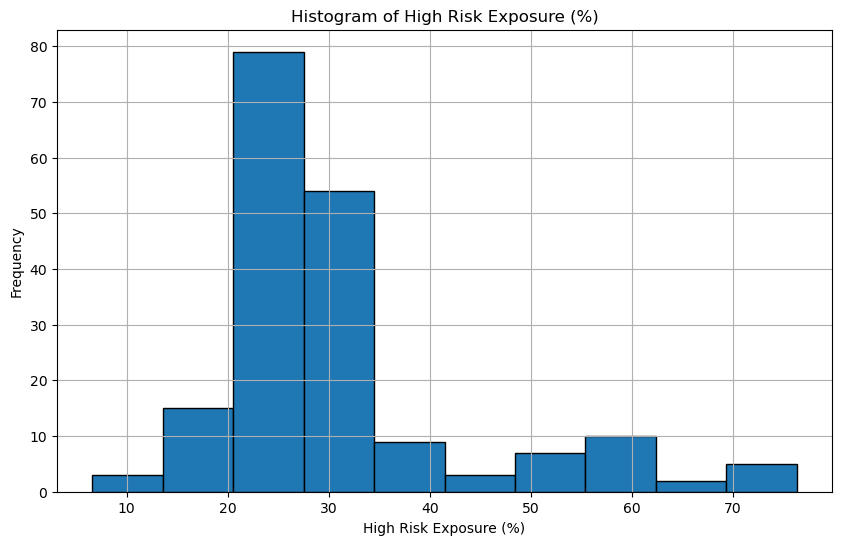

In [69]:
import matplotlib.pyplot as plt
# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(df2['High Risk Exposure (%)'], bins=10, edgecolor='black')
plt.title('Histogram of High Risk Exposure (%)')
plt.xlabel('High Risk Exposure (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [70]:
df2['High Risk Exposure (%)'].median()

27.001895589245205

## Imports fin. cons.
----

### Calculating exposure

risk_cs is the same as in the country-level analysis

In [43]:
import pickle
import pandas as pd


# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Country/risk_cs_imports_fin_leontief_inform_eora.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    risk_cs = pickle.load(f)

In [ ]:
index_cs = L.index

L = mriot.L

Y = mriot.Y.copy()
idx = pd.IndexSlice
# List of categories you want to keep
categories_to_keep = [
    'Household final consumption P.3h',
]

# Filtering to get only columns where the second level matches the categories listed
Y = Y.loc[:, idx[:, categories_to_keep]]

final_production_by_destination_cons = Y.groupby(level='region', axis=1).sum()

ConsoFin = final_production_by_destination_cons[c]
ConsoFin_tot=ConsoFin.groupby('sector').sum()

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * index_cs.size}
ConsoFin_Low = pd.DataFrame(values, index=index_cs)

values = {'High Risk': [0] * index_cs.size}
ConsoFin_High = pd.DataFrame(values, index=index_cs)

values = {'ROW': [0] * index_cs.size}
ConsoFin_row = pd.DataFrame(values, index=index_cs)

values = {'Foreign (%)': [0] * index_cs.size}
ConsoFin_Foreign = pd.DataFrame(values, index=index_cs)

values = {'Local (%)': [0] * index_cs.size}
ConsoFin_Local = pd.DataFrame(values, index=index_cs)

for c in country_list:
    ConsoFin = final_production_by_destination_cons[c]
    ConsoFin_tot=ConsoFin.groupby('sector').sum()
    country_list_except = [x for x in country_list if x != c]
    for s in sector_list:
        if ConsoFin_tot.loc[s]>0:
            for cc in country_list:
                ConsoFin_Low.loc[c,s] = ConsoFin_Low.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[c].loc[(cc, s), 'Low Risk']/100
                ConsoFin_High.loc[c,s] = ConsoFin_High.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[c].loc[(cc, s), 'High Risk']/100
                ConsoFin_row.loc[c,s] = ConsoFin_row.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[c].loc[(cc, s), 'ROW']/100

            ConsoFin_Low.loc[c,s] = ConsoFin_Low.loc[c,s] / ConsoFin_tot.loc[s]*100
            ConsoFin_High.loc[c,s] = ConsoFin_High.loc[c,s] / ConsoFin_tot.loc[s]*100
            ConsoFin_row.loc[c,s] = ConsoFin_row.loc[c,s] / ConsoFin_tot.loc[s]*100

            ConsoFin_Foreign.loc[c,s] = ConsoFin_Low.loc[c,s].iloc[0] + ConsoFin_High.loc[c,s].iloc[0]+ConsoFin_row.loc[c,s].iloc[0]
            ConsoFin_Local.loc[c,s] = 100 - ConsoFin_Foreign.loc[c,s].iloc[0]
            
# List of DataFrames to concatenate
dataframes_to_concat = [ConsoFin_Low, ConsoFin_High, ConsoFin_row, ConsoFin_Foreign, ConsoFin_Local]

resulting_dataframe_sectors_cons_leontief = pd.concat(dataframes_to_concat, axis=1)

result = resulting_dataframe_sectors_cons_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development','sector', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])


resulting_dataframe_sectors_imports_fin_product_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_32660\151811722.py:15: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  final_production_by_destination_cons = Y.groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_32660\151811722.py:46: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '15.308044541740715' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ConsoFin_Low.loc[c,s] = ConsoFin_Low.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[c].loc[(cc, s), 'Low Risk']/100
C:\Users\delah\AppData\Local\Temp\ipykernel_32660\151811722.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.03720762672659792' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ConsoFin_High.loc[c,s] = ConsoFin_High.loc[c,s

In [ ]:
resulting_dataframe_sectors_imports_fin_product_leontief

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,sector,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%)
0,"Palestine, State of",PSE,3.8,High Risk,Middle East & North Africa,Upper middle income,5159253.0,Developing,Re-export & Re-import,86.575612,12.713357,0.709142,99.998111,0.001889,12.804401
1,Benin,BEN,4.9,High Risk,Sub-Saharan Africa,Lower middle income,13712828.0,Least Developed,Re-export & Re-import,87.124409,12.151588,0.720814,99.996811,0.003189,12.240208
2,French Polynesia,PYF,NaN,Unknown,East Asia & Pacific,High income,308872.0,Developing,Re-export & Re-import,86.485026,12.789205,0.721357,99.995588,0.004412,12.882704
3,Togo,TGO,4.8,High Risk,Sub-Saharan Africa,Low income,9053799.0,Least Developed,Re-export & Re-import,87.248375,12.007424,0.739539,99.995338,0.004662,12.097453
4,El Salvador,SLV,4.6,High Risk,Latin America & Caribbean,Upper middle income,6364943.0,Developing,Re-export & Re-import,81.704467,17.296972,0.993713,99.995152,0.004848,17.471435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4909,Italy,ITA,2.7,Low Risk,Europe & Central Asia,High income,58662524.0,Developed,"Electricity, Gas and Water",0.000218,0.000165,0.000016,0.000399,99.999601,43.073051
4910,Austria,AUT,2.0,Low Risk,Europe & Central Asia,High income,9056214.0,Developed,Hotels and Restraurants,0.000146,0.000154,0.000053,0.000353,99.999647,51.481085
4911,Guyana,GUY,4.2,High Risk,Latin America & Caribbean,High income,813834.0,Developing,Construction,0.000091,0.000138,0.000087,0.000316,99.999684,60.311764
4912,Singapore,SGP,0.7,Low Risk,East Asia & Pacific,High income,5673743.0,Developing,"Education, Health and Other Services",0.000185,0.000104,0.000012,0.000301,99.999699,36.125383


In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Sector/resulting_dataframe_sectors_imports_fin_product_leontief_inform_eora.pkl'

# Save the dictionary to a file
with open(file_path_pickle, 'wb') as f:
#    pickle.dump(resulting_dataframe_sectors_imports_fin_product_leontief, f)

In [47]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Sector/resulting_dataframe_sectors_imports_fin_product_leontief_inform_eora.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_sectors_imports_fin_product_leontief = pickle.load(f)

### Plot

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


NameError: name 'median_high_risk_developed_consumption' is not defined

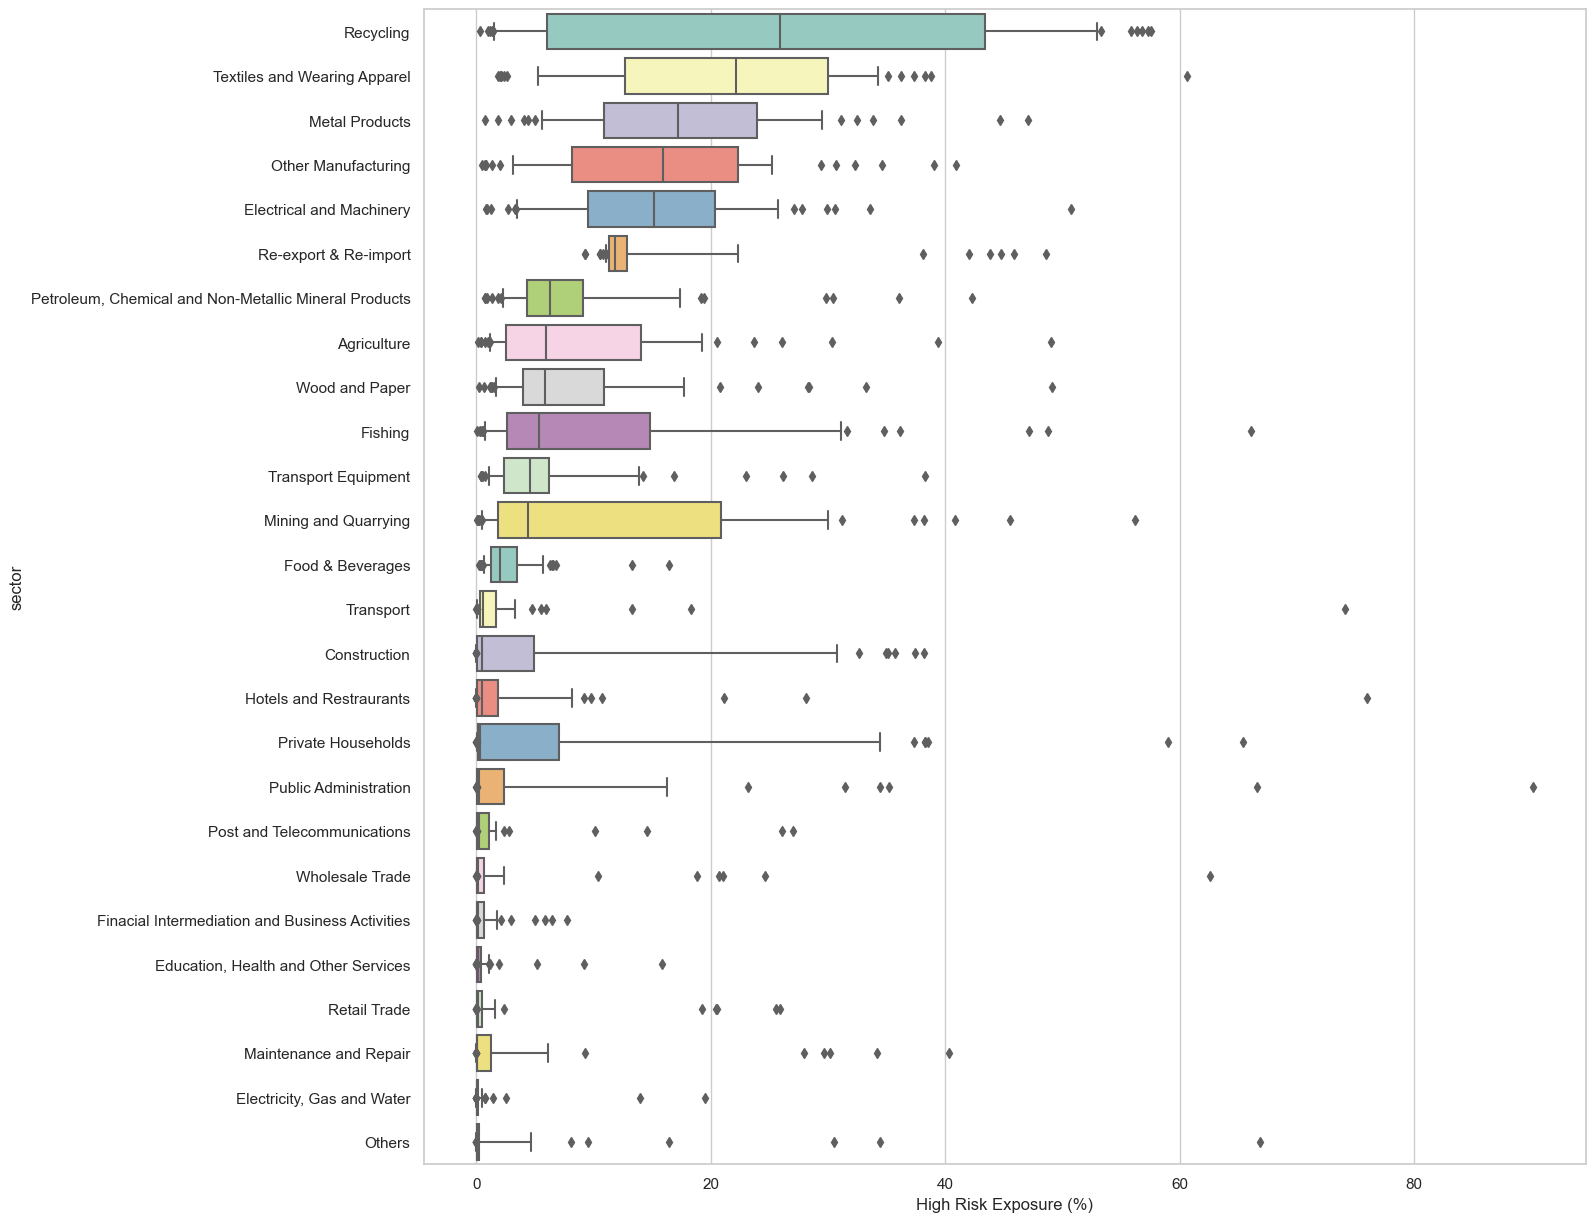

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming your dataframe is loaded as df
df = resulting_dataframe_sectors_imports_fin_product_leontief
# Split the data
df_developed = df[df['Development'] == 'Developed']

# Calculate the IQR and determine outliers manually
Q1 = df_developed['High Risk Exposure (%)'].quantile(0.25)
Q3 = df_developed['High Risk Exposure (%)'].quantile(0.75)
IQR = Q3 - Q1

# Calculate the median 'High Risk' for each sector in developed countries
sector_medians_developed = df_developed.groupby('sector')['High Risk Exposure (%)'].median()
sector_medians_developed = sector_medians_developed.sort_values(ascending=False)

# Set the threshold for median
threshold = 0  # Adjust this threshold as needed

# Filter sectors based on the threshold
selected_sectors = sector_medians_developed[sector_medians_developed > threshold].index
# Sort the sectors by these medians in descending order
sorted_sectors = sector_medians_developed.sort_values(ascending=False).index

# Set the style for the plots
sns.set(style="whitegrid")

# Create a figure and axes
fig, ax = plt.subplots(figsize=(15, 15))

# Create the boxplot with horizontal orientation for selected sectors
sns.boxplot(y='sector', x='High Risk Exposure (%)', data=df_developed[df_developed['sector'].isin(selected_sectors)], ax=ax,
            order=selected_sectors, orient='h', palette="Set3",whis=[10, 90])


# Annotations and aesthetics
ax.axvline(x=median_high_risk_developed_consumption, color='black', linestyle='--', linewidth=2, alpha=0.5)

# Suppress the y-axis label
ax.set_ylabel('')

# Suppress the frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Customize x-axis
x_ticks = np.linspace(0, 80, 9)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f'{x:.0f}%' for x in x_ticks], fontsize=16)

# Customize y-axis
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)

# Set x-axis label
ax.set_xlabel('Cross-border exposure for final consumption, by sector, in developed countries (%)', fontsize=14, fontweight='bold', labelpad=20)

plt.tight_layout()
#plt.savefig(r"Figures\Supp Mat\D\Fig1b.png")
plt.show()

## Concentration

### Code

Computing Hirschman-Herfindahl Index on the share of imported goods coming from each country

HHI = 1 when there is only one supplier. When an infinity of suppliers, HHI = 0.

In [48]:
multi_index = pd.MultiIndex.from_product([country_list, sector_list], names=['country', 'sector'])

values = {'HHI': [0] * multi_index.size}
hhi_inputs = pd.DataFrame(values, index=multi_index)

L=mriot.L
y= Y.sum(axis = 1)

for c in country_list:
    for s in sector_list:
        L_c=L[c]
        y_c=y[c]
        L_c=L_c.loc[~L.index.get_level_values('region').isin([c])]
        total_inputs_ext_s_to_c = L_c.groupby('sector').sum().loc[s].dot(y_c)
        hhi=0
        country_list_except_c = [item for item in country_list if item != c]
        for c0 in country_list_except_c:
            share_c0 = L_c.loc[c0,s].dot(y_c)/total_inputs_ext_s_to_c
            hhi = hhi + share_c0**2
        hhi_inputs.loc[c,s]=hhi

C:\Users\delah\AppData\Local\Temp\ipykernel_32660\4238024521.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.04898486018108092' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  hhi_inputs.loc[c,s]=hhi


KeyboardInterrupt: 

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Sector/hhi_imports_interm_inform_eora.pkl'

# Save the dictionary to a file
with open(file_path_pickle, 'wb') as f:
#    pickle.dump(hhi_imports_interm, f)

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/hhi_imports_interm_inform_eora.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    hhi_imports_interm = pickle.load(f)

Final consumption

In [ ]:
import pandas as pd
multi_index = pd.MultiIndex.from_product([country_list, sector_list], names=['country', 'sector'])

values = {'HHI': [0] * multi_index.size}
hhi_imports_fin = pd.DataFrame(values, index=multi_index)

L=mriot.L
Y = mriot.Y.copy()
y= Y.sum(axis = 1)

idx = pd.IndexSlice
# List of categories you want to keep
categories_to_keep = [
    'Household final consumption P.3h']

# Filtering to get only columns where the second level matches the categories listed
Y = Y.loc[:, idx[:, categories_to_keep]]

Y = Y.groupby(level='region', axis=1).sum()

for c in country_list:
    for s in sector_list:
        Y_c =Y[c]
        total_cons_ext_s_to_c = Y_c.loc[~Y_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s]
        hhi=0
        country_list_except_c = [item for item in country_list if item != c]
        for c0 in country_list_except_c:
            share_c0 = Y_c.loc[c0,s]/total_cons_ext_s_to_c
            hhi = hhi + share_c0**2
        hhi_imports_fin.loc[c,s]=hhi

C:\Users\delah\AppData\Local\Temp\ipykernel_24592\3510978600.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  Y = Y.groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_24592\3510978600.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.09418220121648843' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  hhi_cons.loc[c,s]=hhi


### Plot

In [ ]:
df1=resulting_dataframe_sectors_imports_fin_product_leontief
df2=hhi_imports_fin
result = pd.merge(df1, df2, left_on=['Country Code', 'sector'], right_on=['country', 'sector'], how='left')
df_fin=result

In [ ]:
df1=resulting_dataframe_sectors_imports_interm_product_leontief
df2=hhi_imports_interm
result = pd.merge(df1, df2, left_on=['Country Code', 'sector'], right_on=['country', 'sector'], how='left')
df_interm=result

C:\Users\delah\AppData\Local\Temp\ipykernel_19852\1151911198.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (filtered_sector_medians['High Risk Exposure (%)'][i], filtered_sector_medians['HHI'][i]),fontsize=13)


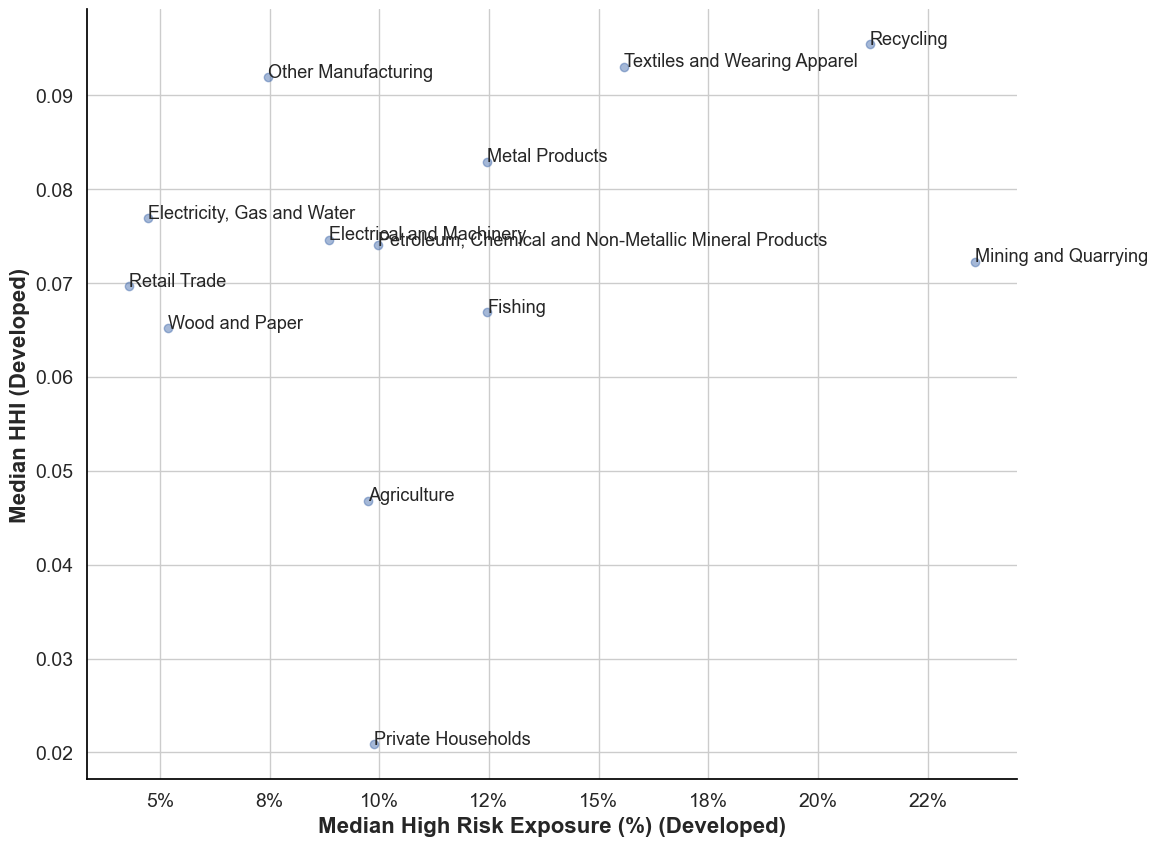

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your data is already in a DataFrame named 'df'
# Filter the DataFrame to only include rows where Development is 'Developed'
df = df_fin
developed_df = df[df['Development'] == 'Developed']

# Group by 'sector' and calculate median values specifically for numeric columns
sector_medians = developed_df.groupby('sector').median(numeric_only=True)[['High Risk Exposure (%)', 'HHI']]

# Filter out sectors where the median High Risk Exposure (%) is less than 2%
df_country = resulting_dataframe_sectors_imports_fin_product_leontief
median_high_risk_developed = df_country[df_country['Development'] == 'Developed']['High Risk Exposure (%)'].median()

filtered_sector_medians = sector_medians[sector_medians['High Risk Exposure (%)'] >= median_high_risk_developed]

# Plotting
plt.figure(figsize=(12, 10))
ax = plt.gca()  # Get current axis

# Removing top and right borders and setting the bottom and left spines black
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# Scatter plot without the incorrect 'fontsize' parameter
plt.scatter(filtered_sector_medians['High Risk Exposure (%)'], filtered_sector_medians['HHI'], alpha=0.5)

# Setting labels with font size and weight adjustments
plt.xlabel('Median High Risk Exposure (%) (Developed)', fontsize=16, fontweight='bold')
plt.ylabel('Median HHI (Developed)', fontsize=16, fontweight='bold')

# Formatting the x-axis labels as percentages and setting label sizes
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# Setting grid
plt.grid(True)

# Adding sector labels to the points
for i, txt in enumerate(filtered_sector_medians.index):
    plt.annotate(txt, (filtered_sector_medians['High Risk Exposure (%)'][i], filtered_sector_medians['HHI'][i]),fontsize=13)

    
#plt.savefig(r"Figures\Supp Mat\D\Fig3b.png") # Imports fin

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your data is already in a DataFrame named 'df'
# Filter the DataFrame to only include rows where Development is 'Developed'
df = df_interm
developed_df = df[df['Development'] == 'Developed']

# Group by 'sector' and calculate median values specifically for numeric columns
sector_medians = developed_df.groupby('sector').median(numeric_only=True)[['High Risk Exposure (%)', 'HHI']]

# Filter out sectors where the median High Risk Exposure (%) is less than 2%
df_country = resulting_dataframe_sectors_imports_interm_product_leontief
median_high_risk_developed = df_country[df_country['Development'] == 'Developed']['High Risk Exposure (%)'].median()

filtered_sector_medians = sector_medians[sector_medians['High Risk Exposure (%)'] >= median_high_risk_developed]

# Plotting
plt.figure(figsize=(12, 10))
ax = plt.gca()  # Get current axis

# Removing top and right borders and setting the bottom and left spines black
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# Scatter plot without the incorrect 'fontsize' parameter
plt.scatter(filtered_sector_medians['High Risk Exposure (%)'], filtered_sector_medians['HHI'], alpha=0.5)

# Setting labels with font size and weight adjustments
plt.xlabel('Median High Risk Exposure (%) (Developed)', fontsize=16, fontweight='bold')
plt.ylabel('Median HHI (Developed)', fontsize=16, fontweight='bold')

# Formatting the x-axis labels as percentages and setting label sizes
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# Setting grid
plt.grid(True)

# Adding sector labels to the points
for i, txt in enumerate(filtered_sector_medians.index):
    plt.annotate(txt, (filtered_sector_medians['High Risk Exposure (%)'][i], filtered_sector_medians['HHI'][i]),fontsize=13)

    #plt.savefig(r"Figures\Supp Mat\D\Fig3d.png") # Imports interm

plt.show()

# Sensitivity Analysis
-----

Sensitivity analysis on the list of high risk countries.

## Threshold function

Here INFORM Climate Change is imported. Not all countries of EORA26 have a risk index (see 2.2 below).

EORA26 have 189 countries and 15 of them do not have a risk index in INFORM.

6 countries are added to INFORM data (Taiwan, Hong Kong, Macau, Monaco, Andorra, San Marino) by giving them the same climate risk as another country.

9 countries with no climate risk index will be take out of the final data

Two letter country codes are converted into three letter country codes.

low_risk_countries and high_risk_countries are extensively used in the following of the code.

In [12]:
import pandas as pd

def create_local_climate_risk(climate_risk, t):
    df=climate_risk.copy()
    
    df['Local Risk'] = pd.cut(df['Local Climate Risk'], bins=[0, 3.4+t, 10], labels=['Low Risk', 'High Risk'], right=True)

    modified_local_climate_risk=df
    return modified_local_climate_risk


# Call the function with simulated data and thresholds
modified_local_climate_risk = create_local_climate_risk(local_climate_risk, 0)

In [62]:
modified_local_climate_risk

,Country,Country Code,Local Climate Risk,Change in Risk,Local Risk
0,United Arab Emirates,ARE,1.8,0.2,Low Risk
1,Afghanistan,AFG,8.1,0.1,High Risk
2,Antigua and Barbuda,ATG,2.2,0.2,Low Risk
3,Albania,ALB,2.7,0.1,Low Risk
4,Armenia,ARM,5.4,0.1,High Risk
...,...,...,...,...,...
201,French Polynesia,PYF,NaN,NaN,NaN
202,San Marino,SMR,NaN,NaN,NaN
203,Taiwan,TWN,NaN,NaN,NaN
204,USSR,USR,NaN,NaN,NaN


In [114]:
df=create_local_climate_risk(local_climate_risk,0)
L= mriot.L
country_list = L.index.get_level_values(0).unique()

modified_low_risk_countries = list(df[df['Local Risk']=='Low Risk']['Country Code'])
modified_high_risk_countries = list(df[df['Local Risk']=='High Risk']['Country Code'])

modified_low_risk_countries = list(set(modified_low_risk_countries) & set(country_list))
modified_high_risk_countries = list(set(modified_high_risk_countries) & set(country_list))

len(modified_low_risk_countries)+len(modified_high_risk_countries)+len(no_risk_countries)

189

Generate exposure calculation

In [ ]:
import pandas as pd

def calculate_country_inputs(modified_local_climate_risk, mriot):
    Y = mriot.Y
    y = Y.sum(axis = 1)

    L= mriot.L
    country_list = L.index.get_level_values(0).unique()
    sector_list = L.index.get_level_values(1).unique()

    df=modified_local_climate_risk

    modified_low_risk_countries = list(df[df['Local Risk']=='Low Risk']['Country Code'])
    modified_high_risk_countries = list(df[df['Local Risk']=='High Risk']['Country Code'])

    #modified_low_risk_countries = list(set(modified_low_risk_countries) & set(country_list))
    #modified_high_risk_countries = list(set(modified_high_risk_countries) & set(country_list))
    
    values = {'Low Risk': [0] * country_list.size}
    cForeign_Inputs_low = pd.DataFrame(values, index=country_list)

    values = {'High Risk': [0] * country_list.size}
    cForeign_Inputs_high = pd.DataFrame(values, index=country_list)

    values = {'ROW': [0] * country_list.size}
    cForeign_Inputs_row = pd.DataFrame(values, index=country_list)

    values = {'Foreign (%)': [0] * country_list.size}
    cForeign_Inputs = pd.DataFrame(values, index=country_list)

    values = {'Local (%)': [0] * country_list.size}
    cLocal_Inputs = pd.DataFrame(values, index=country_list)


    for c in country_list:
        intrants_c = 0
        intrants_c_foreign = 0
        intrants_c_foreign_low = 0
        intrants_c_foreign_high = 0
        intrants_c_foreign_row = 0


        for s in sector_list:
            L_cs = L[c,s]
            y_cs = y[c,s]
            L_cs_foreign = L_cs[L_cs.index.get_level_values('region') != c]
            L_cs_foreign_low = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(modified_low_risk_countries)]
            L_cs_foreign_high = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(modified_high_risk_countries)]
            L_cs_foreign_row = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(no_risk_countries)]

            intrants_cs = (L_cs*y_cs).sum()
            intrants_cs_foreign = (L_cs_foreign*y_cs).sum()
            intrants_cs_foreign_low = (L_cs_foreign_low*y_cs).sum()
            intrants_cs_foreign_high = (L_cs_foreign_high*y_cs).sum()
            intrants_cs_foreign_row = (L_cs_foreign_row*y_cs).sum()

            intrants_c=intrants_c + intrants_cs
            intrants_c_foreign = intrants_c_foreign + intrants_cs_foreign   
            intrants_c_foreign_low = intrants_c_foreign_low + intrants_cs_foreign_low 
            intrants_c_foreign_high = intrants_c_foreign_high + intrants_cs_foreign_high  
            intrants_c_foreign_row = intrants_c_foreign_row + intrants_cs_foreign_row  

        cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
        cForeign_Inputs_low.loc[c] = intrants_c_foreign_low / intrants_c*100
        cForeign_Inputs_high.loc[c] = intrants_c_foreign_high / intrants_c *100
        cForeign_Inputs_row.loc[c] = intrants_c_foreign_row / intrants_c *100

        cLocal_Inputs.loc[c] = 100 - cForeign_Inputs.loc[c].iloc[0]

    # List of DataFrames to concatenate
    dataframes_to_concat = [cForeign_Inputs_low, cForeign_Inputs_high, cForeign_Inputs_row, cForeign_Inputs, cLocal_Inputs]

    # Concatenate the DataFrames along columns (axis=1)
    resulting_dataframe_country_inputs_leontief = pd.concat(dataframes_to_concat, axis=1)

    # Sorting the data by 'Non-OECD' for better visualization
    result = resulting_dataframe_country_inputs_leontief.sort_values('Foreign (%)', ascending=False).reset_index()


    # Merge the two DataFrames on 'region' column
    result = result.merge(modified_local_climate_risk, left_on='region', right_on='Country Code', how='left')
    
    path='Other_data/World_Bank_Regions.xlsx'
    wb_regions = pd.read_excel(path)
    result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

    path='Other_data/World_Bank_Pop.csv'
    wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
    result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

    result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
    result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

    # Convert the column to numeric
    result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

    # Define the function to categorize development status
    def categorize_development(region):
        if region in least_developed_countries:
            return 'Least Developed'
        elif region in developed_countries:
            return 'Developed'
        elif region in developing_countries:
            return 'Developing'
        else:
            return 'Unknown'

    result['Development'] = result['Country'].apply(categorize_development)

    result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
    result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
    result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

    result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

    # Data are added manually for South and North Sudan because of uncorresponding country codes + Taiwan

    result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
    result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
    result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

    result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
    result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
    result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

    #result.loc[result['Country Code'] == 'TWN', 'Population'] = 23923276

    result=result.reset_index()
    result = result.drop('index', axis=1)
    result = result.dropna(subset=['Region'])

    resulting_dataframe_country_imports_interm_leontief = result
    return resulting_dataframe_country_imports_interm_leontief

Sensitivity analysis for different threshold : 3.5+t

In [ ]:
# List of values for t
t_values = [-0.75,-0.5,-0.25, 0,0.25, 0.5,0.75]

# Dictionary to store results
resulting_dataframe_country_imports_interm_leontief = {}

for t in t_values:
    modified_local_climate_risk = create_local_climate_risk(local_climate_risk, t)
    resulting_dataframe_country_imports_interm_leontief[t] = calculate_country_inputs(modified_local_climate_risk, mriot)

C:\Users\delah\AppData\Local\Temp\ipykernel_5204\179305977.py:63: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '21.546055181159858' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_5204\179305977.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '10.968199372021552' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs_low.loc[c] = intrants_c_foreign_low / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_5204\179305977.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '10.145577441150163' has dtype incompatible with int64, please explicitly cast to a compatible dtype 

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Sensitivity analysis/resulting_dataframe_country_imports_interm_leontief_threshold_inform_eora.pkl'

# Save the dictionary to a file
with open(file_path_pickle, 'wb') as f:
#    pickle.dump(resulting_dataframe_country_imports_interm_leontief, f)

In [50]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Sensitivity analysis/resulting_dataframe_country_imports_interm_leontief_threshold_inform_eora.pkl'


# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_imports_interm_leontief = pickle.load(f)

Histogram of countries by risk

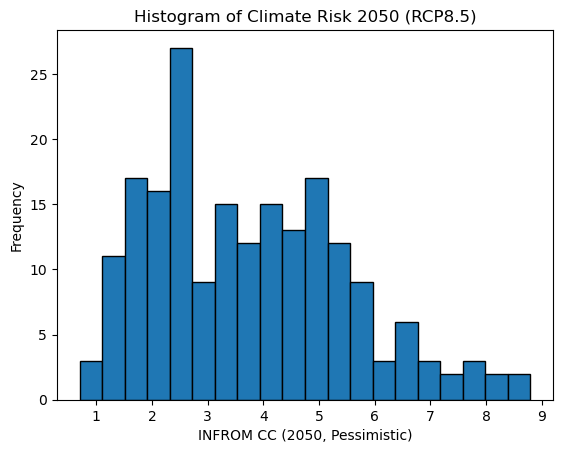

In [6]:
import matplotlib.pyplot as plt

# Extract the 'INDEX 2050 Pessimistic' values
index_2050_values = Climate_Risk_INFORMCC['INDEX 2050 Pessimistic']

# Create a histogram
plt.hist(index_2050_values, bins=20, edgecolor='black')

# Add labels and title
plt.xlabel('INFROM CC (2050, Pessimistic)')
plt.ylabel('Frequency')
plt.title('Histogram of Climate Risk 2050 (RCP8.5)')

# Show the plot
plt.show()

In [118]:
df=Climate_Risk_INFORMCC
# Merge to get full country names
merged_df = pd.merge(df, iso_convert, left_on='Country', right_on='alpha-2', how='left')

# Filter countries where INDEX 2050 Pessimistic is between 3.5 and 3
between_3_5_and_3 = merged_df[(merged_df['INDEX 2050 Pessimistic'] <= 3.5) & (merged_df['INDEX 2050 Pessimistic'] >= 3)]

# Filter countries where INDEX 2050 Pessimistic is between 3.5 and 2.5
between_3_5_and_2_5 = merged_df[(merged_df['INDEX 2050 Pessimistic'] <= 3.5) & (merged_df['INDEX 2050 Pessimistic'] >= 2.5)]

# Print the results
print("Countries where INDEX 2050 Pessimistic is between 3.5 and 3:")
print(between_3_5_and_3['name'])

print("\nCountries where INDEX 2050 Pessimistic is between 3.5 and 2.5:")
print(between_3_5_and_2_5['name'])

Countries where INDEX 2050 Pessimistic is between 3.5 and 3:
6                             Argentina
10               Bosnia and Herzegovina
23                               Bhutan
24                             Botswana
33                                Chile
37                           Costa Rica
55                                 Fiji
56     Micronesia (Federated States of)
61                              Georgia
82                              Jamaica
110                    Marshall Islands
121                            Malaysia
142                            Paraguay
146                  Russian Federation
164                            Eswatini
171                             Tunisia
172                               Tonga
179            United States of America
186                               Samoa
Name: name, dtype: object

Countries where INDEX 2050 Pessimistic is between 3.5 and 2.5:
3                               Albania
6                             Argentina
8        

In [128]:
Climate_Risk_INFORMCC[Climate_Risk_INFORMCC['Country']=='US']

,Country,INFORM 2022,INDEX 2050 Pessimistic,INFORM 2050 Optimistic,INFORM 2080 Pessimistic,INFORM 2080 Optimistic,Change in Risk
179,US,3.1,3.2,3.2,3.3,3.3,0.1


## Taking a country one at a time

The country that is taken out of the risk list is given a score that is a miror in the non risky side of its actual score.
E.g. a country with risk index 4 is given a risk index of 3.5-(4-3.5)/(10-3.5)*3.5 = 3.23

In [ ]:
resulting_dataframe_country_imports_interm_leontief={}
for c in high_risk_countries:
    modified_local_climate_risk = local_climate_risk.copy()
    modified_local_climate_risk.loc[modified_local_climate_risk['Country Code'] == c, 'Local Climate Risk'] = (3.5 - (modified_local_climate_risk.loc[modified_local_climate_risk['Country Code'] == c, 'Local Climate Risk'] - 3.5) / (10 - 3.5) * 3.5)
    modified_local_climate_risk=create_local_climate_risk(modified_local_climate_risk,0)
    resulting_dataframe_country_imports_interm_leontief[c] = calculate_country_inputs(modified_local_climate_risk, mriot)

C:\Users\delah\AppData\Local\Temp\ipykernel_19852\179305977.py:63: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '21.546055181159858' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_19852\179305977.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '13.499948152210383' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs_low.loc[c] = intrants_c_foreign_low / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_19852\179305977.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '7.613828660961327' has dtype incompatible with int64, please explicitly cast to a compatible dtyp

In [ ]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Sensitivity analysis/resulting_dataframe_country_imports_interm_leontief_onecountryout_inform_eora.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_country_imports_interm_leontief, f)

In [49]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/Sensitivity analysis/resulting_dataframe_country_imports_interm_leontief_onecountryout_inform_eora.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_country_imports_interm_leontief = pickle.load(f)

## X/Y Graph

Comparing with changing threshold

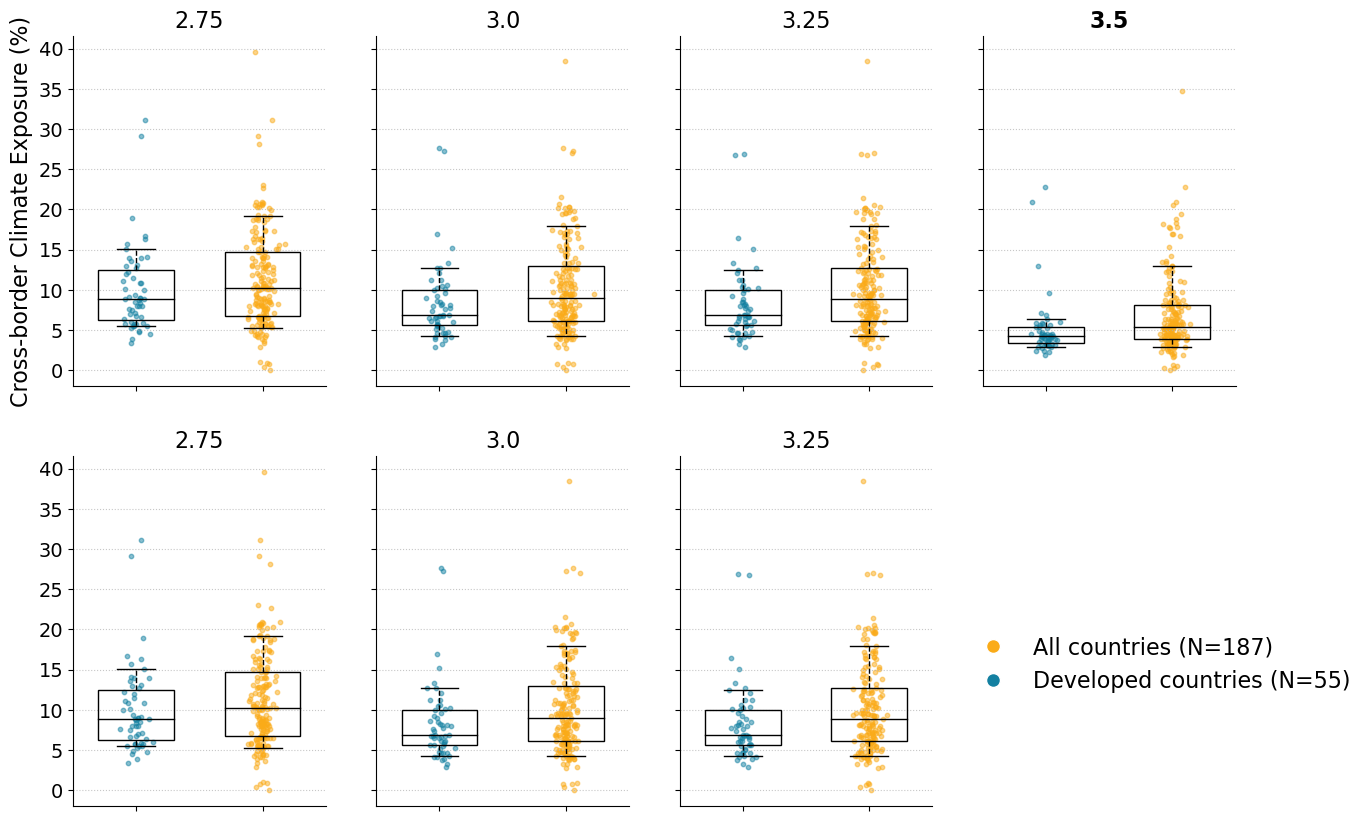

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D 
import numpy as np

# Lists to store t values and data for developed and non-developed countries
t_values = [-0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75]
data_developed = []
data_all = []

# Custom colors
colors = ['#1380A1', '#FAAB18']  # Orange for Developed, Blue for Developing/Least Developed

# Iterate over t values
for t in t_values:
    # Assuming df_t is the resulting dataframe for a specific t value
    df_t = resulting_dataframe_country_imports_interm_leontief[t]
    
    # Filter data
    developed_data = df_t[df_t['Development'] == 'Developed']['High Risk Exposure (%)'].tolist()
    all_data = df_t['High Risk Exposure (%)'].tolist()
    
    # Append data for plotting
    data_developed.append(developed_data)
    data_all.append(all_data)

# Define the figure and axes for two rows
#fig, axes = plt.subplots(nrows=2, ncols=len(t_values), figsize=(20, 8), sharey=True)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15, 10), sharey=True)

# Plot data in subplots
for row, t_values_row in enumerate([t_values[:4], t_values[4:]]):  # Adjusted to match your t_values splitting
    for idx, ax in enumerate(axes[row]):
        if idx < len(t_values_row):
            # Plot boxplot for developed countries
            ax.boxplot(data_developed[idx], positions=[1], widths=0.6, patch_artist=True,
                       boxprops=dict(facecolor='none', color='black'),
                       medianprops=dict(color="black"),
                       whiskerprops=dict(color='black', linestyle='--'),
                       capprops=dict(color='black'),
                       flierprops=dict(marker='o', markerfacecolor=colors[0], markersize=5, markeredgecolor='black'),
                       showfliers=False,whis=[10, 90])
            
            # Plot boxplot for non-developed countries
            ax.boxplot(data_all[idx], positions=[2], widths=0.6, patch_artist=True,
                       boxprops=dict(facecolor='none', color='black'),
                       medianprops=dict(color="black"),
                       whiskerprops=dict(color='black', linestyle='--'),
                       capprops=dict(color='black'),
                       flierprops=dict(marker='o', markerfacecolor=colors[1], markersize=5, markeredgecolor='black'),
                       showfliers=False,whis=[10, 90])
            
            # Add jittered scatter plot for developed countries
            jitter = np.random.normal(1, 0.05, size=len(data_developed[idx]))
            ax.scatter(jitter, data_developed[idx], color=colors[0], alpha=0.5, s=10)

            # Add jittered scatter plot for non-developed countries
            jitter = np.random.normal(2, 0.05, size=len(data_all[idx]))
            ax.scatter(jitter, data_all[idx], color=colors[1], alpha=0.5, s=10)

            # Set x-ticks and labels off
            ax.set_xticklabels([])

            if t_values[idx]==0:
                ax.set_title(f'{t_values[idx]+3.5}', size=16,fontweight='bold')
            else:
                ax.set_title(f'{t_values[idx]+3.5}', size=16)

            # Configure y-ticks and labels
            ax.tick_params(axis='y', labelsize=14)
            if row == 0 and idx == 0:
                ax.set_ylabel('Cross-border Climate Exposure (%)', size=16)
            if row == 1:
                ax.set_ylabel('')  # Suppress y-axis label on the second line

            # Only enable y-axis grid and remove x-axis grid for clarity
            ax.yaxis.grid(True, linestyle=':', alpha=0.7)
            ax.xaxis.grid(False)

            # Hide the top and right spines to reduce visual clutter
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            # Make spines darker
            for spine in ['left', 'bottom']:
                ax.spines[spine].set_color('black')

        else:
            # If the index is out of range, remove the subplot
            fig.delaxes(ax)

# Define custom legend for the scatter points
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=f'All countries (N={len(all_data)})',  # Use f-string for formatting
           markerfacecolor='#FAAB18', markersize=10),
    Line2D([0], [0], marker='o', color='w',
           label=f'Developed countries (N={len(developed_data)})',
           markerfacecolor='#1380A1', markersize=10)
]

# Add the legend to the figure, not to the individual axes
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.85, 0.3), ncol=1, fontsize=16, frameon=False)

#plt.tight_layout()

# Save the plot to a file
#plt.savefig(r'Figures\Supp Mat\E\Figure2a.png')

# Display the plot
plt.show()

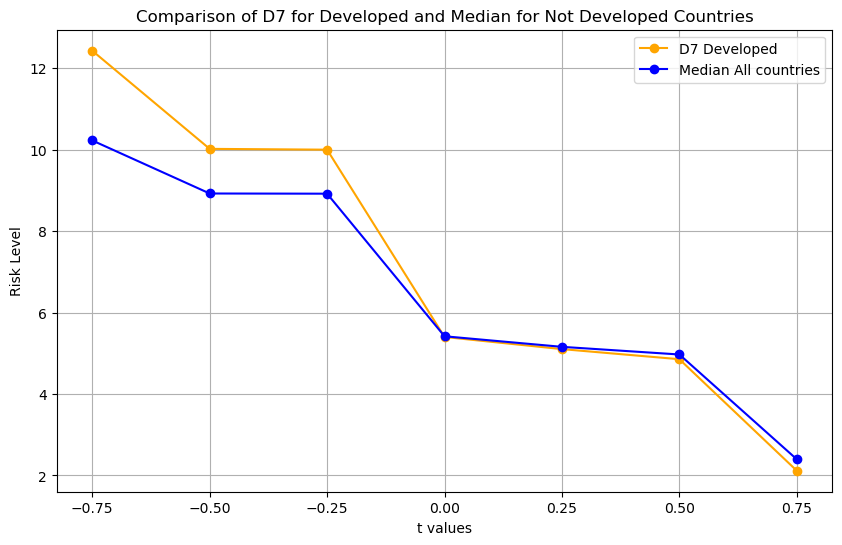

In [ ]:
import matplotlib.pyplot as plt

# Lists to store t values
t_values = [-0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75]
d_developed = []
median_all = []

# Iterate over t values
for t in t_values:
    df_t = resulting_dataframe_country_imports_interm_leontief[t]
    
    # Filter data
    developed_data = df_t[df_t['Development'] == 'Developed']['High Risk Exposure (%)']
    #not_developed_data = df_t[df_t['Development'] != 'Developed']['High Risk']
    all_country_data = df_t['High Risk Exposure (%)']
    
    # Check if there is any data to process and calculate D9 for developed and median for not developed
    if not developed_data.empty:
        d_developed.append(np.percentile(developed_data, 75))
    else:
        d_developed.append(np.nan)  # Append NaN if no data
    
    if not all_country_data.empty:
        median_all.append(np.median(all_country_data))
    else:
        median_all.append(np.nan)  # Append NaN if no data

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(t_values, d_developed, marker='o', linestyle='-', color='orange', label='D7 Developed')
plt.plot(t_values, median_all, marker='o', linestyle='-', color='blue', label='Median All countries')

# Adding labels and title
plt.xlabel('t values')
plt.ylabel('Risk Level')
plt.title('Comparison of D7 for Developed and Median for Not Developed Countries')
plt.xticks(t_values)
plt.grid(True)

# Adding a legend
plt.legend()

# Show the plot
plt.show()

In [ ]:
t=0
df_t = resulting_dataframe_country_imports_interm_leontief[t]
    
# Filter data
developed_data = df_t[df_t['Development'] == 'Developed']['High Risk Exposure (%)']
#not_developed_data = df_t[df_t['Development'] != 'Developed']['High Risk']
not_developed_data = df_t[df_t['Development'] != 'Developed']['High Risk Exposure (%)']

all_country_data = df_t['High Risk Exposure (%)']

print('All :',np.percentile(all_country_data, 50),' ; Developed:',np.percentile(developed_data, 75),'Not Developed :',np.percentile(not_developed_data, 50))


All : 5.4196077730688454  ; Developed: 5.402504061198743 Not Developed : 6.210987001868804


In [56]:
not_northam_not_eu_developed = df_t[(df_t['Development'] == 'Developed')&(df_t['Region'] != 'North America')&(df_t['Region'] != 'Europe & Central Asia')]['High Risk Exposure (%)']
print('All :',np.percentile(all_country_data, 50),' ; Developed:',np.percentile(developed_data, 75),'Notnot :',np.percentile(not_northam_not_eu_developed, 60))

All : 5.4196077730688454  ; Developed: 5.402504061198743 Notnot : 5.852646829883456


In [57]:
europe_developed = df_t[(df_t['Development'] == 'Developed')&(df_t['Region'] == 'Europe & Central Asia')]['High Risk Exposure (%)']

print('All :',np.percentile(all_country_data, 50),' ; Developed:',np.percentile(developed_data, 75),'Notnot :',np.percentile(europe_developed, 60))

All : 5.4196077730688454  ; Developed: 5.402504061198743 Notnot : 4.466881241131007


In [72]:
western_european_countries = [
    "Luxembourg",
    "Ireland",
    "Switzerland",
    "Belgium",
    "Denmark",
    "Netherlands",
    "Iceland",
    "United Kingdom of Great Britain and Northern Ireland",
    "Liechtenstein",
    "France",
    "Norway",
    "Andorra",
    "Italy",
    "Sweden",
    "Spain",
    "Monaco"
]

western_europe_developed = df_t[(df_t['Development'] == 'Developed')&(df_t['Country'].isin(western_european_countries))]['High Risk Exposure (%)']
np.percentile(western_europe_developed, 93)

5.417897401881835

In [65]:
western_european_countries

['Luxembourg',
 'Ireland',
 'Switzerland',
 'Belgium',
 'Denmark',
 'Netherlands',
 'Iceland',
 'United Kingdom of Great Britain and Northern Ireland',
 'Liechtenstein',
 'France',
 'Norway',
 'Andorra',
 'Italy',
 'Sweden',
 'Spain',
 'Monaco']

Comparing with taking one country out at a time

In [ ]:
resulting_dataframe_country_imports_interm_leontief

{'DZA':                   Country Country Code  Local Climate Risk Local Risk  \
 0    Moldova, Republic of          MDA                 2.6   Low Risk   
 1               Hong Kong          HKG                 4.0  High Risk   
 2              San Marino          SMR                 2.7   Low Risk   
 3               Singapore          SGP                 0.7   Low Risk   
 4              Luxembourg          LUX                 1.2   Low Risk   
 ..                    ...          ...                 ...        ...   
 175               Somalia          SOM                 8.8  High Risk   
 176           South Sudan          SDS                 8.6  High Risk   
 177                Guyana          GUY                 4.2  High Risk   
 178               Myanmar          MMR                 6.3  High Risk   
 179              Zimbabwe          ZWE                 4.6  High Risk   
 
                         Region         Income group  Population  \
 0        Europe & Central Asia  Up

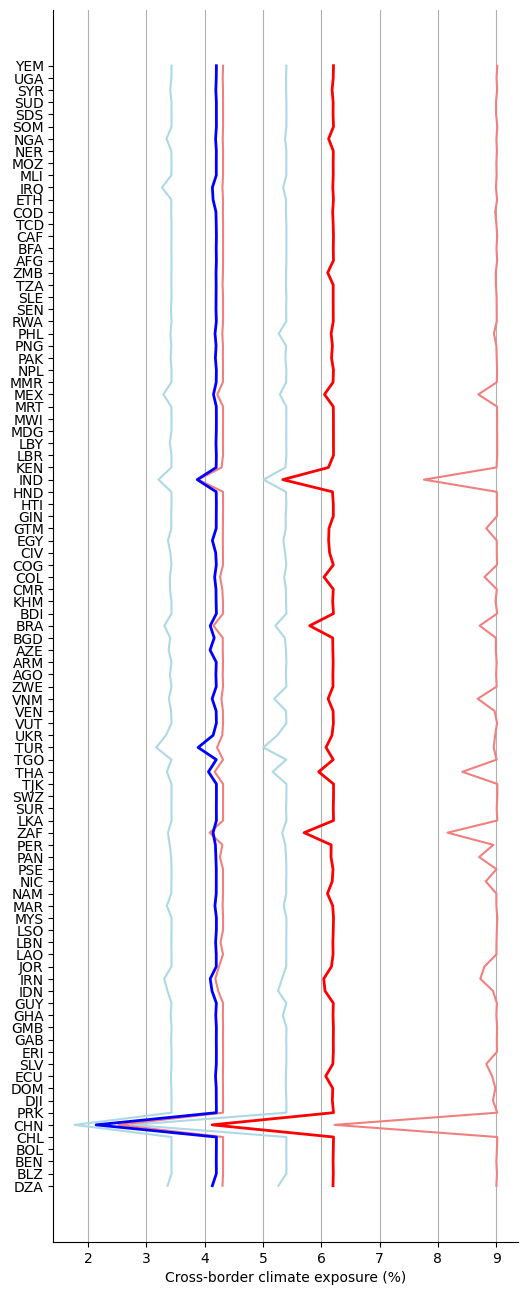

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Lists to store t values, quartiles, and median for developed and non-developed countries
risky_countries = high_risk_countries
quartile_25_developed = []
quartile_75_developed = []
quartile_25_non_developed = []
quartile_75_non_developed = []
median_developed = []
median_non_developed = []

# Iterate over countries
for c in high_risk_countries:
    # Assuming df_c is the resulting dataframe for a specific country
    df_c = resulting_dataframe_country_imports_interm_leontief[c]
    
    # Filter rows where Development is 'Developed'
    developed_countries = df_c[df_c['Development'] == 'Developed']
    # Filter rows where Development is not 'Developed' (i.e., non-developed)
    non_developed_countries = df_c[df_c['Development'] != 'Developed']
    
    # Calculate the quartiles of 'High Risk' for developed countries
    quartile_25_dev = np.percentile(developed_countries['High Risk Exposure (%)'], 25)
    quartile_75_dev = np.percentile(developed_countries['High Risk Exposure (%)'], 75)
    
    # Calculate the quartiles of 'High Risk' for non-developed countries
    quartile_25_non_dev = np.percentile(non_developed_countries['High Risk Exposure (%)'], 25)
    quartile_75_non_dev = np.percentile(non_developed_countries['High Risk Exposure (%)'], 75)
    
    # Calculate the median of 'High Risk' for developed and non-developed countries
    median_dev = np.median(developed_countries['High Risk Exposure (%)'])
    median_non_dev = np.median(non_developed_countries['High Risk Exposure (%)'])
    
    quartile_25_developed.append(quartile_25_dev)
    quartile_75_developed.append(quartile_75_dev)
    quartile_25_non_developed.append(quartile_25_non_dev)
    quartile_75_non_developed.append(quartile_75_non_dev)
    median_developed.append(median_dev)
    median_non_developed.append(median_non_dev)

    
# Plotting
plt.figure(figsize=(6, 16))

# Plotting
plt.plot(quartile_25_developed, high_risk_countries, color='lightblue')
plt.plot(quartile_75_developed, high_risk_countries, color='lightblue')
plt.plot(quartile_25_non_developed, high_risk_countries, color='lightcoral')
plt.plot(quartile_75_non_developed, high_risk_countries, color='lightcoral')
plt.plot(median_developed, high_risk_countries, color='blue', linewidth=2)
plt.plot(median_non_developed, high_risk_countries, color='red', linewidth=2)

plt.xlabel('Cross-border climate exposure (%)')
# Hide the top and right spines to reduce visual clutter
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.grid(axis='x')  # Show only vertical grid lines

# Save the plot to a file
#plt.savefig(r'Figures\Supp Mat\E\Figure8.png')

plt.show()

In [ ]:
# Lists to store t values, 80th percentiles for developed countries, and median for all countries
positive_difference_countries = []

# Iterate over risky countries
for c in high_risk_countries:
    # Assuming df_c is the resulting dataframe for a specific country
    df_c = resulting_dataframe_country_imports_interm_leontief[c]
    
    # Filter rows where Development is 'Developed'
    developed_countries = df_c[df_c['Development'] == 'Developed']
    
    # Calculate the 75th percentile of 'High Risk' in developed countries
    high_risk_75th_percentile = np.percentile(developed_countries['High Risk Exposure (%)'], 70)
    
    # Calculate the median of 'High Risk' for all countries
    high_risk_median = np.median(df_c['High Risk Exposure (%)'])
    
    # Calculate the difference
    difference = high_risk_75th_percentile - high_risk_median
    
    # Check if the difference is positive
    if difference > 0:
        positive_difference_countries.append(c)

# Print the countries where the difference is positive
print("Countries where the difference between 70th Percentile of Developed Countries and Median of All Countries is positive:")
for country in positive_difference_countries:
    print(country)

KeyError: 'DZA'

## Correlation Graph

A graph with threshold on x axis and R2 and p value on y axis

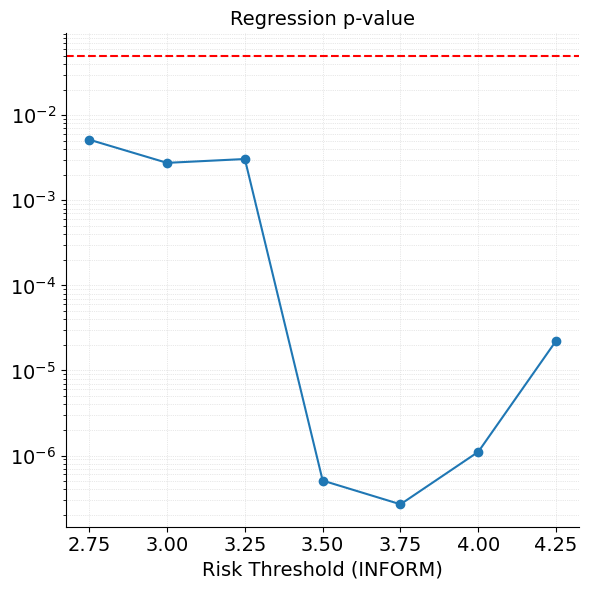

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Lists to store t values, p-values, and R-squared values
t_values = [-0.75,-0.5,-0.25,0,0.25,0.5,0.75]
p_values = []

# Iterate over t values
for t in t_values:
    # Assuming df_t is the resulting dataframe for a specific t value
    df_t = resulting_dataframe_country_imports_interm_leontief[t]
    df_t = df_t.dropna(subset=['Local Climate Risk'])

    # Extracting the columns for regression
    x = df_t['Local Climate Risk']
    y = df_t['Share of Risky Trade Partners (%)']
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    # Append p-value to list
    p_values.append(p_value)

# Convert lists to numpy arrays
t_values = np.array(t_values)
p_values = np.array(p_values)

# Plotting P-values vs. t
plt.figure(figsize=(6, 6))
plt.plot(t_values, p_values, marker='o', linestyle='-')
plt.xlabel('Risk Threshold (INFORM)',fontsize=14)
plt.ylabel('')
plt.title('Regression p-value',fontsize=14)
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

plt.yscale('log')  # Setting logarithmic scale on y-axis
plt.axhline(y=0.05, color='r', linestyle='--')  # Add horizontal line at y = 0.05 in red

ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=14)  # Setting tick label
# Adjust x-ticks to show 3.5 + t
new_labels = [f'{3.5 + t:.2f}' for t in t_values]
ax.set_xticks(t_values)  # Set x-ticks positions
ax.set_xticklabels(new_labels)  # Set new labels

plt.tight_layout()

# Save the plot to a file
#plt.savefig(r'Figures\Supp Mat\E\Figure4b.png')


plt.show()

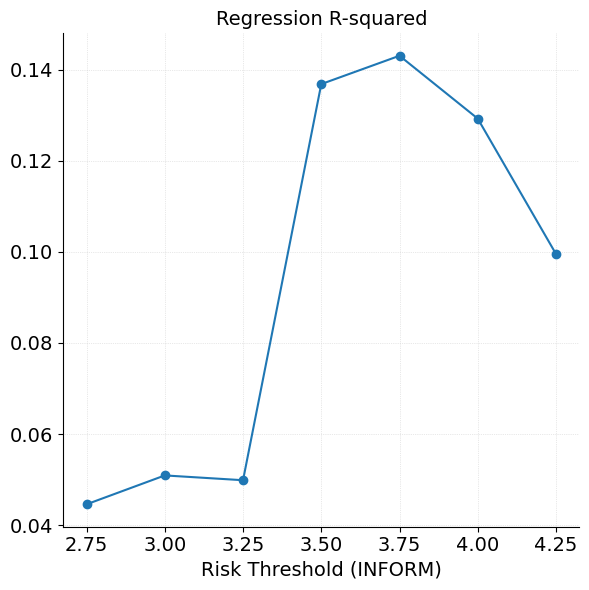

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from scipy import stats
# Lists to store t values and R-squared values
t_values = [ -0.75,-0.5,-0.25, 0,0.25, 0.5,0.75]
r_squared_values = []

# Iterate over t values
for t in t_values:
    # Assuming df_t is the resulting dataframe for a specific t value
    df_t = resulting_dataframe_country_imports_interm_leontief[t]
    df_t = df_t.dropna(subset=['Local Climate Risk'])

    # Extracting the columns for regression
    x = df_t['Local Climate Risk']
    y = df_t['Share of Risky Trade Partners (%)']
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    # Append R-squared value to list
    r_squared_values.append(r_value**2)

# Convert lists to numpy arrays
t_values = np.array(t_values)
r_squared_values = np.array(r_squared_values)

# Plotting R-squared values vs. t
plt.figure(figsize=(6, 6))
plt.plot(t_values, r_squared_values, marker='o', linestyle='-')
plt.xlabel('Risk Threshold (INFORM)',fontsize=14)
plt.ylabel('')
plt.title('Regression R-squared',fontsize=14)
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=14)  # Setting tick label
# Adjust x-ticks to show 3.5 + t
new_labels = [f'{3.5 + t:.2f}' for t in t_values]
ax.set_xticks(t_values)  # Set x-ticks positions
ax.set_xticklabels(new_labels)  # Set new labels

# Save the plot to a file
#plt.savefig(r'Figures\Supp Mat\E\Figure4a.png')


plt.tight_layout()
plt.show()

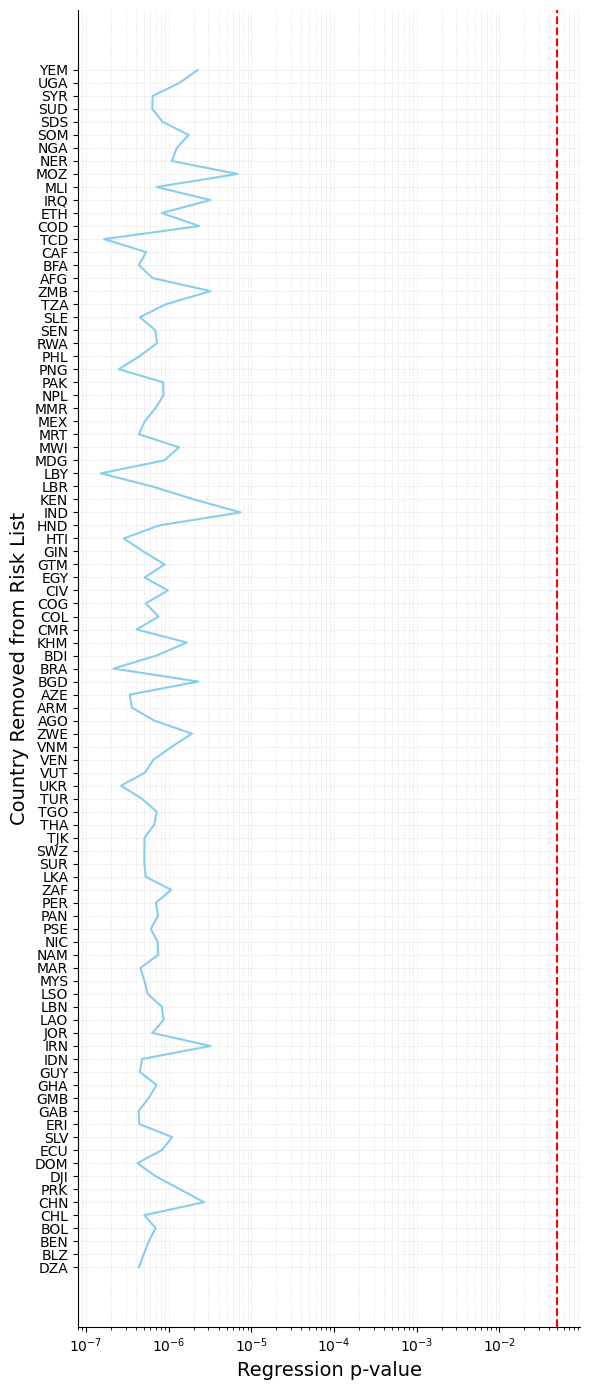

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Lists to store p-values
p_values = []

for c in high_risk_countries:
    # Assuming df_c is the resulting dataframe for a specific country
    df_c = resulting_dataframe_country_imports_interm_leontief[c]
    df_c = df_c.dropna(subset=['Local Climate Risk'])

    
    # Extracting the columns for regression
    x = df_c['Local Climate Risk']
    y = df_c['Share of Risky Trade Partners (%)']
    
    # Perform linear regression
    _, _, _, p_value, _ = stats.linregress(x, y)
    
    # Append p-value to list
    p_values.append(p_value)

# Convert lists to numpy arrays
c_values = np.array(high_risk_countries)
p_values = np.array(p_values)

# Plotting P-values vs. country, but switching axes
plt.figure(figsize=(6, 14))
plt.plot(p_values, c_values, color='skyblue')
plt.ylabel('Country Removed from Risk List',size=14)
plt.xlabel('Regression p-value',size=14)
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

plt.xscale('log')  # Setting logarithmic scale on x-axis
plt.axvline(x=0.05, color='r', linestyle='--')  # Add vertical line at x = 0.05 in red

ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()

# Optional: save the plot to a file
#plt.savefig(r'Figures\Supp Mat\E\Figure6b.png')

plt.show()

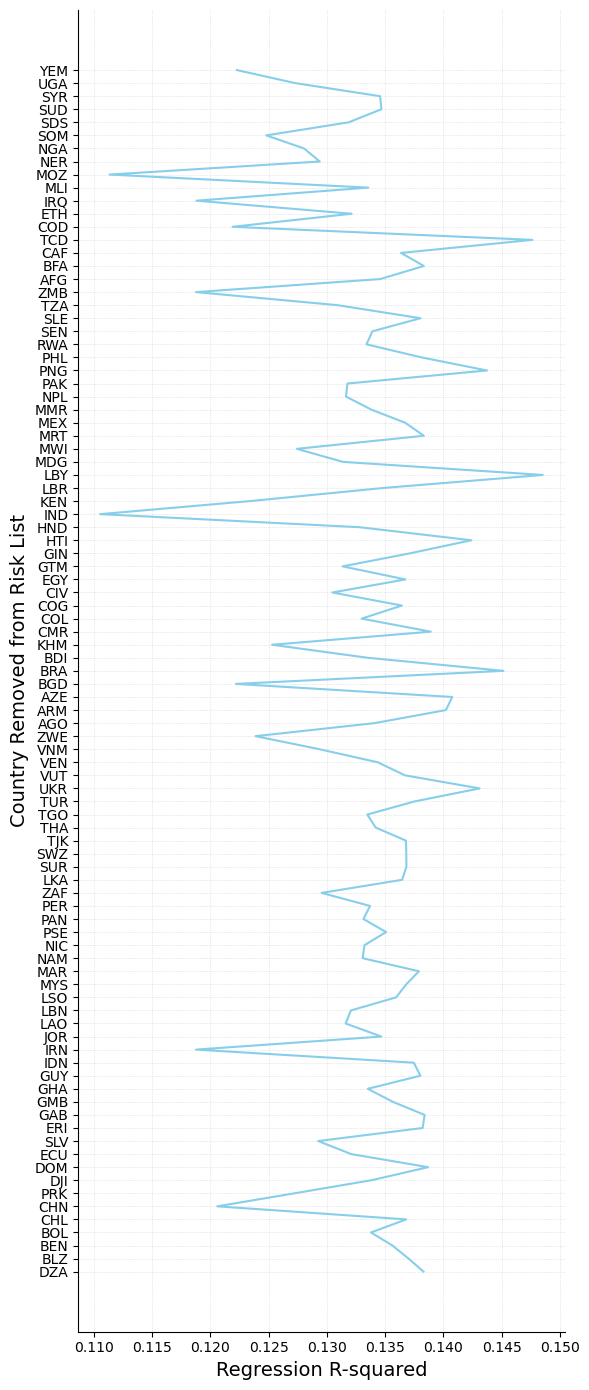

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Lists to store R-squared values
r_squared_values = []

# Assuming risky_countries is defined elsewhere as a list of country names
for c in high_risk_countries:
    # Assuming df_c is the resulting dataframe for a specific country
    df_c = resulting_dataframe_country_imports_interm_leontief[c]
    df_c = df_c.dropna(subset=['Local Climate Risk'])

    # Extracting the columns for regression
    x = df_c['Local Climate Risk']
    y = df_c['Share of Risky Trade Partners (%)']
    
    # Perform linear regression
    _, _, r_value, _, _ = stats.linregress(x, y)
    
    # Append R-squared value to list
    r_squared_values.append(r_value**2)

# Convert lists to numpy arrays
c_values = np.array(high_risk_countries)
r_squared_values = np.array(r_squared_values)

# Plotting R-squared values vs. country, switching axes
plt.figure(figsize=(6, 14))  # Adjusted for better vertical layout
plt.plot(r_squared_values, c_values, color='skyblue')  # Using horizontal bar plot
plt.xlabel('Regression R-squared',size=14)
plt.ylabel('Country Removed from Risk List',size=14)
#plt.title('R-squared value vs. country taken out')
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()

#plt.savefig(r'Figures\Supp Mat\E\Figure6a.png')

plt.show()

## Histogram

Graphically

C:\Users\delah\AppData\Local\Temp\ipykernel_7900\3095991902.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Share of Risky Trade Partners (%) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_imports else 'Low-risk suppliers')
C:\Users\delah\AppData\Local\Temp\ipykernel_7900\3095991902.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_fo

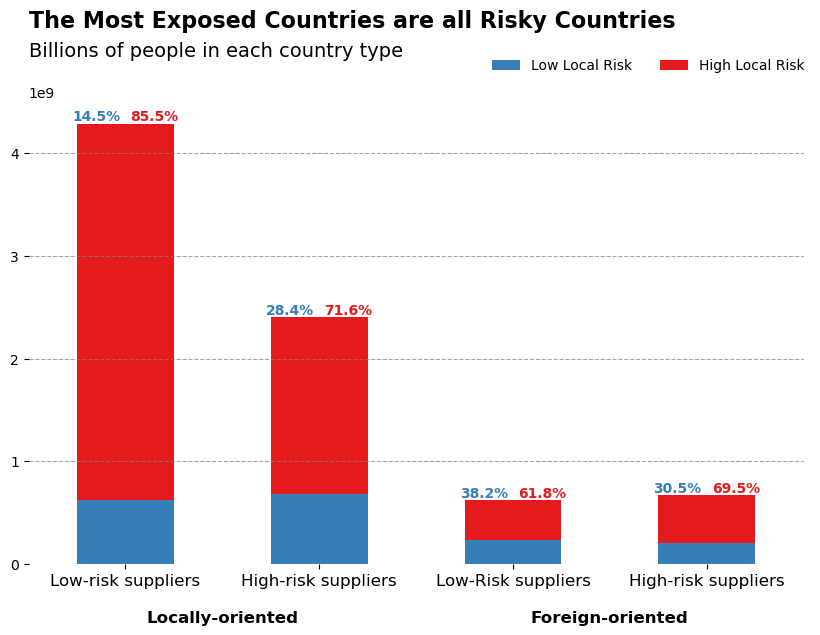

In [ ]:
import seaborn as sns

t=0.5
df = resulting_dataframe_country_imports_interm_leontief[t]
df = df.dropna(subset=['Local Climate Risk'])

# Calculate the median values for 'High Risk (imports)' and 'Foreign (%)'
median_high_risk_imports = df['Share of Risky Trade Partners (%)'].median()
median_foreign = df['Foreign (%)'].median()

# Add columns to indicate if each row is over or under the median for the specified columns
df['Share of Risky Trade Partners (%) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_imports else 'Low-risk suppliers')
df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'Share of Risky Trade Partners (%) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category', 'Local Risk'])['Population'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Define a color code for each 'Local Risk'
colorpalette = sns.color_palette("Set1", 7)
colors = {'Low Risk': colorpalette[1], 'High Risk': colorpalette[0]}
    
# Create a stacked bar plot with custom colors
fig, ax = plt.subplots(figsize=(10, 6))
population_by_risk.plot(kind='bar', stacked=True, color=colors, ax=ax)


# Iterate through the bars (x positions) to calculate and annotate percentages
for i, (index, row) in enumerate(population_by_risk.iterrows()):
    total = row.sum()
    # Starting y position for the text - top of each bar
    y_offset = total

    # Horizontal offset to separate the text annotations
    horizontal_offset = -0.15

    for color in colors:
        # Calculate percentage
        percentage = (row[color] / total) * 100 if total != 0 else 0
        # X position of the bar with an offset, Y position for the text is at the top of the bar
        x = i + horizontal_offset
        # Add text annotation
        ax.text(x, y_offset, f'{percentage:.1f}%', ha='center', va='bottom', color=colors[color], fontsize=10,fontweight='bold')
        # Update horizontal offset for next text
        horizontal_offset += 0.3
        
        
# Set labels and title
plt.text(0, 1.2, "The Most Exposed Countries are all Risky Countries",   transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
#plt.text(0, 1.17, "No Correlation Between Climate-foreign-dependent and Local Risk ", transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
plt.text(0, 1.13, "Billions of people in each country type", transform=ax.transAxes, fontsize=14, va='top', ha='left')

# Suppress the scientific notation on the y-axis
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

# Suppress the frame by setting the visibility of the spines to False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

first_level_labels = ['Low-risk suppliers', 'High-risk suppliers', 'Low-Risk suppliers', 'High-risk suppliers']
ax.set_xticklabels(first_level_labels, rotation=0, fontsize=12)

# Assuming there are four groups (you can adjust this according to your actual data)
middle_positions = [i*2+0.5 for i in range(len(population_by_risk.index))]
group_labels = ["Locally-oriented","Foreign-oriented"]  # Replace these with your actual group labels

# Add the second level of labels
for pos, label in zip(middle_positions, group_labels):
    ax.text(pos, -0.1, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=12,fontweight='bold')


# Get handles and labels from the existing legend
handles, labels = ax.get_legend_handles_labels()

# Replace legend labels
new_labels = ['High Local Risk' if label == 'High Risk' else 'Low Local Risk' for label in labels]

# Create new legend with updated labels
legend = ax.legend(handles, new_labels, title='', loc='upper center', bbox_to_anchor=(0.8, 1.12), ncol=2, frameon=False)

#legend.set_title('Local Risk')
# Suppress the x-axis title
ax.set_xlabel("")

# Show the plot
#plt.tight_layout()
plt.show()

In [111]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame

# Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'Share of Risky Trade Partners (%) Category'
df_sorted = df.sort_values(by=['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category'], ascending=[False, False])

# Group the sorted data
grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category', 'Local Risk'])['Population'].sum()

# Unstack the 'Local Risk' level to prepare for a stacked bar chart
population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

# Define the custom order
custom_order = [
    ('Locally-oriented', 'Low-risk suppliers'),
    ('Locally-oriented', 'High-risk suppliers'),
    ('Foreign-oriented', 'Low-risk suppliers'),
    ('Foreign-oriented', 'High-risk suppliers'),
    ]

# Reorder the DataFrame according to the custom order
population_by_risk = population_by_risk.loc[custom_order]

# Calculate the percentage of the population in 'High Local Risk' category among 'High-risk suppliers' and 'Foreign-oriented'
total_high_risk_population = population_by_risk.loc[('Foreign-oriented', 'High-risk suppliers'), 'High Risk']
total_foreign_oriented_population = population_by_risk.loc[('Foreign-oriented', 'High-risk suppliers')].sum()
percentage_high_local_risk = (total_high_risk_population / total_foreign_oriented_population) * 100

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Lists to store t values and the final percentage for each t
t_values =[-0.75,-0.5,-0.25,0,0.25,0.5,0.75]
percentages = []

# Iterate over each t
for t in t_values:
    # Set df to resulting_dataframe_country_inputs_leontief[t]
    df = resulting_dataframe_country_imports_interm_leontief[t]
    df = df.dropna(subset=['Local Climate Risk'])

    # Calculate the median values for 'High Risk (imports)' and 'Foreign (%)'
    median_high_risk_imports = df['Share of Risky Trade Partners (%)'].median()
    median_foreign = df['Foreign (%)'].median()

    # Add columns to indicate if each row is over or under the median for the specified columns
    df['Share of Risky Trade Partners (%) Category'] = df['Share of Risky Trade Partners (%)'].apply(lambda x: 'High-risk suppliers' if x > median_high_risk_imports else 'Low-risk suppliers')
    df['Foreign (%) Category'] = df['Foreign (%)'].apply(lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

    # Sort the DataFrame in the reverse order for 'Foreign (%) Category' and 'Share of Risky Trade Partners (%) Category'
    df_sorted = df.sort_values(by=['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category'], ascending=[False, False])

    # Group the sorted data
    grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category', 'Local Risk'])['Population'].sum()

    # Unstack the 'Local Risk' level to prepare for a stacked bar chart
    population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)

    # Define the custom order
    custom_order = [
        ('Locally-oriented', 'Low-risk suppliers'),
        ('Locally-oriented', 'High-risk suppliers'),
        ('Foreign-oriented', 'Low-risk suppliers'),
        ('Foreign-oriented', 'High-risk suppliers'),
    ]

    # Reorder the DataFrame according to the custom order
    population_by_risk = population_by_risk.loc[custom_order]

    # Calculate the percentage of the population in 'High Local Risk' category among 'High-risk suppliers' and 'Foreign-oriented'
    total_high_risk_population = population_by_risk.loc[('Foreign-oriented', 'High-risk suppliers'), 'High Risk']
    total_foreign_oriented_population = population_by_risk.loc[('Foreign-oriented', 'High-risk suppliers')].sum()
    percentage_high_local_risk = (total_high_risk_population / total_foreign_oriented_population) * 100
    
    # Append t and the final percentage to the lists
    percentages.append(percentage_high_local_risk)

# Plot using a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.plot(t_values, percentages, color='skyblue')
plt.ylabel('Share of high local risk \namong high cross-border exposure (%)',size=14)
plt.xlabel('Risk Threshold (INFORM)',size=14)


#plt.title('R-squared value vs. country taken out')
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')
ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=14)  # Setting tick label

# Adjust x-ticks to show 3.5 + t
new_labels = [f'{3.5 + t:.2f}' for t in t_values]
ax.set_xticks(t_values)  # Set x-ticks positions
ax.set_xticklabels(new_labels)  # Set new labels

plt.tight_layout()

#plt.savefig(r'Figures\Supp Mat\E\Figure3a.png')

plt.show() 

KeyError: -0.75

C:\Users\delah\AppData\Local\Temp\ipykernel_7900\4069130781.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Share of Risky Trade Partners (%) Category'] = df['Share of Risky Trade Partners (%)'].apply(
C:\Users\delah\AppData\Local\Temp\ipykernel_7900\4069130781.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Foreign (%) Category'] = df['Foreign (%)'].apply(
C:\Users\delah\AppData\Local\Temp\ipykernel_7900\4069130781.py:24: FutureWarning: The default of observed=False is deprecated and will

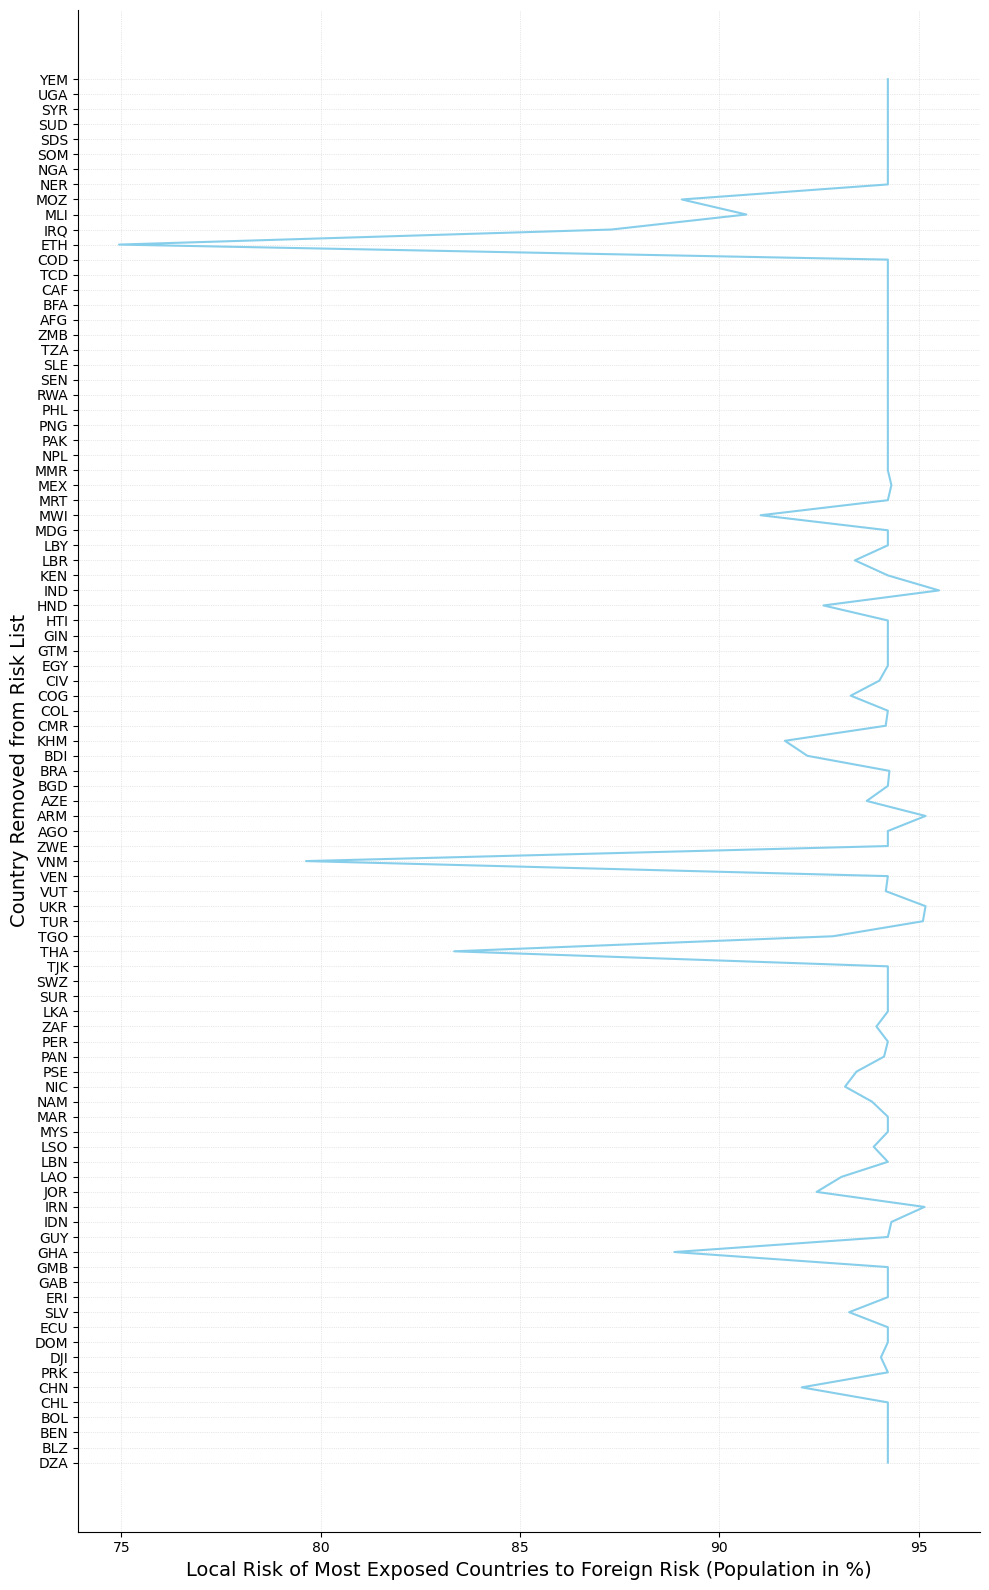

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Lists to store t values and the final percentage for each t
percentages = []

for c in high_risk_countries:
    # Set df to the resulting dataframe for a specific country
    df = resulting_dataframe_country_imports_interm_leontief[c]
    df = df.dropna(subset=['Local Climate Risk'])

    # Calculate median values for 'High Risk (imports)' and 'Foreign (%)'
    median_high_risk_imports = df['Share of Risky Trade Partners (%)'].median()
    median_foreign = df['Foreign (%)'].median()

    # Add category columns based on median values
    df['Share of Risky Trade Partners (%) Category'] = df['Share of Risky Trade Partners (%)'].apply(
        lambda x: 'High-risk suppliers' if x > median_high_risk_imports else 'Low-risk suppliers')
    df['Foreign (%) Category'] = df['Foreign (%)'].apply(
        lambda x: 'Foreign-oriented' if x > median_foreign else 'Locally-oriented')

    # Sort and group the DataFrame
    df_sorted = df.sort_values(by=['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category'], ascending=[False, False])
    grouped_data_sorted = df_sorted.groupby(['Foreign (%) Category', 'Share of Risky Trade Partners (%) Category', 'Local Risk'])['Population'].sum()

    # Unstack and reorder data for plotting
    population_by_risk = grouped_data_sorted.unstack(level='Local Risk').fillna(0)
    custom_order = [
        ('Locally-oriented', 'Low-risk suppliers'),
        ('Locally-oriented', 'High-risk suppliers'),
        ('Foreign-oriented', 'Low-risk suppliers'),
        ('Foreign-oriented', 'High-risk suppliers'),
    ]
    population_by_risk = population_by_risk.loc[custom_order]

    # Calculate percentages
    total_high_risk_population = population_by_risk.loc[('Foreign-oriented', 'High-risk suppliers'), 'High Risk']
    total_foreign_oriented_population = population_by_risk.loc[('Foreign-oriented', 'High-risk suppliers')].sum()
    percentage_high_local_risk = (total_high_risk_population / total_foreign_oriented_population) * 100

    percentages.append(percentage_high_local_risk)

# Plot using a horizontal bar chart
plt.figure(figsize=(10, 16))
plt.plot(percentages, high_risk_countries, color='skyblue')
plt.xlabel('Local Risk of Most Exposed Countries to Foreign Risk (Population in %)',size=14)
plt.ylabel('Country Removed from Risk List',size=14)


#plt.title('R-squared value vs. country taken out')
plt.grid(True, which='both', linestyle=':', linewidth=0.5, color='lightgrey')

ax = plt.gca()  # Get the current Axes instance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()

#plt.savefig(r'Figures\Supp Mat\E\Figure7.png')

plt.show() 